# USAspending.gov GAN and Lightweight Extended DPoS Pipeline

The original 24-block Google Colab pipeline is preserved. A reviewer-strengthening
extension is appended after the original pipeline to add:

- official-data provenance and chronological transaction replay;
- a leakage-aware supplementary machine-learning evaluation;
- multi-agency, identity, key-management, tender, milestone, privacy, and governance simulations;
- security invariants, attack modelling, collusion experiments, and formal-property checks;
- large-scale concurrent workload tests and architecture comparisons;
- publication-ready tables, figures, CSV files, and a downloadable ZIP package.

The appended experiments are explicitly labelled as **simulation-level evidence**.
They do not claim operational government deployment, legal certification, real
identity verification, physical construction inspection, or Solidity formal verification.

In [1]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 1 — Install Required Packages
# ═══════════════════════════════════════════════════════════════
!pip -q install pandas numpy scikit-learn tensorflow matplotlib

In [2]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 2 — Import Libraries and Configure Reproducibility
# ═══════════════════════════════════════════════════════════════
import os
import gc
import json
import time
import random
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

warnings.filterwarnings("ignore")

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 3 — Load USAspending.gov CSV Dataset from Google Drive
# ═══════════════════════════════════════════════════════════════
from google.colab import drive

drive.mount("/content/drive")

GOOGLE_DRIVE_FOLDER_LINK = (
    "https://drive.google.com/drive/folders/"
    "1v7UgRC2BGgk6F9gVsGdwP5DE6KhV39IQ"
)

DATASET_PATH = "/content/drive/MyDrive/p-83/GDataset/GFunddata.csv"

print("Google Drive folder:", GOOGLE_DRIVE_FOLDER_LINK)
print("Dataset path:", DATASET_PATH)

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_PATH}\n"
        "Confirm that GFunddata.csv is stored in "
        "My Drive/p-83/GDataset/."
    )

df = pd.read_csv(
    DATASET_PATH,
    low_memory=False,
    on_bad_lines="skip"
)

print("Original dataset shape:", df.shape)

print("\nDataset columns:")
for index, column in enumerate(df.columns, start=1):
    print(f"{index:03d}. {column}")

display(df.head())

Mounted at /content/drive
Google Drive folder: https://drive.google.com/drive/folders/1v7UgRC2BGgk6F9gVsGdwP5DE6KhV39IQ
Dataset path: /content/drive/MyDrive/p-83/GDataset/GFunddata.csv
Original dataset shape: (1000000, 297)

Dataset columns:
001. contract_transaction_unique_key
002. contract_award_unique_key
003. award_id_piid
004. modification_number
005. transaction_number
006. parent_award_agency_id
007. parent_award_agency_name
008. parent_award_id_piid
009. parent_award_modification_number
010. federal_action_obligation
011. total_dollars_obligated
012. total_outlayed_amount_for_overall_award
013. base_and_exercised_options_value
014. current_total_value_of_award
015. base_and_all_options_value
016. potential_total_value_of_award
017. disaster_emergency_fund_codes_for_overall_award
018. outlayed_amount_from_COVID-19_supplementals_for_overall_award
019. obligated_amount_from_COVID-19_supplementals_for_overall_award
020. outlayed_amount_from_IIJA_supplemental_for_overall_award
021. 

,contract_transaction_unique_key,contract_award_unique_key,award_id_piid,modification_number,transaction_number,parent_award_agency_id,parent_award_agency_name,parent_award_id_piid,parent_award_modification_number,federal_action_obligation,...,highly_compensated_officer_2_amount,highly_compensated_officer_3_name,highly_compensated_officer_3_amount,highly_compensated_officer_4_name,highly_compensated_officer_4_amount,highly_compensated_officer_5_name,highly_compensated_officer_5_amount,usaspending_permalink,initial_report_date,last_modified_date
0,4732_4732_47QSSC26F014D_0_GS03FGA010_0,CONT_AWD_47QSSC26F014D_4732_GS03FGA010_4732,47QSSC26F014D,0,0.0,4732,FEDERAL ACQUISITION SERVICE,GS03FGA010,PW0006,116.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_47Q...,2025-10-06 05:37:39+00,2025-10-06 05:37:40+00
1,4732_4732_47QSSC26F04CK_0_47QSEA23D0044_0,CONT_AWD_47QSSC26F04CK_4732_47QSEA23D0044_4732,47QSSC26F04CK,0,0.0,4732,FEDERAL ACQUISITION SERVICE,47QSEA23D0044,0,170.85,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_47Q...,2025-10-05 16:04:56+00,2025-10-05 16:04:57+00
2,4732_4732_47QSSC26F04FB_0_47QSHA21A000D_0,CONT_AWD_47QSSC26F04FB_4732_47QSHA21A000D_4732,47QSSC26F04FB,0,0.0,4732,FEDERAL ACQUISITION SERVICE,47QSHA21A000D,PS0010,1.05,...,184189.0,JEFFREY PRIMEAU,100795.0,PATRICK TREVISAN,91799.0,ANDREW BITER,87208.0,https://www.usaspending.gov/award/CONT_AWD_47Q...,2025-10-05 09:41:15+00,2025-10-05 09:41:15+00
3,4732_4732_47QSSC26F0781_0_47QSWA22D0009_0,CONT_AWD_47QSSC26F0781_4732_47QSWA22D0009_4732,47QSSC26F0781,0,0.0,4732,FEDERAL ACQUISITION SERVICE,47QSWA22D0009,0,27.84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_47Q...,2025-10-06 01:03:34+00,2025-10-06 01:03:35+00
4,4732_4732_47QSSC26F07BB_0_47QSWA21D007B_0,CONT_AWD_47QSSC26F07BB_4732_47QSWA21D007B_4732,47QSSC26F07BB,0,0.0,4732,FEDERAL ACQUISITION SERVICE,47QSWA21D007B,PA0019,1820.65,...,131958.0,KRISTOPHER DELOSUA,107549.0,ROBERTA FREEMAN,86119.0,CHRISTIAN SCOTT,82422.0,https://www.usaspending.gov/award/CONT_AWD_47Q...,2025-10-07 01:01:11+00,2025-10-07 01:01:12+00


In [4]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 4 — Automatic USAspending Column Mapping
# ═══════════════════════════════════════════════════════════════
COLUMN_CANDIDATES = {
    "project_id": [
        "contract_award_unique_key",
        "assistance_award_unique_key",
        "generated_unique_award_id",
        "award_id_piid",
        "award_id_fain",
        "award_id_uri"
    ],

    "project_name": [
        "award_description",
        "transaction_description",
        "product_or_service_code_description",
        "cfda_title"
    ],

    "finance_ministry": [
        "funding_agency_name",
        "awarding_agency_name",
        "funding_sub_agency_name",
        "awarding_sub_agency_name"
    ],

    "treasury": [
        "treasury_accounts_funding_this_award",
        "federal_accounts_funding_this_award",
        "treasury_account_symbol",
        "federal_account_name"
    ],

    "city_corporation": [
        "recipient_city_name",
        "recipient_county_name",
        "recipient_state_name",
        "place_of_performance_city_name",
        "place_of_performance_county_name",
        "place_of_performance_state_name"
    ],

    "builder": [
        "recipient_name",
        "recipient_parent_name",
        "recipient_uei",
        "recipient_duns"
    ],

    "budget": [
        "total_obligated_amount",
        "current_total_value_of_award",
        "potential_total_value_of_award",
        "base_and_all_options_value",
        "federal_action_obligation",
        "total_outlayed_amount_for_overall_award"
    ],

    "transaction_amount": [
        "federal_action_obligation",
        "current_total_value_of_award",
        "total_obligated_amount",
        "total_outlayed_amount_for_overall_award"
    ],

    "date": [
        "action_date",
        "period_of_performance_start_date",
        "period_of_performance_current_end_date",
        "last_modified_date"
    ],

    "award_type": [
        "award_type",
        "award_type_code",
        "contract_award_type",
        "type"
    ],

    "location": [
        "primary_place_of_performance_city_name",
        "place_of_performance_city_name",
        "recipient_city_name",
        "recipient_state_name"
    ]
}


def normalize_column_name(name):
    """Normalize a column name for robust matching."""
    return str(name).strip().lower().replace(" ", "_")


normalized_lookup = {
    normalize_column_name(column): column
    for column in df.columns
}


def find_matching_column(candidate_names):
    """Return the first matching original dataset column."""
    for candidate in candidate_names:
        normalized_candidate = normalize_column_name(candidate)

        if normalized_candidate in normalized_lookup:
            return normalized_lookup[normalized_candidate]

    return None


selected_columns = {
    logical_name: find_matching_column(candidates)
    for logical_name, candidates in COLUMN_CANDIDATES.items()
}

print("Selected USAspending column mapping:\n")

for logical_name, selected_column in selected_columns.items():
    print(f"{logical_name:22s} -> {selected_column}")

Selected USAspending column mapping:

project_id             -> contract_award_unique_key
project_name           -> transaction_description
finance_ministry       -> funding_agency_name
treasury               -> treasury_accounts_funding_this_award
city_corporation       -> recipient_city_name
builder                -> recipient_name
budget                 -> current_total_value_of_award
transaction_amount     -> federal_action_obligation
date                   -> action_date
award_type             -> award_type
location               -> primary_place_of_performance_city_name


In [5]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 5 — Build the Government Budget Management Dataset
# ═══════════════════════════════════════════════════════════════
def get_column_or_default(source_df, column_name, default_value):
    if column_name is not None:
        return source_df[column_name].copy()

    return pd.Series(
        [default_value] * len(source_df),
        index=source_df.index
    )


data = pd.DataFrame(index=df.index)

data["Project_ID"] = get_column_or_default(
    df,
    selected_columns["project_id"],
    None
)

missing_project_ids = data["Project_ID"].isna() | (
    data["Project_ID"].astype(str).str.strip() == ""
)

data.loc[missing_project_ids, "Project_ID"] = [
    f"PRJ-{index:08d}"
    for index in data.index[missing_project_ids]
]

data["Project_Name"] = get_column_or_default(
    df,
    selected_columns["project_name"],
    "Government Project"
)

data["Finance_Ministry"] = get_column_or_default(
    df,
    selected_columns["finance_ministry"],
    "Federal Funding Agency"
)

data["Treasury"] = get_column_or_default(
    df,
    selected_columns["treasury"],
    "United States Treasury"
)

data["City_Corporation"] = get_column_or_default(
    df,
    selected_columns["city_corporation"],
    "Local Government Authority"
)

data["Builder"] = get_column_or_default(
    df,
    selected_columns["builder"],
    "Government Contractor"
)

data["Award_Type"] = get_column_or_default(
    df,
    selected_columns["award_type"],
    "Unknown Award Type"
)

data["Project_Location"] = get_column_or_default(
    df,
    selected_columns["location"],
    "Unknown Location"
)

data["Action_Date"] = get_column_or_default(
    df,
    selected_columns["date"],
    "Unknown Date"
)

if selected_columns["budget"] is None:
    raise ValueError(
        "No suitable budget column was detected. "
        "Check the printed dataset columns and update COLUMN_CANDIDATES."
    )

data["Budget"] = pd.to_numeric(
    df[selected_columns["budget"]],
    errors="coerce"
)

if selected_columns["transaction_amount"] is not None:
    data["Transaction_Amount"] = pd.to_numeric(
        df[selected_columns["transaction_amount"]],
        errors="coerce"
    )
else:
    data["Transaction_Amount"] = data["Budget"]


# Replace infinite values
data["Budget"] = data["Budget"].replace([np.inf, -np.inf], np.nan)
data["Transaction_Amount"] = data["Transaction_Amount"].replace(
    [np.inf, -np.inf],
    np.nan
)

# Missing amount handling
data["Budget"] = data["Budget"].fillna(0)
data["Transaction_Amount"] = data["Transaction_Amount"].fillna(
    data["Budget"]
)

# Financial reversals may appear as negative obligations.
# Absolute values are used for blockchain simulation.
data["Budget"] = data["Budget"].abs()
data["Transaction_Amount"] = data["Transaction_Amount"].abs()

# Remove zero-budget records
data = data[data["Budget"] > 0].copy()

# Fill categorical missing values
categorical_columns = [
    "Project_ID",
    "Project_Name",
    "Finance_Ministry",
    "Treasury",
    "City_Corporation",
    "Builder",
    "Award_Type",
    "Project_Location",
    "Action_Date"
]

for column in categorical_columns:
    data[column] = (
        data[column]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
    )

# Remove duplicate project-transaction records
data = data.drop_duplicates(
    subset=["Project_ID", "Transaction_Amount"],
    keep="first"
).reset_index(drop=True)

print("Processed dataset shape:", data.shape)
display(data.head())

Processed dataset shape: (916319, 11)


,Project_ID,Project_Name,Finance_Ministry,Treasury,City_Corporation,Builder,Award_Type,Project_Location,Action_Date,Budget,Transaction_Amount
0,CONT_AWD_47QSSC26F014D_4732_GS03FGA010_4732,"BOARD,MARKER",General Services Administration,047-X-4534-001,ALEXANDRIA,NATIONAL INDUSTRIES FOR THE BLIND,DELIVERY ORDER,SEATTLE,2025-10-02,116.18,116.18
1,CONT_AWD_47QSSC26F04CK_4732_47QSEA23D0044_4732,"CARTRIDGE, TONER: ITEM NAME CARTRIDGE, TONER I...",General Services Administration,047-X-4534-001,GREENACRES,SUPPLIES NOW INC,DELIVERY ORDER,GREENACRES,2025-10-03,170.85,170.85
2,CONT_AWD_47QSSC26F04FB_4732_47QSHA21A000D_4732,"KEY,SOCKET HEAD SCREW SNAP-ON INC P/N: AWM6D",General Services Administration,047-X-4534-001,WARREN,"WRIGHT TOOL COMPANY, LLC",BPA CALL,WARREN,2025-10-03,1.05,1.05
3,CONT_AWD_47QSSC26F0781_4732_47QSWA22D0009_4732,"BRUSH,WIRE,SCRATCH",General Services Administration,047-X-4534-001,ALEXANDRIA,NATIONAL INDUSTRIES FOR THE BLIND,DELIVERY ORDER,ALEXANDRIA,2025-10-05,27.84,27.84
4,CONT_AWD_47QSSC26F07BB_4732_47QSWA21D007B_4732,SANTIZ ENTERPRISES-70404,General Services Administration,047-X-4534-001,FREDERICKSBURG,"SANITZ ENTERPRISES, INC.",DELIVERY ORDER,WILLOW CITY,2025-10-06,1820.65,1820.65


In [6]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 6 — Feature Engineering and Risk-Label Construction
# ═══════════════════════════════════════════════════════════════
# USAspending does not provide a direct fraud label.
# Therefore, a reproducible proxy-risk label is generated using
# unusual transaction and budget characteristics.

data["Action_Date_Parsed"] = pd.to_datetime(
    data["Action_Date"],
    errors="coerce"
)

data["Action_Year"] = data["Action_Date_Parsed"].dt.year.fillna(0).astype(int)
data["Action_Month"] = data["Action_Date_Parsed"].dt.month.fillna(0).astype(int)
data["Action_Day"] = data["Action_Date_Parsed"].dt.day.fillna(0).astype(int)

data["Budget_Log"] = np.log1p(data["Budget"])
data["Transaction_Log"] = np.log1p(data["Transaction_Amount"])

data["Transaction_Budget_Ratio"] = (
    data["Transaction_Amount"] /
    data["Budget"].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan).fillna(0)

data["Recipient_Name_Length"] = data["Builder"].str.len()
data["Project_Name_Length"] = data["Project_Name"].str.len()

budget_high = data["Budget"].quantile(0.97)
transaction_high = data["Transaction_Amount"].quantile(0.97)

ratio_low = data["Transaction_Budget_Ratio"].quantile(0.01)
ratio_high = data["Transaction_Budget_Ratio"].quantile(0.99)

data["Risk_Label"] = (
    (data["Budget"] >= budget_high) |
    (data["Transaction_Amount"] >= transaction_high) |
    (data["Transaction_Budget_Ratio"] <= ratio_low) |
    (data["Transaction_Budget_Ratio"] >= ratio_high)
).astype(int)

print("Risk-label distribution:")
print(data["Risk_Label"].value_counts())

print("\nRisk-label percentage:")
print(data["Risk_Label"].value_counts(normalize=True).mul(100).round(2))

Risk-label distribution:
Risk_Label
1    860114
0     56205
Name: count, dtype: int64

Risk-label percentage:
Risk_Label
1    93.87
0     6.13
Name: proportion, dtype: float64


In [7]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 7 — Prepare Machine-Learning Features
# ═══════════════════════════════════════════════════════════════
feature_columns = [
    "Project_Name",
    "Finance_Ministry",
    "Treasury",
    "City_Corporation",
    "Builder",
    "Award_Type",
    "Project_Location",
    "Budget_Log",
    "Transaction_Log",
    "Transaction_Budget_Ratio",
    "Action_Year",
    "Action_Month",
    "Action_Day",
    "Recipient_Name_Length",
    "Project_Name_Length"
]

X = data[feature_columns].copy()
y = data["Risk_Label"].astype(int).copy()

encoders = {}

for column in X.select_dtypes(include=["object"]).columns:
    encoder = LabelEncoder()

    X[column] = encoder.fit_transform(
        X[column].fillna("Unknown").astype(str)
    )

    encoders[column] = encoder

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())

Feature matrix shape: (916319, 15)
Target shape: (916319,)


,Project_Name,Finance_Ministry,Treasury,City_Corporation,Builder,Award_Type,Project_Location,Budget_Log,Transaction_Log,Transaction_Budget_Ratio,Action_Year,Action_Month,Action_Day,Recipient_Name_Length,Project_Name_Length
0,496441,46,5761,81,22583,2,4608,4.763711,4.763711,1.0,2025,10,2,33,12
1,501455,46,5761,2279,31000,2,2061,5.146622,5.146622,1.0,2025,10,3,16,250
2,553476,46,5761,6148,35876,0,5291,0.717840,0.717840,1.0,2025,10,3,24,44
3,498273,46,5761,81,22583,2,64,3.361763,3.361763,1.0,2025,10,5,33,18
4,597151,46,5761,2038,28335,2,5512,7.507498,7.507498,1.0,2025,10,6,24,24


In [8]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 8 — Single Stratified Train/Test Split
# 5-Fold Cross-Validation Has Been Removed
# ═══════════════════════════════════════════════════════════════
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

y_train = y_train.to_numpy(dtype=np.int32)
y_test = y_test.to_numpy(dtype=np.int32)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining label distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting label distribution:")
print(pd.Series(y_test).value_counts())

Training samples: 733055
Testing samples: 183264

Training label distribution:
1    688091
0     44964
Name: count, dtype: int64

Testing label distribution:
1    172023
0     11241
Name: count, dtype: int64


In [9]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 9 — GAN Models for Minority-Class Data Generation
# ═══════════════════════════════════════════════════════════════
def build_generator(latent_dimension, output_dimension):
    generator = models.Sequential(
        [
            layers.Input(shape=(latent_dimension,)),
            layers.Dense(64),
            layers.LeakyReLU(negative_slope=0.2),
            layers.BatchNormalization(),

            layers.Dense(128),
            layers.LeakyReLU(negative_slope=0.2),
            layers.BatchNormalization(),

            layers.Dense(output_dimension, activation="linear")
        ],
        name="Minority_Generator"
    )

    return generator


def build_discriminator(input_dimension):
    discriminator = models.Sequential(
        [
            layers.Input(shape=(input_dimension,)),
            layers.Dense(128),
            layers.LeakyReLU(negative_slope=0.2),
            layers.Dropout(0.20),

            layers.Dense(64),
            layers.LeakyReLU(negative_slope=0.2),
            layers.Dropout(0.20),

            layers.Dense(1, activation="sigmoid")
        ],
        name="Minority_Discriminator"
    )

    discriminator.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0002,
            beta_1=0.5
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return discriminator

In [10]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 10 — GAN-Based Class-Imbalance Handling
# ═══════════════════════════════════════════════════════════════
def gan_oversample(
    X_input,
    y_input,
    latent_dimension=32,
    epochs=200,
    batch_size=64,
    verbose_interval=50
):
    X_input = np.asarray(X_input, dtype=np.float32)
    y_input = np.asarray(y_input, dtype=np.int32)

    labels, counts = np.unique(y_input, return_counts=True)

    if len(labels) < 2:
        print("Only one class is available. GAN oversampling skipped.")
        return X_input, y_input, None

    minority_class = labels[np.argmin(counts)]
    majority_class = labels[np.argmax(counts)]

    X_minority = X_input[y_input == minority_class]
    X_majority = X_input[y_input == majority_class]

    number_to_generate = len(X_majority) - len(X_minority)

    print("Minority class:", minority_class)
    print("Majority class:", majority_class)
    print("Minority samples:", len(X_minority))
    print("Majority samples:", len(X_majority))
    print("Synthetic samples required:", number_to_generate)

    if number_to_generate <= 0:
        print("Training data are already balanced.")
        return X_input, y_input, None

    input_dimension = X_input.shape[1]

    generator = build_generator(
        latent_dimension,
        input_dimension
    )

    discriminator = build_discriminator(input_dimension)

    discriminator.trainable = False

    noise_input = layers.Input(shape=(latent_dimension,))
    generated_features = generator(noise_input)
    validity = discriminator(generated_features)

    combined_gan = models.Model(
        noise_input,
        validity,
        name="Minority_GAN"
    )

    combined_gan.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0002,
            beta_1=0.5
        ),
        loss="binary_crossentropy"
    )

    discriminator_loss_history = []
    generator_loss_history = []

    effective_batch_size = min(batch_size, len(X_minority))

    for epoch in range(1, epochs + 1):
        # Train discriminator with real minority samples
        real_indices = np.random.randint(
            0,
            len(X_minority),
            effective_batch_size
        )

        real_samples = X_minority[real_indices]

        noise = np.random.normal(
            0,
            1,
            size=(effective_batch_size, latent_dimension)
        ).astype(np.float32)

        generated_samples = generator.predict(
            noise,
            verbose=0
        )

        real_targets = np.ones(
            (effective_batch_size, 1),
            dtype=np.float32
        ) * 0.9

        fake_targets = np.zeros(
            (effective_batch_size, 1),
            dtype=np.float32
        )

        discriminator.trainable = True

        discriminator_real_loss = discriminator.train_on_batch(
            real_samples,
            real_targets
        )

        discriminator_fake_loss = discriminator.train_on_batch(
            generated_samples,
            fake_targets
        )

        discriminator_loss = 0.5 * (
            float(discriminator_real_loss[0]) +
            float(discriminator_fake_loss[0])
        )

        # Train generator
        discriminator.trainable = False

        noise = np.random.normal(
            0,
            1,
            size=(effective_batch_size, latent_dimension)
        ).astype(np.float32)

        misleading_targets = np.ones(
            (effective_batch_size, 1),
            dtype=np.float32
        )

        generator_loss = combined_gan.train_on_batch(
            noise,
            misleading_targets
        )

        discriminator_loss_history.append(discriminator_loss)
        generator_loss_history.append(float(generator_loss))

        if epoch == 1 or epoch % verbose_interval == 0:
            print(
                f"Epoch {epoch:4d}/{epochs} | "
                f"D Loss: {discriminator_loss:.4f} | "
                f"G Loss: {float(generator_loss):.4f}"
            )

    generation_noise = np.random.normal(
        0,
        1,
        size=(number_to_generate, latent_dimension)
    ).astype(np.float32)

    synthetic_minority_samples = generator.predict(
        generation_noise,
        batch_size=1024,
        verbose=0
    )

    # Restrict generated values to the training-data range
    feature_minimums = X_minority.min(axis=0)
    feature_maximums = X_minority.max(axis=0)

    synthetic_minority_samples = np.clip(
        synthetic_minority_samples,
        feature_minimums,
        feature_maximums
    )

    X_balanced = np.vstack(
        [X_input, synthetic_minority_samples]
    )

    y_balanced = np.concatenate(
        [
            y_input,
            np.full(
                number_to_generate,
                minority_class,
                dtype=np.int32
            )
        ]
    )

    shuffled_indices = np.random.permutation(len(X_balanced))

    X_balanced = X_balanced[shuffled_indices]
    y_balanced = y_balanced[shuffled_indices]

    gan_history = {
        "discriminator_loss": discriminator_loss_history,
        "generator_loss": generator_loss_history,
        "minority_class": int(minority_class),
        "generated_samples": int(number_to_generate)
    }

    return X_balanced, y_balanced, gan_history


X_train_balanced, y_train_balanced, gan_history = gan_oversample(
    X_train,
    y_train,
    latent_dimension=32,
    epochs=200,
    batch_size=64
)

print("\nBalanced training distribution:")
print(pd.Series(y_train_balanced).value_counts())

Minority class: 0
Majority class: 1
Minority samples: 44964
Majority samples: 688091
Synthetic samples required: 643127
Epoch    1/200 | D Loss: 0.6637 | G Loss: 0.6539
Epoch   50/200 | D Loss: 0.6107 | G Loss: 0.5583
Epoch  100/200 | D Loss: 0.5984 | G Loss: 0.6113
Epoch  150/200 | D Loss: 0.5936 | G Loss: 0.7244
Epoch  200/200 | D Loss: 0.5996 | G Loss: 0.7835

Balanced training distribution:
1    688091
0    688091
Name: count, dtype: int64


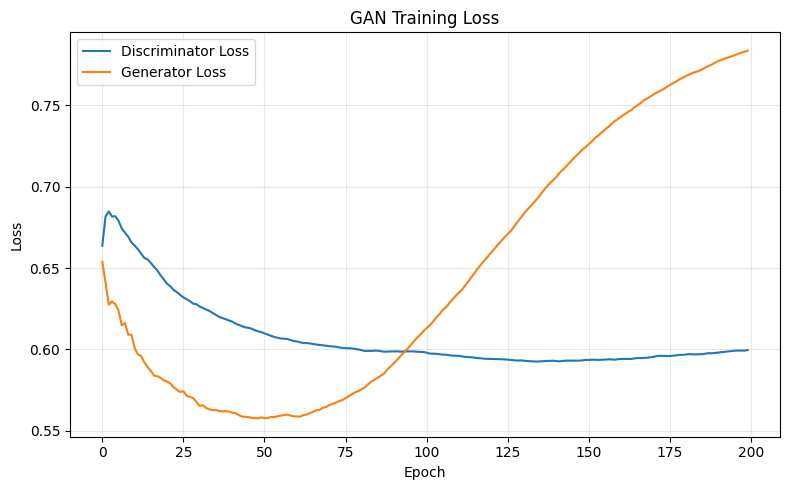

In [11]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 11 — GAN Training-Loss Visualization
# ═══════════════════════════════════════════════════════════════
if gan_history is not None:
    plt.figure(figsize=(8, 5))

    plt.plot(
        gan_history["discriminator_loss"],
        label="Discriminator Loss"
    )

    plt.plot(
        gan_history["generator_loss"],
        label="Generator Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("GAN Training Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [12]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 12 — Train and Evaluate the Classification Model
# ═══════════════════════════════════════════════════════════════
classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

classification_start_time = time.perf_counter()

classifier.fit(
    X_train_balanced,
    y_train_balanced
)

training_time = time.perf_counter() - classification_start_time

prediction_start_time = time.perf_counter()

y_prediction = classifier.predict(X_test)
y_probability = classifier.predict_proba(X_test)[:, 1]

prediction_time = time.perf_counter() - prediction_start_time

accuracy = accuracy_score(y_test, y_prediction)
precision = precision_score(
    y_test,
    y_prediction,
    zero_division=0
)
recall = recall_score(
    y_test,
    y_prediction,
    zero_division=0
)
f1 = f1_score(
    y_test,
    y_prediction,
    zero_division=0
)

try:
    roc_auc = roc_auc_score(y_test, y_probability)
except ValueError:
    roc_auc = np.nan

ml_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "ROC-AUC",
            "Training Time (s)",
            "Prediction Time (s)"
        ],
        "Value": [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc,
            training_time,
            prediction_time
        ]
    }
)

display(ml_results)

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_prediction,
        digits=4,
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_prediction))

,Metric,Value
0,Accuracy,0.999367
1,Precision,0.999895
2,Recall,0.999430
3,F1-Score,0.999663
4,ROC-AUC,0.999944
5,Training Time (s),198.738163
6,Prediction Time (s),1.248196



Classification Report:

              precision    recall  f1-score   support

           0     0.9913    0.9984    0.9949     11241
           1     0.9999    0.9994    0.9997    172023

    accuracy                         0.9994    183264
   macro avg     0.9956    0.9989    0.9973    183264
weighted avg     0.9994    0.9994    0.9994    183264

Confusion Matrix:
[[ 11223     18]
 [    98 171925]]


In [13]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 13 — Lightweight Extended DPoS Blockchain Components
# ═══════════════════════════════════════════════════════════════
PROOF_TYPE = "Extended Delegated Proof of Stake (DPoS)"


def stable_hash(payload):
    """Generate a compact deterministic SHA-256 hash."""
    encoded_payload = json.dumps(
        payload,
        sort_keys=True,
        separators=(",", ":"),
        default=str
    ).encode("utf-8")

    return hashlib.sha256(encoded_payload).hexdigest()


class LightweightTransaction:
    """
    Memory-efficient blockchain transaction using __slots__.
    """

    __slots__ = (
        "transaction_id",
        "function_name",
        "sender",
        "receiver",
        "project_id",
        "amount",
        "gas_used",
        "timestamp",
        "signature"
    )

    def __init__(
        self,
        function_name,
        sender,
        receiver,
        project_id,
        amount,
        gas_used
    ):
        self.function_name = str(function_name)
        self.sender = str(sender)
        self.receiver = str(receiver)
        self.project_id = str(project_id)
        self.amount = float(amount)
        self.gas_used = int(gas_used)
        self.timestamp = time.time()

        transaction_payload = {
            "function_name": self.function_name,
            "sender": self.sender,
            "receiver": self.receiver,
            "project_id": self.project_id,
            "amount": self.amount,
            "timestamp": self.timestamp
        }

        self.transaction_id = stable_hash(transaction_payload)

        # Lightweight simulated digital signature
        self.signature = stable_hash(
            {
                "transaction_id": self.transaction_id,
                "sender": self.sender
            }
        )

    def to_dict(self):
        return {
            "transaction_id": self.transaction_id,
            "function_name": self.function_name,
            "sender": self.sender,
            "receiver": self.receiver,
            "project_id": self.project_id,
            "amount": self.amount,
            "gas_used": self.gas_used,
            "timestamp": self.timestamp,
            "signature": self.signature
        }


class DPoSDelegate:
    """
    Delegate candidate participating in Extended DPoS.
    """

    __slots__ = (
        "delegate_id",
        "stake",
        "reputation",
        "availability",
        "blocks_produced"
    )

    def __init__(
        self,
        delegate_id,
        stake,
        reputation,
        availability
    ):
        self.delegate_id = str(delegate_id)
        self.stake = float(stake)
        self.reputation = float(reputation)
        self.availability = float(availability)
        self.blocks_produced = 0

    @property
    def voting_score(self):
        """
        Extended DPoS score combining:
        50% stake, 30% reputation and 20% availability.
        """
        return (
            0.50 * self.stake +
            0.30 * self.reputation +
            0.20 * self.availability
        )

In [14]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 14 — Lightweight Block and Extended DPoS Consensus
# ═══════════════════════════════════════════════════════════════
class LightweightBlock:
    """
    Compact block storing only essential information.
    """

    __slots__ = (
        "index",
        "timestamp",
        "transaction_root",
        "transaction_count",
        "previous_hash",
        "delegate_id",
        "proof_type",
        "gas_used",
        "block_hash"
    )

    def __init__(
        self,
        index,
        transactions,
        previous_hash,
        delegate_id
    ):
        self.index = int(index)
        self.timestamp = time.time()
        self.previous_hash = str(previous_hash)
        self.delegate_id = str(delegate_id)
        self.proof_type = PROOF_TYPE

        self.transaction_count = len(transactions)
        self.gas_used = int(
            sum(transaction.gas_used for transaction in transactions)
        )

        transaction_hashes = [
            transaction.transaction_id
            for transaction in transactions
        ]

        # Compact Merkle-style transaction root
        self.transaction_root = stable_hash(transaction_hashes)

        self.block_hash = self.compute_hash()

    def compute_hash(self):
        block_header = {
            "index": self.index,
            "timestamp": self.timestamp,
            "transaction_root": self.transaction_root,
            "transaction_count": self.transaction_count,
            "previous_hash": self.previous_hash,
            "delegate_id": self.delegate_id,
            "proof_type": self.proof_type,
            "gas_used": self.gas_used
        }

        return stable_hash(block_header)


class ExtendedDPoSConsensus:
    """
    Lightweight Extended Delegated Proof-of-Stake consensus.

    Delegates are ranked using stake, reputation and availability.
    Active delegates produce blocks using weighted round-robin.
    """

    def __init__(
        self,
        number_of_delegates=7,
        active_delegate_count=5,
        random_seed=42
    ):
        self.random_generator = np.random.default_rng(random_seed)

        self.delegates = []

        for delegate_number in range(number_of_delegates):
            delegate = DPoSDelegate(
                delegate_id=f"DELEGATE-{delegate_number + 1:02d}",
                stake=self.random_generator.uniform(50, 100),
                reputation=self.random_generator.uniform(75, 100),
                availability=self.random_generator.uniform(90, 100)
            )

            self.delegates.append(delegate)

        self.active_delegates = sorted(
            self.delegates,
            key=lambda delegate: delegate.voting_score,
            reverse=True
        )[:active_delegate_count]

        self.round_index = 0

    def elect_block_producer(self):
        """
        Select an active delegate through reputation-aware
        weighted round-robin rotation.
        """
        if not self.active_delegates:
            raise RuntimeError("No active DPoS delegates are available.")

        delegate = self.active_delegates[
            self.round_index % len(self.active_delegates)
        ]

        self.round_index += 1
        delegate.blocks_produced += 1

        return delegate

    def delegate_summary(self):
        return pd.DataFrame(
            [
                {
                    "Delegate": delegate.delegate_id,
                    "Stake": delegate.stake,
                    "Reputation": delegate.reputation,
                    "Availability": delegate.availability,
                    "Voting Score": delegate.voting_score,
                    "Blocks Produced": delegate.blocks_produced,
                    "Active Delegate": (
                        delegate in self.active_delegates
                    )
                }
                for delegate in self.delegates
            ]
        )

In [15]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 15 — Lightweight Extended DPoS Blockchain
# ═══════════════════════════════════════════════════════════════
class LightweightDPoSBlockchain:
    def __init__(
        self,
        transactions_per_block=20,
        delegate_count=7,
        active_delegate_count=5
    ):
        self.transactions_per_block = int(transactions_per_block)
        self.pending_transactions = []

        self.consensus = ExtendedDPoSConsensus(
            number_of_delegates=delegate_count,
            active_delegate_count=active_delegate_count,
            random_seed=SEED
        )

        self.chain = []
        self.block_generation_times = []
        self.transaction_submission_latencies = []
        self.confirmed_transaction_count = 0

        self._create_genesis_block()

    def _create_genesis_block(self):
        genesis_block = LightweightBlock(
            index=0,
            transactions=[],
            previous_hash="0" * 64,
            delegate_id="GENESIS"
        )

        self.chain.append(genesis_block)

    def add_transaction(self, transaction):
        submission_start = time.perf_counter()

        self.pending_transactions.append(transaction)

        submission_latency = (
            time.perf_counter() - submission_start
        )

        self.transaction_submission_latencies.append(
            submission_latency
        )

        if (
            len(self.pending_transactions) >=
            self.transactions_per_block
        ):
            self.generate_block()

        return submission_latency

    def generate_block(self):
        if not self.pending_transactions:
            return None

        generation_start = time.perf_counter()

        delegate = self.consensus.elect_block_producer()

        transactions_for_block = self.pending_transactions[
            :self.transactions_per_block
        ]

        self.pending_transactions = self.pending_transactions[
            self.transactions_per_block:
        ]

        block = LightweightBlock(
            index=len(self.chain),
            transactions=transactions_for_block,
            previous_hash=self.chain[-1].block_hash,
            delegate_id=delegate.delegate_id
        )

        self.chain.append(block)

        generation_time = time.perf_counter() - generation_start

        self.block_generation_times.append(generation_time)
        self.confirmed_transaction_count += len(
            transactions_for_block
        )

        return block

    def finalize(self):
        while self.pending_transactions:
            self.generate_block()

    def validate_chain(self):
        validation_start = time.perf_counter()

        for index in range(1, len(self.chain)):
            current_block = self.chain[index]
            previous_block = self.chain[index - 1]

            if (
                current_block.previous_hash !=
                previous_block.block_hash
            ):
                return False, time.perf_counter() - validation_start

            if (
                current_block.block_hash !=
                current_block.compute_hash()
            ):
                return False, time.perf_counter() - validation_start

            if current_block.proof_type != PROOF_TYPE:
                return False, time.perf_counter() - validation_start

            active_delegate_ids = {
                delegate.delegate_id
                for delegate in self.consensus.active_delegates
            }

            if current_block.delegate_id not in active_delegate_ids:
                return False, time.perf_counter() - validation_start

        validation_time = (
            time.perf_counter() - validation_start
        )

        return True, validation_time

In [16]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 16 — Smart Contracts for Government Budget Management
# ═══════════════════════════════════════════════════════════════
class GovernmentBudgetSmartContract:
    """
    Lightweight Python simulation of:

    1. ProjectRegistry
    2. FundTransferManager
    3. TransparencyPortal
    """

    GAS_COSTS = {
        "createProject": 270_781,
        "assignCityCorporation": 57_606,
        "assignBuilder": 57_631,
        "sendInstallment": 102_041,
        "sendFundsToBuilder": 74_221
    }

    def __init__(self, blockchain):
        self.blockchain = blockchain
        self.projects = {}

    @staticmethod
    def normalize_identifier(value, prefix):
        value = str(value).strip()

        if value == "" or value.lower() in {"unknown", "nan", "none"}:
            value = f"{prefix}-{stable_hash(time.time())[:10]}"

        return value

    def create_project(self, row):
        project_id = self.normalize_identifier(
            row["Project_ID"],
            "PRJ"
        )

        budget = max(float(row["Budget"]), 0.0)

        if budget <= 0:
            return False

        self.projects[project_id] = {
            "project_name": str(row["Project_Name"]),
            "finance_ministry": str(row["Finance_Ministry"]),
            "treasury": str(row["Treasury"]),
            "city_corporation": None,
            "builder": None,
            "allocated_budget": budget,
            "sent_to_city": 0.0,
            "sent_to_builder": 0.0,
            "installment_count": 0,
            "maximum_installments": 3,
            "active": True
        }

        transaction = LightweightTransaction(
            function_name="createProject",
            sender=row["Finance_Ministry"],
            receiver="ProjectRegistry",
            project_id=project_id,
            amount=budget,
            gas_used=self.GAS_COSTS["createProject"]
        )

        self.blockchain.add_transaction(transaction)

        return True

    def assign_city_corporation(self, project_id, city_corporation):
        project_id = str(project_id)

        if project_id not in self.projects:
            return False

        city_corporation = self.normalize_identifier(
            city_corporation,
            "CITY"
        )

        self.projects[project_id][
            "city_corporation"
        ] = city_corporation

        transaction = LightweightTransaction(
            function_name="assignCityCorporation",
            sender=self.projects[project_id]["finance_ministry"],
            receiver=city_corporation,
            project_id=project_id,
            amount=0,
            gas_used=self.GAS_COSTS["assignCityCorporation"]
        )

        self.blockchain.add_transaction(transaction)

        return True

    def assign_builder(self, project_id, builder):
        project_id = str(project_id)

        if project_id not in self.projects:
            return False

        builder = self.normalize_identifier(
            builder,
            "BUILDER"
        )

        self.projects[project_id]["builder"] = builder

        transaction = LightweightTransaction(
            function_name="assignBuilder",
            sender=self.projects[project_id]["finance_ministry"],
            receiver=builder,
            project_id=project_id,
            amount=0,
            gas_used=self.GAS_COSTS["assignBuilder"]
        )

        self.blockchain.add_transaction(transaction)

        return True

    def send_installment(self, project_id, amount):
        project_id = str(project_id)

        if project_id not in self.projects:
            return False

        project = self.projects[project_id]
        amount = max(float(amount), 0.0)

        remaining_budget = (
            project["allocated_budget"] -
            project["sent_to_city"]
        )

        if amount <= 0:
            return False

        if amount > remaining_budget:
            amount = remaining_budget

        if amount <= 0:
            return False

        if (
            project["installment_count"] >=
            project["maximum_installments"]
        ):
            return False

        project["sent_to_city"] += amount
        project["installment_count"] += 1

        transaction = LightweightTransaction(
            function_name="sendInstallment",
            sender=project["treasury"],
            receiver=project["city_corporation"],
            project_id=project_id,
            amount=amount,
            gas_used=self.GAS_COSTS["sendInstallment"]
        )

        self.blockchain.add_transaction(transaction)

        return True

    def send_funds_to_builder(self, project_id, amount):
        project_id = str(project_id)

        if project_id not in self.projects:
            return False

        project = self.projects[project_id]
        amount = max(float(amount), 0.0)

        available_at_city = (
            project["sent_to_city"] -
            project["sent_to_builder"]
        )

        if amount <= 0:
            return False

        if amount > available_at_city:
            amount = available_at_city

        if amount <= 0:
            return False

        project["sent_to_builder"] += amount

        transaction = LightweightTransaction(
            function_name="sendFundsToBuilder",
            sender=project["city_corporation"],
            receiver=project["builder"],
            project_id=project_id,
            amount=amount,
            gas_used=self.GAS_COSTS["sendFundsToBuilder"]
        )

        self.blockchain.add_transaction(transaction)

        return True

    def get_project_financial_summary(self, project_id):
        project_id = str(project_id)

        if project_id not in self.projects:
            return None

        project = self.projects[project_id]

        utilization_rate = (
            project["sent_to_builder"] /
            project["allocated_budget"] * 100
            if project["allocated_budget"] > 0
            else 0
        )

        return {
            "Project_ID": project_id,
            "Allocated_Budget": project["allocated_budget"],
            "Sent_to_City": project["sent_to_city"],
            "Sent_to_Builder": project["sent_to_builder"],
            "Pending_at_City": (
                project["sent_to_city"] -
                project["sent_to_builder"]
            ),
            "Unreleased_Budget": (
                project["allocated_budget"] -
                project["sent_to_city"]
            ),
            "Installment_Count": project["installment_count"],
            "Utilization_Rate_Percent": utilization_rate
        }

In [17]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 17 — Run Lightweight Extended DPoS Blockchain Simulation
# ═══════════════════════════════════════════════════════════════
# Limit can be increased depending on available Colab memory.
BLOCKCHAIN_SAMPLE_SIZE = min(1000, len(data))

blockchain_data = data.sample(
    n=BLOCKCHAIN_SAMPLE_SIZE,
    random_state=SEED
).reset_index(drop=True)

lightweight_blockchain = LightweightDPoSBlockchain(
    transactions_per_block=20,
    delegate_count=7,
    active_delegate_count=5
)

budget_contract = GovernmentBudgetSmartContract(
    lightweight_blockchain
)

simulation_start_time = time.perf_counter()

successful_projects = 0

for _, row in blockchain_data.iterrows():
    project_created = budget_contract.create_project(row)

    if not project_created:
        continue

    project_id = str(row["Project_ID"])
    successful_projects += 1

    budget_contract.assign_city_corporation(
        project_id,
        row["City_Corporation"]
    )

    budget_contract.assign_builder(
        project_id,
        row["Builder"]
    )

    total_budget = float(row["Budget"])

    # Three budget installments
    installment_amounts = [
        total_budget * 0.40,
        total_budget * 0.30,
        total_budget * 0.30
    ]

    for installment_amount in installment_amounts:
        released = budget_contract.send_installment(
            project_id,
            installment_amount
        )

        if released:
            budget_contract.send_funds_to_builder(
                project_id,
                installment_amount
            )

# Generate the final partially filled block
lightweight_blockchain.finalize()

total_simulation_time = (
    time.perf_counter() - simulation_start_time
)

chain_valid, chain_validation_time = (
    lightweight_blockchain.validate_chain()
)

print("Proof Type:", PROOF_TYPE)
print("Projects processed:", successful_projects)
print("Total blocks:", len(lightweight_blockchain.chain) - 1)
print(
    "Confirmed transactions:",
    lightweight_blockchain.confirmed_transaction_count
)
print("Chain valid:", chain_valid)

Proof Type: Extended Delegated Proof of Stake (DPoS)
Projects processed: 1000
Total blocks: 450
Confirmed transactions: 9000
Chain valid: True


In [18]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 18 — Calculate Required Blockchain Metrics
# ═══════════════════════════════════════════════════════════════
non_genesis_blocks = lightweight_blockchain.chain[1:]

total_transactions = (
    lightweight_blockchain.confirmed_transaction_count
)

total_blocks = len(non_genesis_blocks)

total_gas_used = sum(
    block.gas_used
    for block in non_genesis_blocks
)

average_gas_used = (
    total_gas_used / total_transactions
    if total_transactions > 0
    else 0
)

average_transaction_latency = (
    np.mean(
        lightweight_blockchain.transaction_submission_latencies
    )
    if lightweight_blockchain.transaction_submission_latencies
    else 0
)

throughput_tps = (
    total_transactions / total_simulation_time
    if total_simulation_time > 0
    else 0
)

average_block_generation_time = (
    np.mean(lightweight_blockchain.block_generation_times)
    if lightweight_blockchain.block_generation_times
    else 0
)

total_block_generation_time = (
    np.sum(lightweight_blockchain.block_generation_times)
    if lightweight_blockchain.block_generation_times
    else 0
)

blockchain_metrics = pd.DataFrame(
    {
        "Metric": [
            "Proof Type",
            "Projects Processed",
            "Total Transactions",
            "Total Blocks",
            "Transaction Latency (s)",
            "Throughput (TPS)",
            "Average Block Generation Time (s)",
            "Total Block Generation Time (s)",
            "Chain Validation Time (s)",
            "Average Gas Used",
            "Total Gas Used",
            "Chain Valid"
        ],

        "Value": [
            PROOF_TYPE,
            successful_projects,
            total_transactions,
            total_blocks,
            average_transaction_latency,
            throughput_tps,
            average_block_generation_time,
            total_block_generation_time,
            chain_validation_time,
            average_gas_used,
            total_gas_used,
            chain_valid
        ]
    }
)

display(blockchain_metrics)

,Metric,Value
0,Proof Type,Extended Delegated Proof of Stake (DPoS)
1,Projects Processed,1000
2,Total Transactions,9000
3,Total Blocks,450
4,Transaction Latency (s),0.0
5,Throughput (TPS),28983.714457
6,Average Block Generation Time (s),0.000045
7,Total Block Generation Time (s),0.020247
8,Chain Validation Time (s),0.004891
9,Average Gas Used,101644.888889


In [19]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 19 — Extended DPoS Delegate Results
# ═══════════════════════════════════════════════════════════════
delegate_results = (
    lightweight_blockchain
    .consensus
    .delegate_summary()
    .sort_values(
        by="Voting Score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(delegate_results)

,Delegate,Stake,Reputation,Availability,Voting Score,Blocks Produced,Active Delegate
0,DELEGATE-07,91.381559,90.791610,97.580877,92.444438,90,True
1,DELEGATE-03,88.056985,94.651608,91.281136,90.680202,90,True
2,DELEGATE-01,88.697802,85.971961,98.585979,89.857685,90,True
3,DELEGATE-05,82.193256,95.569040,94.434142,88.654168,90,True
4,DELEGATE-02,84.868401,77.354434,99.756224,85.591776,90,True
5,DELEGATE-04,72.519297,84.269951,99.267650,81.394164,0,False
6,DELEGATE-06,61.361936,88.864620,90.638173,75.467988,0,False


In [20]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 20 — Public Transparency Portal Results
# ═══════════════════════════════════════════════════════════════
project_summaries = []

for project_id in list(
    budget_contract.projects.keys()
)[:100]:
    summary = (
        budget_contract
        .get_project_financial_summary(project_id)
    )

    if summary is not None:
        project_summaries.append(summary)

transparency_portal_results = pd.DataFrame(
    project_summaries
)

print("Public transparency records:")
display(transparency_portal_results.head(10))

Public transparency records:


,Project_ID,Allocated_Budget,Sent_to_City,Sent_to_Builder,Pending_at_City,Unreleased_Budget,Installment_Count,Utilization_Rate_Percent
0,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,500.80,500.80,500.80,0.0,0.0,3,100.0
1,CONT_AWD_47QSSC26F4R1B_4732_47QSHA21A000D_4732,189.34,189.34,189.34,0.0,0.0,3,100.0
2,CONT_AWD_SPE30026FXLL8_9700_SPE30025D4004_9700,18430.01,18430.01,18430.01,0.0,0.0,3,100.0
3,CONT_AWD_47QSSC26F3FRX_4732_47QSHA21A0009_4732,100.62,100.62,100.62,0.0,0.0,3,100.0
4,CONT_AWD_47QSSC26F3QKY_4732_47QSWA22D0009_4732,80.35,80.35,80.35,0.0,0.0,3,100.0
5,CONT_AWD_47QSSC26F1FYG_4732_47QSEA20A000C_4732,34.98,34.98,34.98,0.0,0.0,3,100.0
6,CONT_AWD_SPE2DM26F2CC8_9700_SPE2DM20D0213_9700,125.94,125.94,125.94,0.0,0.0,3,100.0
7,CONT_AWD_47QSWA26P0JRL_4732_-NONE-_-NONE-,511.00,511.00,511.00,0.0,0.0,3,100.0
8,CONT_AWD_47QMCA26F06D4_4732_47QMCA22D000N_4732,53761.00,53761.00,53761.00,0.0,0.0,3,100.0
9,CONT_AWD_SPE2DM26FSGGN_9700_SPE2DM20D6006_9700,159.03,159.03,159.03,0.0,0.0,3,100.0


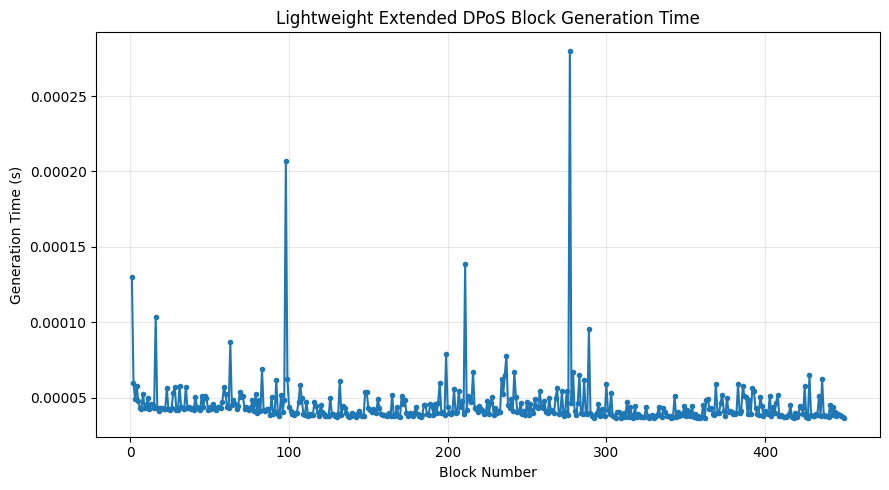

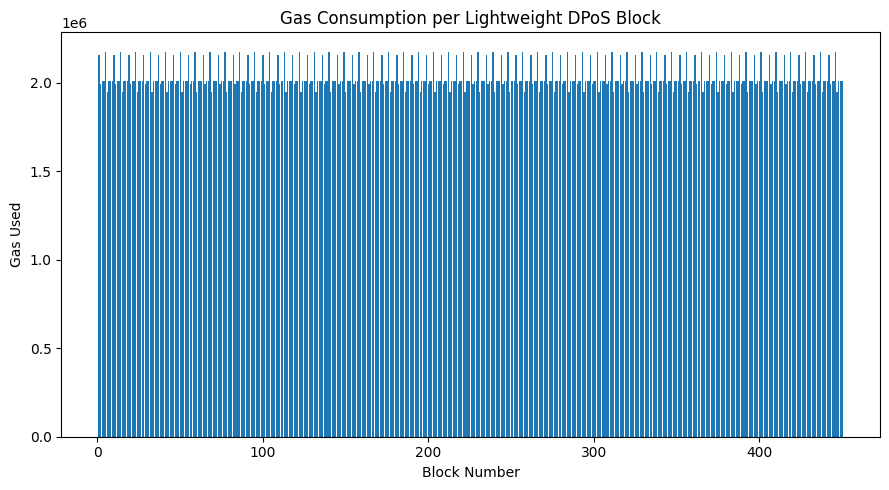

In [21]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 21 — Blockchain Performance Visualizations
# ═══════════════════════════════════════════════════════════════
if lightweight_blockchain.block_generation_times:
    plt.figure(figsize=(9, 5))

    plt.plot(
        range(
            1,
            len(lightweight_blockchain.block_generation_times) + 1
        ),
        lightweight_blockchain.block_generation_times,
        marker="o",
        markersize=3
    )

    plt.xlabel("Block Number")
    plt.ylabel("Generation Time (s)")
    plt.title(
        "Lightweight Extended DPoS Block Generation Time"
    )
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


gas_by_block = [
    block.gas_used
    for block in non_genesis_blocks
]

if gas_by_block:
    plt.figure(figsize=(9, 5))

    plt.bar(
        range(1, len(gas_by_block) + 1),
        gas_by_block
    )

    plt.xlabel("Block Number")
    plt.ylabel("Gas Used")
    plt.title("Gas Consumption per Lightweight DPoS Block")
    plt.tight_layout()
    plt.show()

In [22]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 22 — Combined Result Summary
# ═══════════════════════════════════════════════════════════════
print("Machine-Learning Results")
display(ml_results)

print("\nLightweight Blockchain Results")
display(blockchain_metrics)

print("\nExtended DPoS Delegate Results")
display(delegate_results)

print("\nPublic Transparency Portal")
display(transparency_portal_results.head())

Machine-Learning Results


,Metric,Value
0,Accuracy,0.999367
1,Precision,0.999895
2,Recall,0.999430
3,F1-Score,0.999663
4,ROC-AUC,0.999944
5,Training Time (s),198.738163
6,Prediction Time (s),1.248196



Lightweight Blockchain Results


,Metric,Value
0,Proof Type,Extended Delegated Proof of Stake (DPoS)
1,Projects Processed,1000
2,Total Transactions,9000
3,Total Blocks,450
4,Transaction Latency (s),0.0
5,Throughput (TPS),28983.714457
6,Average Block Generation Time (s),0.000045
7,Total Block Generation Time (s),0.020247
8,Chain Validation Time (s),0.004891
9,Average Gas Used,101644.888889



Extended DPoS Delegate Results


,Delegate,Stake,Reputation,Availability,Voting Score,Blocks Produced,Active Delegate
0,DELEGATE-07,91.381559,90.791610,97.580877,92.444438,90,True
1,DELEGATE-03,88.056985,94.651608,91.281136,90.680202,90,True
2,DELEGATE-01,88.697802,85.971961,98.585979,89.857685,90,True
3,DELEGATE-05,82.193256,95.569040,94.434142,88.654168,90,True
4,DELEGATE-02,84.868401,77.354434,99.756224,85.591776,90,True
5,DELEGATE-04,72.519297,84.269951,99.267650,81.394164,0,False
6,DELEGATE-06,61.361936,88.864620,90.638173,75.467988,0,False



Public Transparency Portal


,Project_ID,Allocated_Budget,Sent_to_City,Sent_to_Builder,Pending_at_City,Unreleased_Budget,Installment_Count,Utilization_Rate_Percent
0,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,500.80,500.80,500.80,0.0,0.0,3,100.0
1,CONT_AWD_47QSSC26F4R1B_4732_47QSHA21A000D_4732,189.34,189.34,189.34,0.0,0.0,3,100.0
2,CONT_AWD_SPE30026FXLL8_9700_SPE30025D4004_9700,18430.01,18430.01,18430.01,0.0,0.0,3,100.0
3,CONT_AWD_47QSSC26F3FRX_4732_47QSHA21A0009_4732,100.62,100.62,100.62,0.0,0.0,3,100.0
4,CONT_AWD_47QSSC26F3QKY_4732_47QSWA22D0009_4732,80.35,80.35,80.35,0.0,0.0,3,100.0


In [23]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 23 — Save and Download All Results
# ═══════════════════════════════════════════════════════════════
ml_results.to_csv(
    "ML_Results_GAN_USAspending_NoCV.csv",
    index=False
)

blockchain_metrics.to_csv(
    "Lightweight_DPoS_Blockchain_Metrics.csv",
    index=False
)

delegate_results.to_csv(
    "Extended_DPoS_Delegate_Results.csv",
    index=False
)

transparency_portal_results.to_csv(
    "Public_Transparency_Portal_Results.csv",
    index=False
)

processed_output_columns = [
    "Project_ID",
    "Project_Name",
    "Finance_Ministry",
    "Treasury",
    "City_Corporation",
    "Builder",
    "Budget",
    "Transaction_Amount",
    "Award_Type",
    "Project_Location",
    "Action_Date",
    "Risk_Label"
]

data[processed_output_columns].to_csv(
    "Processed_USAspending_Blockchain_Dataset.csv",
    index=False
)

print("Saved files:")
print("1. ML_Results_GAN_USAspending_NoCV.csv")
print("2. Lightweight_DPoS_Blockchain_Metrics.csv")
print("3. Extended_DPoS_Delegate_Results.csv")
print("4. Public_Transparency_Portal_Results.csv")
print("5. Processed_USAspending_Blockchain_Dataset.csv")

Saved files:
1. ML_Results_GAN_USAspending_NoCV.csv
2. Lightweight_DPoS_Blockchain_Metrics.csv
3. Extended_DPoS_Delegate_Results.csv
4. Public_Transparency_Portal_Results.csv
5. Processed_USAspending_Blockchain_Dataset.csv


In [24]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 24 — Register Original Result Files
# ═══════════════════════════════════════════════════════════════
# The original result files remain unchanged. Automatic browser
# downloads are deferred to the final reviewer package block so
# that "Run all" produces one consolidated ZIP file.

original_result_files = [
    "ML_Results_GAN_USAspending_NoCV.csv",
    "Lightweight_DPoS_Blockchain_Metrics.csv",
    "Extended_DPoS_Delegate_Results.csv",
    "Public_Transparency_Portal_Results.csv",
    "Processed_USAspending_Blockchain_Dataset.csv"
]

print("Original pipeline files registered for final packaging:")
for output_file in original_result_files:
    print(" -", output_file)

Original pipeline files registered for final packaging:
 - ML_Results_GAN_USAspending_NoCV.csv
 - Lightweight_DPoS_Blockchain_Metrics.csv
 - Extended_DPoS_Delegate_Results.csv
 - Public_Transparency_Portal_Results.csv
 - Processed_USAspending_Blockchain_Dataset.csv


# Reviewer-Strengthening Extension

The following blocks are added **after** the original pipeline and do not replace
its GAN, Random Forest, smart-contract simulation, Extended DPoS, or transparency
workflow.

## Reviewer questions covered

| Reviewer issue | Added evidence |
|---|---|
| Q1 Real government data | Dataset provenance, signed transaction reconstruction, chronological award replay |
| Q2 Multi-agency deployment | Multi-agency credential and role simulation, agency scalability experiment |
| Q3 Concurrency | Concurrent clients, percentile latency, throughput, memory, and failure-rate tests |
| Q4 Practical workflow | Enforced lifecycle state machine and invalid-transition tests |
| Q5 Tendering | Commit–reveal-style tender audit records and committee scoring |
| Q6 Construction quality | Milestone evidence hashes and dual engineer–auditor approval |
| Q7 Identity | Institutional credential registry with activation and revocation |
| Q8 Key management | Simulated key issue, rotation, revocation, and recovery events |
| Q9 Collusion | Malicious-delegate and committee-collusion simulation |
| Q10 Privacy | Public/restricted data separation and pseudonymized public records |
| Q11 Compliance/tracing | Compliance matrix and responsibility-tracing event log |
| Q12 Contract security | Executable simulation-level security invariant tests |
| Q13 Attack modelling | STRIDE-oriented attack table with observed test outcomes |
| Q14 Formal verification | Explicit properties and executable invariant evidence; Solidity verification remains external |
| Q15 Comparison | Same-workload in-memory baselines and expanded literature-comparison matrix |

> Results from the appended Python experiments must be described as **supplementary
> simulation results**. Smart-contract auditing and formal verification must still be
> run against the actual Solidity contracts.

In [25]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 25 — Reviewer Experiment Configuration
# ═══════════════════════════════════════════════════════════════
import copy
import math
import shutil
import threading
import tracemalloc
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
from dataclasses import dataclass
from enum import Enum

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

REVIEW_OUTPUT_DIR = "Reviewer_Strengthening_Outputs"
os.makedirs(REVIEW_OUTPUT_DIR, exist_ok=True)

# Runtime controls. Increase these values for a larger experiment.
REVIEW_RANDOM_SEED = SEED
REVIEW_PROJECT_SAMPLE_SIZE = min(250, len(data))
LOAD_TEST_TRANSACTION_COUNT = min(
    5000,
    max(1000, len(blockchain_data) * 2)
)
CONCURRENCY_LEVELS = [1, 5, 10, 25, 50, 100]
AGENCY_SCENARIOS = [3, 5, 10, 20]
COLLUSION_RATIOS = [0.00, 0.10, 0.20, 0.33, 0.50, 0.67]

# This supplementary model keeps the original GAN pipeline unchanged.
# Set to False for a faster reviewer-analysis run.
RUN_LEAKAGE_AWARE_GAN = True
LEAKAGE_AWARE_GAN_EPOCHS = 50

review_rng = np.random.default_rng(REVIEW_RANDOM_SEED)

print("Reviewer output directory:", REVIEW_OUTPUT_DIR)
print("Reviewer project sample:", REVIEW_PROJECT_SAMPLE_SIZE)
print("Load-test transactions per scenario:", LOAD_TEST_TRANSACTION_COUNT)

Reviewer output directory: Reviewer_Strengthening_Outputs
Reviewer project sample: 250
Load-test transactions per scenario: 2000


## Generated research evidence

### Main tables

The extension generates dataset profile and missingness tables; annual, agency,
and project-level transaction summaries; signed transaction replay records;
leakage-aware model results; agency identity and key-management records; tender,
quality, workflow, privacy, security, attack, formal-property, concurrency,
collusion, compliance, and comparison tables.

### Main figures

The extension generates:

1. annual signed and gross USAspending transaction trends;
2. top agencies by transaction amount;
3. proxy-risk class distribution;
4. chronological project-replay status;
5. original versus leakage-aware model performance;
6. ROC comparison and confusion matrix;
7. workflow-state and milestone-approval outcomes;
8. privacy data-classification counts;
9. concurrency throughput and tail latency;
10. multi-agency scalability;
11. malicious-delegate collusion and denial-of-service risk;
12. centralized versus DPoS architecture throughput and P95 latency;
13. security-invariant pass/fail results.

All tables are exported as CSV files, all figures are saved as 300-dpi PNG files,
and the complete package is compressed into one ZIP file.

In [26]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 26 — Reconstruct Signed USAspending Transaction Records
# Q1: Official-data provenance and chronological transaction replay
# ═══════════════════════════════════════════════════════════════
def reviewer_source_series(logical_name, default_value):
    return get_column_or_default(
        df,
        selected_columns.get(logical_name),
        default_value
    )


review_transaction_log = pd.DataFrame(index=df.index)

review_transaction_log["Project_ID"] = reviewer_source_series(
    "project_id",
    None
)

missing_ids = (
    review_transaction_log["Project_ID"].isna() |
    review_transaction_log["Project_ID"].astype(str).str.strip().eq("")
)

review_transaction_log.loc[missing_ids, "Project_ID"] = [
    f"RAW-PRJ-{index:09d}"
    for index in review_transaction_log.index[missing_ids]
]

review_transaction_log["Agency"] = reviewer_source_series(
    "finance_ministry",
    "Unknown Agency"
)

review_transaction_log["Recipient"] = reviewer_source_series(
    "builder",
    "Unknown Recipient"
)

review_transaction_log["Award_Type"] = reviewer_source_series(
    "award_type",
    "Unknown Award Type"
)

review_transaction_log["Location"] = reviewer_source_series(
    "location",
    "Unknown Location"
)

review_transaction_log["Action_Date"] = pd.to_datetime(
    reviewer_source_series("date", pd.NaT),
    errors="coerce"
)

review_transaction_log["Award_Budget"] = pd.to_numeric(
    reviewer_source_series("budget", 0),
    errors="coerce"
).replace([np.inf, -np.inf], np.nan).fillna(0).abs()

transaction_source = selected_columns.get("transaction_amount")

if transaction_source is not None:
    signed_amount = pd.to_numeric(
        df[transaction_source],
        errors="coerce"
    )
else:
    signed_amount = review_transaction_log["Award_Budget"]

review_transaction_log["Signed_Transaction_Amount"] = (
    signed_amount
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

review_transaction_log["Absolute_Transaction_Amount"] = (
    review_transaction_log["Signed_Transaction_Amount"].abs()
)

review_transaction_log["Is_Reversal"] = (
    review_transaction_log["Signed_Transaction_Amount"] < 0
)

for column in [
    "Project_ID",
    "Agency",
    "Recipient",
    "Award_Type",
    "Location"
]:
    review_transaction_log[column] = (
        review_transaction_log[column]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .replace("", "Unknown")
    )

review_transaction_log = (
    review_transaction_log
    .sort_values(
        ["Project_ID", "Action_Date"],
        na_position="last"
    )
    .reset_index(drop=True)
)

review_transaction_log["Transaction_Sequence"] = (
    review_transaction_log
    .groupby("Project_ID")
    .cumcount() + 1
)

review_transaction_log["Cumulative_Net_Amount"] = (
    review_transaction_log
    .groupby("Project_ID")["Signed_Transaction_Amount"]
    .cumsum()
)

review_transaction_log["Cumulative_Gross_Amount"] = (
    review_transaction_log
    .groupby("Project_ID")["Absolute_Transaction_Amount"]
    .cumsum()
)

review_transaction_log["Cumulative_Utilization_Percent"] = np.where(
    review_transaction_log["Award_Budget"] > 0,
    (
        review_transaction_log["Cumulative_Net_Amount"] /
        review_transaction_log["Award_Budget"]
    ) * 100,
    np.nan
)

print("Signed transaction log shape:", review_transaction_log.shape)
print("Negative/reversal actions:", int(review_transaction_log["Is_Reversal"].sum()))
display(review_transaction_log.head(10))

Signed transaction log shape: (1000000, 14)
Negative/reversal actions: 45544


,Project_ID,Agency,Recipient,Award_Type,Location,Action_Date,Award_Budget,Signed_Transaction_Amount,Absolute_Transaction_Amount,Is_Reversal,Transaction_Sequence,Cumulative_Net_Amount,Cumulative_Gross_Amount,Cumulative_Utilization_Percent
0,CONT_AWD_00003_8600_DU100G16D01_8600,Department of Housing and Urban Development,STATE STREET BANK AND TRUST COMPANY,DELIVERY ORDER,BOSTON,2026-03-03,1425330.81,0.00,0.00,False,1,0.00,0.00,0.000000
1,CONT_AWD_0001_5000_SECHQ117A0008_5000,Securities and Exchange Commission,"ASCELLA TECHNOLOGIES, INC.",BPA CALL,WASHINGTON,2026-02-12,76088871.65,-1016159.76,1016159.76,True,1,-1016159.76,1016159.76,-1.335491
2,CONT_AWD_0001_6920_DTFACT17D00007_6920,Department of Transportation,KARSUN SOLUTIONS LLC,DELIVERY ORDER,HERNDON,2026-02-05,19809033.26,165747.00,165747.00,False,1,165747.00,165747.00,0.836724
3,CONT_AWD_0001_6920_DTFACT17D00007_6920,Department of Transportation,KARSUN SOLUTIONS LLC,DELIVERY ORDER,HERNDON,2026-03-26,19809030.31,-2.95,2.95,True,2,165744.05,165749.95,0.836710
4,CONT_AWD_0001_6920_DTFAWA11A00237_6920,Department of Transportation,TREVOR L NEWMAN LLC,BPA CALL,ATLANTIC CITY,2026-01-23,12246756.30,-521.19,521.19,True,1,-521.19,521.19,-0.004256
5,CONT_AWD_0001_6920_DTFAWA17D00013_6920,Department of Transportation,"ADVANCED MANAGEMENT TECHNOLOGY, INC.",DELIVERY ORDER,WASHINGTON,2026-01-23,6910701.17,0.00,0.00,False,1,0.00,0.00,0.000000
6,CONT_AWD_0001_6920_DTFAWA17D00014_6920,Department of Transportation,"NOBLIS, INC.",DELIVERY ORDER,WASHINGTON,2025-12-10,6547366.35,230000.00,230000.00,False,1,230000.00,230000.00,3.512863
7,CONT_AWD_0001_6920_DTFAWA17D00014_6920,Department of Transportation,"NOBLIS, INC.",DELIVERY ORDER,WASHINGTON,2026-03-27,6809968.05,183515.15,183515.15,False,2,413515.15,413515.15,6.072204
8,CONT_AWD_0001_6920_DTFAWA17D00015_6920,Department of Transportation,LS TECHNOLOGIES LLC,DELIVERY ORDER,WASHINGTON,2025-12-05,6052928.90,278000.00,278000.00,False,1,278000.00,278000.00,4.592818
9,CONT_AWD_0001_6920_DTFAWA17D00015_6920,Department of Transportation,LS TECHNOLOGIES LLC,DELIVERY ORDER,WASHINGTON,2026-04-22,6393142.55,7500.00,7500.00,False,2,285500.00,285500.00,4.465722


In [27]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 27 — Dataset Profile, Missingness, Agency, and Annual Tables
# Q1: Data description required for a research-paper evaluation
# ═══════════════════════════════════════════════════════════════
valid_dates = review_transaction_log["Action_Date"].dropna()

dataset_profile_table = pd.DataFrame(
    [
        ("Data source", "USAspending.gov CSV supplied by the authors"),
        ("Raw rows", len(df)),
        ("Processed ML rows", len(data)),
        ("Signed transaction rows", len(review_transaction_log)),
        ("Unique projects/awards", review_transaction_log["Project_ID"].nunique()),
        ("Unique agencies", review_transaction_log["Agency"].nunique()),
        ("Unique recipients", review_transaction_log["Recipient"].nunique()),
        ("Unique award types", review_transaction_log["Award_Type"].nunique()),
        (
            "Observation start",
            valid_dates.min().date().isoformat()
            if not valid_dates.empty else "Unavailable"
        ),
        (
            "Observation end",
            valid_dates.max().date().isoformat()
            if not valid_dates.empty else "Unavailable"
        ),
        (
            "Gross absolute transaction amount",
            review_transaction_log["Absolute_Transaction_Amount"].sum()
        ),
        (
            "Net signed transaction amount",
            review_transaction_log["Signed_Transaction_Amount"].sum()
        ),
        ("Reversal transaction count", int(review_transaction_log["Is_Reversal"].sum())),
        ("Proxy-risk records", int(data["Risk_Label"].sum())),
        (
            "Proxy-risk rate (%)",
            float(data["Risk_Label"].mean() * 100)
        )
    ],
    columns=["Dataset_Characteristic", "Value"]
)

mapped_source_columns = [
    column
    for column in selected_columns.values()
    if column is not None
]

missingness_table = pd.DataFrame(
    {
        "Source_Column": mapped_source_columns,
        "Missing_Count": [
            int(df[column].isna().sum())
            for column in mapped_source_columns
        ],
        "Missing_Percent": [
            float(df[column].isna().mean() * 100)
            for column in mapped_source_columns
        ]
    }
).sort_values("Missing_Percent", ascending=False)

agency_summary_table = (
    review_transaction_log
    .groupby("Agency", as_index=False)
    .agg(
        Projects=("Project_ID", "nunique"),
        Transactions=("Project_ID", "size"),
        Gross_Amount=("Absolute_Transaction_Amount", "sum"),
        Net_Amount=("Signed_Transaction_Amount", "sum"),
        Reversals=("Is_Reversal", "sum")
    )
    .sort_values("Gross_Amount", ascending=False)
    .reset_index(drop=True)
)

annual_transaction_table = (
    review_transaction_log
    .dropna(subset=["Action_Date"])
    .assign(Year=lambda frame: frame["Action_Date"].dt.year)
    .groupby("Year", as_index=False)
    .agg(
        Transactions=("Project_ID", "size"),
        Projects=("Project_ID", "nunique"),
        Gross_Amount=("Absolute_Transaction_Amount", "sum"),
        Net_Amount=("Signed_Transaction_Amount", "sum"),
        Reversals=("Is_Reversal", "sum")
    )
    .sort_values("Year")
)

risk_distribution_table = (
    data["Risk_Label"]
    .value_counts()
    .rename_axis("Risk_Label")
    .reset_index(name="Count")
)

risk_distribution_table["Class"] = risk_distribution_table[
    "Risk_Label"
].map(
    {
        0: "Regular proxy pattern",
        1: "Unusual proxy pattern"
    }
)

risk_distribution_table["Percent"] = (
    risk_distribution_table["Count"] /
    risk_distribution_table["Count"].sum() * 100
)

print("Dataset profile")
display(dataset_profile_table)

print("\nMapped-field missingness")
display(missingness_table)

print("\nTop agencies")
display(agency_summary_table.head(15))

print("\nAnnual transaction summary")
display(annual_transaction_table.tail(15))

print("\nProxy-risk distribution")
display(risk_distribution_table)

Dataset profile


,Dataset_Characteristic,Value
0,Data source,USAspending.gov CSV supplied by the authors
1,Raw rows,1000000
2,Processed ML rows,916319
3,Signed transaction rows,1000000
4,Unique projects/awards,943255
5,Unique agencies,90
6,Unique recipients,48153
7,Unique award types,5
8,Observation start,2025-10-01
9,Observation end,2026-04-23



Mapped-field missingness


,Source_Column,Missing_Count,Missing_Percent
3,treasury_accounts_funding_this_award,819710,81.9710
10,primary_place_of_performance_city_name,85691,8.5691
9,award_type,58633,5.8633
6,current_total_value_of_award,58633,5.8633
1,transaction_description,70,0.0070
4,recipient_city_name,8,0.0008
2,funding_agency_name,3,0.0003
0,contract_award_unique_key,0,0.0000
5,recipient_name,0,0.0000
8,action_date,0,0.0000



Top agencies


,Agency,Projects,Transactions,Gross_Amount,Net_Amount,Reversals
0,Department of Defense,537901,550246,6.044068e+10,5.393880e+10,16291
1,Department of Veterans Affairs,23227,26159,1.512513e+10,1.403197e+10,4815
2,Department of Energy,1747,2540,1.284660e+10,1.200332e+10,257
3,Department of Homeland Security,8250,10148,1.268742e+10,1.194637e+10,1577
4,Department of Health and Human Services,7275,8130,6.590168e+09,5.505131e+09,1879
5,National Aeronautics and Space Administration,2735,4203,3.844487e+09,3.464415e+09,190
6,Department of Transportation,4704,6333,3.770406e+09,3.128165e+09,761
7,General Services Administration,304602,329098,2.582242e+09,2.374683e+09,8879
8,Department of Justice,16803,20528,2.385555e+09,2.044969e+09,4473
9,Department of Agriculture,8483,9625,1.975303e+09,1.737017e+09,1086



Annual transaction summary


,Year,Transactions,Projects,Gross_Amount,Net_Amount,Reversals
0,2025,577054,559689,7.673676e+10,6.898407e+10,22538
1,2026,422946,401490,5.510866e+10,4.918999e+10,23006



Proxy-risk distribution


,Risk_Label,Count,Class,Percent
0,1,860114,Unusual proxy pattern,93.866219
1,0,56205,Regular proxy pattern,6.133781


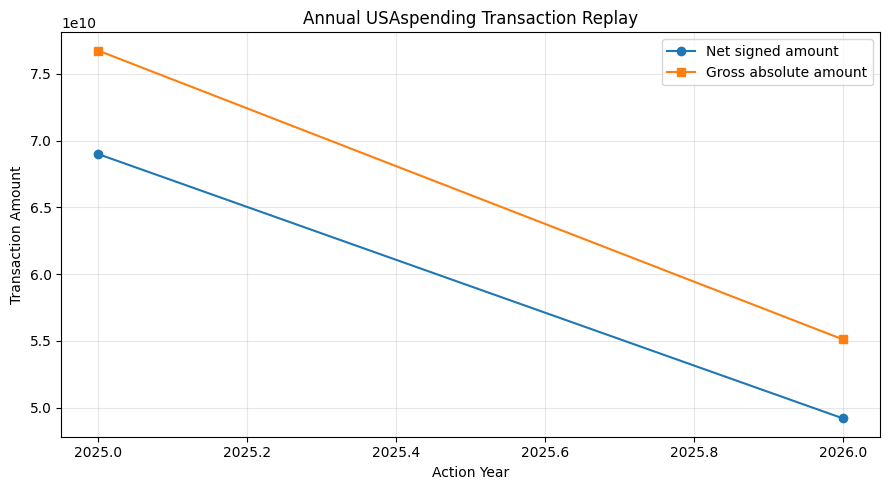

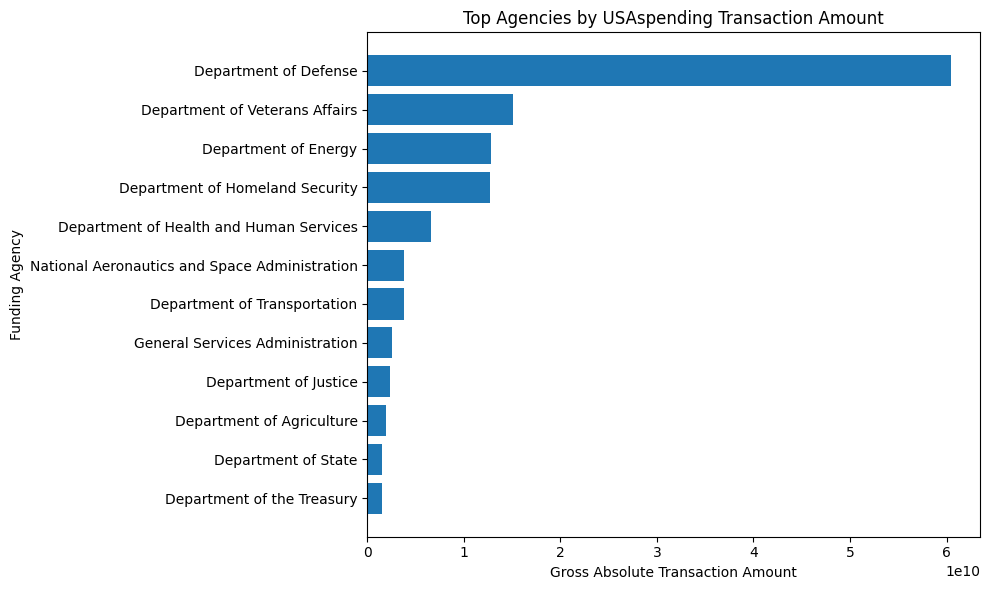

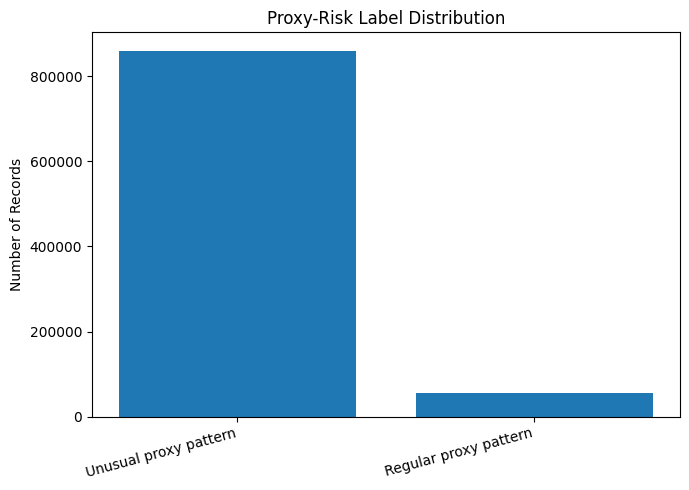

In [28]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 28 — Dataset and Government-Transaction Visualizations
# Q1: Publication-ready data graphs
# ═══════════════════════════════════════════════════════════════
if not annual_transaction_table.empty:
    plt.figure(figsize=(9, 5))
    plt.plot(
        annual_transaction_table["Year"],
        annual_transaction_table["Net_Amount"],
        marker="o",
        label="Net signed amount"
    )
    plt.plot(
        annual_transaction_table["Year"],
        annual_transaction_table["Gross_Amount"],
        marker="s",
        label="Gross absolute amount"
    )
    plt.xlabel("Action Year")
    plt.ylabel("Transaction Amount")
    plt.title("Annual USAspending Transaction Replay")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            REVIEW_OUTPUT_DIR,
            "Fig_R1_Annual_USAspending_Transaction_Replay.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


top_agencies_for_plot = agency_summary_table.head(12).sort_values(
    "Gross_Amount",
    ascending=True
)

if not top_agencies_for_plot.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(
        top_agencies_for_plot["Agency"],
        top_agencies_for_plot["Gross_Amount"]
    )
    plt.xlabel("Gross Absolute Transaction Amount")
    plt.ylabel("Funding Agency")
    plt.title("Top Agencies by USAspending Transaction Amount")
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            REVIEW_OUTPUT_DIR,
            "Fig_R2_Top_Agencies_by_Transaction_Amount.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


plt.figure(figsize=(7, 5))
plt.bar(
    risk_distribution_table["Class"],
    risk_distribution_table["Count"]
)
plt.ylabel("Number of Records")
plt.title("Proxy-Risk Label Distribution")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(
    os.path.join(
        REVIEW_OUTPUT_DIR,
        "Fig_R3_Proxy_Risk_Distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

This table replays observed signed transactions and is separate from the original fixed-installment blockchain experiment.


,Project_ID,Agency,Recipient,Award_Type,Location,First_Action_Date,Last_Action_Date,Transaction_Count,Reversal_Count,Gross_Transaction_Amount,Net_Transaction_Amount,Recorded_Award_Budget,Observed_Duration_Days,Replay_Utilization_Percent,Replay_Status
0,CONT_AWD_00003_8600_DU100G16D01_8600,Department of Housing and Urban Development,STATE STREET BANK AND TRUST COMPANY,DELIVERY ORDER,BOSTON,2026-03-03,2026-03-03,1,0,0.00,0.00,1.425331e+06,0,0.000000,Reversed/zero
1,CONT_AWD_0001_5000_SECHQ117A0008_5000,Securities and Exchange Commission,"ASCELLA TECHNOLOGIES, INC.",BPA CALL,WASHINGTON,2026-02-12,2026-02-12,1,1,1016159.76,-1016159.76,7.608887e+07,0,-1.335491,Reversed/zero
2,CONT_AWD_0001_6920_DTFACT17D00007_6920,Department of Transportation,KARSUN SOLUTIONS LLC,DELIVERY ORDER,HERNDON,2026-02-05,2026-03-26,2,1,165749.95,165744.05,1.980903e+07,49,0.836709,Low disbursement
3,CONT_AWD_0001_6920_DTFAWA11A00237_6920,Department of Transportation,TREVOR L NEWMAN LLC,BPA CALL,ATLANTIC CITY,2026-01-23,2026-01-23,1,1,521.19,-521.19,1.224676e+07,0,-0.004256,Reversed/zero
4,CONT_AWD_0001_6920_DTFAWA17D00013_6920,Department of Transportation,"ADVANCED MANAGEMENT TECHNOLOGY, INC.",DELIVERY ORDER,WASHINGTON,2026-01-23,2026-01-23,1,0,0.00,0.00,6.910701e+06,0,0.000000,Reversed/zero
5,CONT_AWD_0001_6920_DTFAWA17D00014_6920,Department of Transportation,"NOBLIS, INC.",DELIVERY ORDER,WASHINGTON,2025-12-10,2026-03-27,2,0,413515.15,413515.15,6.809968e+06,107,6.072204,Low disbursement
6,CONT_AWD_0001_6920_DTFAWA17D00015_6920,Department of Transportation,LS TECHNOLOGIES LLC,DELIVERY ORDER,WASHINGTON,2025-12-05,2026-04-22,2,0,285500.00,285500.00,6.393143e+06,138,4.465722,Low disbursement
7,CONT_AWD_0001_6920_DTFAWA17D00032_6920,Department of Transportation,VERACITY ENGINEERING LLC,DELIVERY ORDER,WASHINGTON,2025-11-13,2026-04-22,2,0,4090000.00,4090000.00,7.842745e+07,160,5.215011,Low disbursement
8,CONT_AWD_0001_6925_DTFH6114D00008_6925,Department of Transportation,"APPLIED RESEARCH ASSOCIATES, INC.",DELIVERY ORDER,ALBUQUERQUE,2026-02-25,2026-02-25,1,1,125891.79,-125891.79,1.140431e+05,0,-110.389611,Reversed/zero
9,CONT_AWD_0001_6925_DTFH6115A00003_6925,Department of Transportation,"THE MEDIA NETWORK, INC.",BPA CALL,SILVER SPRING,2025-10-16,2025-10-16,1,1,5677.65,-5677.65,7.580955e+05,0,-0.748936,Reversed/zero


,Replay_Status,Projects
0,Complete/over budget,783022
1,Reversed/zero,64543
2,NaN,52444
3,Low disbursement,25382
4,Partial disbursement,14969
5,Near complete,2895


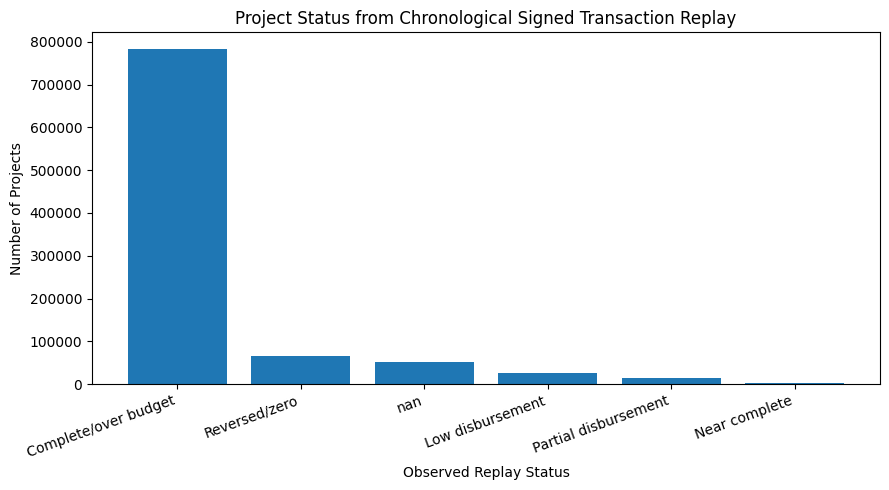

In [29]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 29 — Chronological Project-Level Transaction Replay
# Q1: Avoid fixed 40%-30%-30% assumptions in supplementary analysis
# ═══════════════════════════════════════════════════════════════
project_replay_summary = (
    review_transaction_log
    .groupby("Project_ID", as_index=False)
    .agg(
        Agency=("Agency", "first"),
        Recipient=("Recipient", "first"),
        Award_Type=("Award_Type", "first"),
        Location=("Location", "first"),
        First_Action_Date=("Action_Date", "min"),
        Last_Action_Date=("Action_Date", "max"),
        Transaction_Count=("Project_ID", "size"),
        Reversal_Count=("Is_Reversal", "sum"),
        Gross_Transaction_Amount=("Absolute_Transaction_Amount", "sum"),
        Net_Transaction_Amount=("Signed_Transaction_Amount", "sum"),
        Recorded_Award_Budget=("Award_Budget", "max")
    )
)

project_replay_summary["Observed_Duration_Days"] = (
    project_replay_summary["Last_Action_Date"] -
    project_replay_summary["First_Action_Date"]
).dt.days

project_replay_summary["Replay_Utilization_Percent"] = np.where(
    project_replay_summary["Recorded_Award_Budget"] > 0,
    (
        project_replay_summary["Net_Transaction_Amount"] /
        project_replay_summary["Recorded_Award_Budget"]
    ) * 100,
    np.nan
)

project_replay_summary["Replay_Status"] = pd.cut(
    project_replay_summary["Replay_Utilization_Percent"],
    bins=[-np.inf, 0, 25, 75, 99.999, np.inf],
    labels=[
        "Reversed/zero",
        "Low disbursement",
        "Partial disbursement",
        "Near complete",
        "Complete/over budget"
    ]
)

replay_status_table = (
    project_replay_summary["Replay_Status"]
    .value_counts(dropna=False)
    .rename_axis("Replay_Status")
    .reset_index(name="Projects")
)

print(
    "This table replays observed signed transactions and is separate "
    "from the original fixed-installment blockchain experiment."
)
display(project_replay_summary.head(15))
display(replay_status_table)

plt.figure(figsize=(9, 5))
plt.bar(
    replay_status_table["Replay_Status"].astype(str),
    replay_status_table["Projects"]
)
plt.xlabel("Observed Replay Status")
plt.ylabel("Number of Projects")
plt.title("Project Status from Chronological Signed Transaction Replay")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(
    os.path.join(
        REVIEW_OUTPUT_DIR,
        "Fig_R4_Chronological_Replay_Project_Status.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [30]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 30 — Leakage-Aware Supplementary Risk Evaluation
# Q1: Separate proxy-label demonstration from a less circular test
# ═══════════════════════════════════════════════════════════════
safe_categorical_features = [
    "Finance_Ministry",
    "Treasury",
    "City_Corporation",
    "Award_Type",
    "Project_Location"
]

safe_numeric_features = [
    "Action_Year",
    "Action_Month",
    "Action_Day",
    "Recipient_Name_Length",
    "Project_Name_Length"
]

safe_feature_columns = (
    safe_categorical_features +
    safe_numeric_features
)

X_safe = data[safe_feature_columns].copy()
y_safe = data["Risk_Label"].astype(int).copy()
group_ids = data["Project_ID"].astype(str).copy()

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

safe_train_indices, safe_test_indices = next(
    group_split.split(
        X_safe,
        y_safe,
        groups=group_ids
    )
)

X_safe_train_raw = X_safe.iloc[safe_train_indices].copy()
X_safe_test_raw = X_safe.iloc[safe_test_indices].copy()
y_safe_train = y_safe.iloc[safe_train_indices].to_numpy(dtype=np.int32)
y_safe_test = y_safe.iloc[safe_test_indices].to_numpy(dtype=np.int32)

# A grouped split can occasionally create a one-class test set.
# Fall back to the original stratified procedure only when necessary.
if len(np.unique(y_safe_train)) < 2 or len(np.unique(y_safe_test)) < 2:
    (
        X_safe_train_raw,
        X_safe_test_raw,
        y_safe_train_series,
        y_safe_test_series
    ) = train_test_split(
        X_safe,
        y_safe,
        test_size=0.20,
        random_state=SEED,
        stratify=y_safe
    )

    y_safe_train = y_safe_train_series.to_numpy(dtype=np.int32)
    y_safe_test = y_safe_test_series.to_numpy(dtype=np.int32)
    safe_split_type = "Stratified fallback"
else:
    safe_split_type = "Project-grouped holdout"

safe_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            safe_categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            safe_numeric_features
        )
    ],
    remainder="drop"
)

X_safe_train = safe_preprocessor.fit_transform(
    X_safe_train_raw
).astype(np.float32)

X_safe_test = safe_preprocessor.transform(
    X_safe_test_raw
).astype(np.float32)

if (
    RUN_LEAKAGE_AWARE_GAN and
    len(np.unique(y_safe_train)) == 2 and
    np.min(np.bincount(y_safe_train)) >= 2
):
    (
        X_safe_train_balanced,
        y_safe_train_balanced,
        leakage_aware_gan_history
    ) = gan_oversample(
        X_safe_train,
        y_safe_train,
        latent_dimension=32,
        epochs=LEAKAGE_AWARE_GAN_EPOCHS,
        batch_size=64,
        verbose_interval=max(10, LEAKAGE_AWARE_GAN_EPOCHS // 2)
    )
else:
    X_safe_train_balanced = X_safe_train
    y_safe_train_balanced = y_safe_train
    leakage_aware_gan_history = None

leakage_aware_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

safe_training_start = time.perf_counter()
leakage_aware_classifier.fit(
    X_safe_train_balanced,
    y_safe_train_balanced
)
safe_training_time = time.perf_counter() - safe_training_start

safe_prediction_start = time.perf_counter()
safe_prediction = leakage_aware_classifier.predict(X_safe_test)
safe_probability = leakage_aware_classifier.predict_proba(X_safe_test)[:, 1]
safe_prediction_time = time.perf_counter() - safe_prediction_start

safe_accuracy = accuracy_score(y_safe_test, safe_prediction)
safe_precision = precision_score(
    y_safe_test,
    safe_prediction,
    zero_division=0
)
safe_recall = recall_score(
    y_safe_test,
    safe_prediction,
    zero_division=0
)
safe_f1 = f1_score(
    y_safe_test,
    safe_prediction,
    zero_division=0
)

try:
    safe_roc_auc = roc_auc_score(y_safe_test, safe_probability)
    safe_average_precision = average_precision_score(
        y_safe_test,
        safe_probability
    )
except ValueError:
    safe_roc_auc = np.nan
    safe_average_precision = np.nan

original_average_precision = (
    average_precision_score(y_test, y_probability)
    if len(np.unique(y_test)) == 2
    else np.nan
)

leakage_aware_ml_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "ROC-AUC",
            "Average Precision",
            "Training Time (s)",
            "Prediction Time (s)"
        ],
        "Value": [
            safe_accuracy,
            safe_precision,
            safe_recall,
            safe_f1,
            safe_roc_auc,
            safe_average_precision,
            safe_training_time,
            safe_prediction_time
        ]
    }
)

ml_robustness_comparison = pd.DataFrame(
    [
        {
            "Experiment": "Original model",
            "Split": "Random stratified",
            "Direct_Label_Generator_Features": "Included",
            "GAN": "Yes",
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "ROC_AUC": roc_auc,
            "Average_Precision": original_average_precision
        },
        {
            "Experiment": "Leakage-aware supplementary model",
            "Split": safe_split_type,
            "Direct_Label_Generator_Features": "Excluded",
            "GAN": "Yes" if leakage_aware_gan_history is not None else "No",
            "Accuracy": safe_accuracy,
            "Precision": safe_precision,
            "Recall": safe_recall,
            "F1_Score": safe_f1,
            "ROC_AUC": safe_roc_auc,
            "Average_Precision": safe_average_precision
        }
    ]
)

safe_confusion_matrix = confusion_matrix(
    y_safe_test,
    safe_prediction
)

print("Leakage-aware supplementary results")
display(leakage_aware_ml_results)

print("\nOriginal versus leakage-aware evaluation")
display(ml_robustness_comparison)

print("\nLeakage-aware confusion matrix")
display(
    pd.DataFrame(
        safe_confusion_matrix,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
)

Minority class: 0
Majority class: 1
Minority samples: 45057
Majority samples: 688118
Synthetic samples required: 643061
Epoch    1/50 | D Loss: 87.4548 | G Loss: 0.6150
Epoch   25/50 | D Loss: 50.2312 | G Loss: 0.6512
Epoch   50/50 | D Loss: 43.7949 | G Loss: 0.6485
Leakage-aware supplementary results


,Metric,Value
0,Accuracy,0.950476
1,Precision,0.957904
2,Recall,0.990808
3,F1-Score,0.974078
4,ROC-AUC,0.950243
5,Average Precision,0.996282
6,Training Time (s),87.054287
7,Prediction Time (s),1.431835



Original versus leakage-aware evaluation


,Experiment,Split,Direct_Label_Generator_Features,GAN,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Average_Precision
0,Original model,Random stratified,Included,Yes,0.999367,0.999895,0.999430,0.999663,0.999944,0.999996
1,Leakage-aware supplementary model,Project-grouped holdout,Excluded,Yes,0.950476,0.957904,0.990808,0.974078,0.950243,0.996282



Leakage-aware confusion matrix


,Predicted 0,Predicted 1
Actual 0,3659,7489
Actual 1,1581,170415


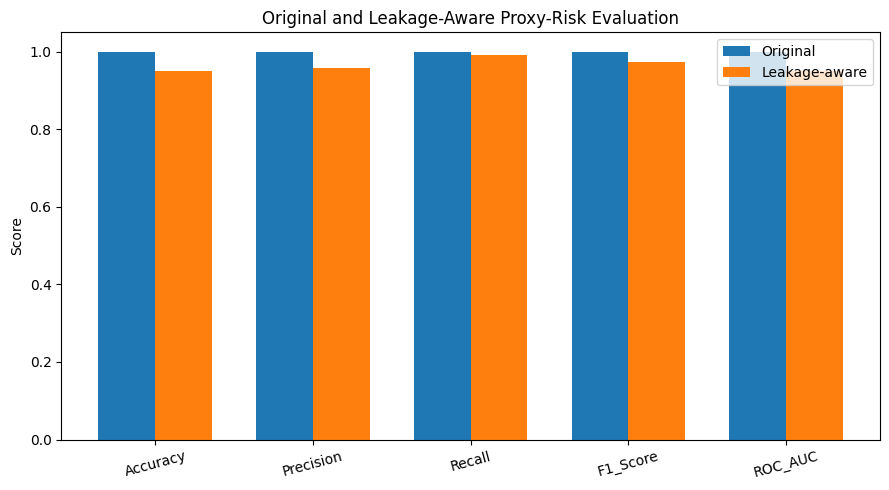

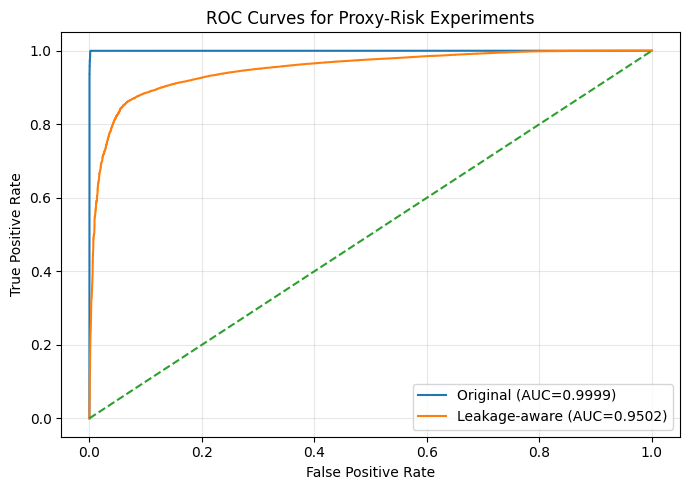

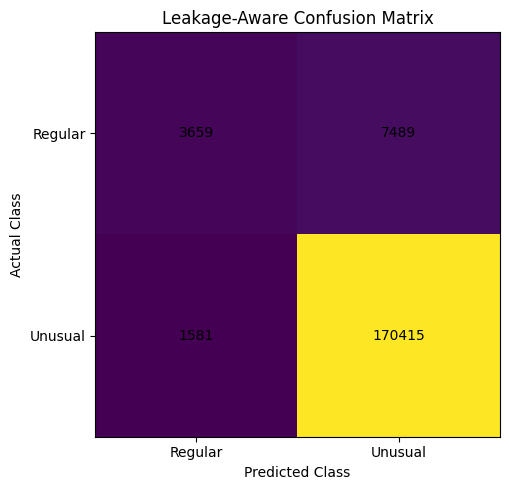

In [31]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 31 — Supplementary ML Visualizations
# ═══════════════════════════════════════════════════════════════
comparison_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

plot_positions = np.arange(len(comparison_metrics))
bar_width = 0.36

plt.figure(figsize=(9, 5))
plt.bar(
    plot_positions - bar_width / 2,
    ml_robustness_comparison.loc[0, comparison_metrics].astype(float),
    width=bar_width,
    label="Original"
)
plt.bar(
    plot_positions + bar_width / 2,
    ml_robustness_comparison.loc[1, comparison_metrics].astype(float),
    width=bar_width,
    label="Leakage-aware"
)
plt.xticks(plot_positions, comparison_metrics, rotation=15)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Original and Leakage-Aware Proxy-Risk Evaluation")
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(
        REVIEW_OUTPUT_DIR,
        "Fig_R5_Original_vs_Leakage_Aware_ML.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


if len(np.unique(y_safe_test)) == 2:
    safe_fpr, safe_tpr, _ = roc_curve(
        y_safe_test,
        safe_probability
    )

    original_fpr, original_tpr, _ = roc_curve(
        y_test,
        y_probability
    )

    plt.figure(figsize=(7, 5))
    plt.plot(
        original_fpr,
        original_tpr,
        label=f"Original (AUC={roc_auc:.4f})"
    )
    plt.plot(
        safe_fpr,
        safe_tpr,
        label=f"Leakage-aware (AUC={safe_roc_auc:.4f})"
    )
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves for Proxy-Risk Experiments")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            REVIEW_OUTPUT_DIR,
            "Fig_R6_Proxy_Risk_ROC_Comparison.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


plt.figure(figsize=(6, 5))
plt.imshow(safe_confusion_matrix)
plt.title("Leakage-Aware Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks([0, 1], ["Regular", "Unusual"])
plt.yticks([0, 1], ["Regular", "Unusual"])

for row_index in range(safe_confusion_matrix.shape[0]):
    for column_index in range(safe_confusion_matrix.shape[1]):
        plt.text(
            column_index,
            row_index,
            str(safe_confusion_matrix[row_index, column_index]),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.savefig(
    os.path.join(
        REVIEW_OUTPUT_DIR,
        "Fig_R7_Leakage_Aware_Confusion_Matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [32]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 32 — Multi-Agency Identity and Key-Management Simulation
# Q2, Q7, Q8: Institutional deployment model
# ═══════════════════════════════════════════════════════════════
@dataclass
class InstitutionalCredential:
    organization_id: str
    organization_name: str
    role: str
    wallet_id: str
    credential_hash: str
    status: str = "ACTIVE"
    version: int = 1


class InstitutionalIdentityRegistry:
    def __init__(self):
        self.credentials = {}
        self.events = []

    def register(self, organization_name, role):
        organization_id = (
            "ORG-" +
            stable_hash(
                {
                    "name": organization_name,
                    "role": role
                }
            )[:12].upper()
        )

        wallet_id = (
            "WALLET-" +
            stable_hash(
                {
                    "organization_id": organization_id,
                    "version": 1
                }
            )[:12].upper()
        )

        credential = InstitutionalCredential(
            organization_id=organization_id,
            organization_name=str(organization_name),
            role=str(role),
            wallet_id=wallet_id,
            credential_hash=stable_hash(
                {
                    "organization_id": organization_id,
                    "wallet_id": wallet_id,
                    "issuer": "SIMULATED-GOVERNMENT-PKI"
                }
            )
        )

        self.credentials[organization_id] = credential
        self.events.append(
            {
                "Organization_ID": organization_id,
                "Event": "ISSUE",
                "Wallet_ID": wallet_id,
                "Credential_Version": 1,
                "Status": "ACTIVE",
                "Timestamp": time.time()
            }
        )

        return credential

    def rotate_key(self, organization_id):
        credential = self.credentials[organization_id]
        old_wallet = credential.wallet_id
        credential.version += 1
        credential.wallet_id = (
            "WALLET-" +
            stable_hash(
                {
                    "organization_id": organization_id,
                    "version": credential.version
                }
            )[:12].upper()
        )
        credential.credential_hash = stable_hash(
            {
                "organization_id": organization_id,
                "wallet_id": credential.wallet_id,
                "version": credential.version
            }
        )

        self.events.append(
            {
                "Organization_ID": organization_id,
                "Event": "ROTATE",
                "Wallet_ID": credential.wallet_id,
                "Previous_Wallet_ID": old_wallet,
                "Credential_Version": credential.version,
                "Status": credential.status,
                "Timestamp": time.time()
            }
        )

    def revoke(self, organization_id, reason):
        credential = self.credentials[organization_id]
        credential.status = "REVOKED"

        self.events.append(
            {
                "Organization_ID": organization_id,
                "Event": "REVOKE",
                "Wallet_ID": credential.wallet_id,
                "Credential_Version": credential.version,
                "Status": "REVOKED",
                "Reason": reason,
                "Timestamp": time.time()
            }
        )

    def is_active(self, organization_id):
        return (
            organization_id in self.credentials and
            self.credentials[organization_id].status == "ACTIVE"
        )


identity_registry = InstitutionalIdentityRegistry()

base_organizations = [
    ("Finance Ministry", "FINANCE_MINISTRY"),
    ("Treasury Department", "TREASURY"),
    ("Procurement Authority", "PROCUREMENT"),
    ("Independent Auditor", "AUDITOR"),
    ("Engineering Inspection Unit", "ENGINEER"),
    ("Anti-Corruption Authority", "OVERSIGHT"),
    ("Public Transparency Office", "PUBLIC_PORTAL")
]

top_source_agencies = (
    agency_summary_table["Agency"]
    .head(13)
    .tolist()
)

for agency_name in top_source_agencies:
    base_organizations.append(
        (agency_name, "AGENCY_NODE")
    )

registered_credentials = [
    identity_registry.register(name, role)
    for name, role in base_organizations
]

# Demonstrate one key rotation and one revocation.
if registered_credentials:
    identity_registry.rotate_key(
        registered_credentials[0].organization_id
    )

if len(registered_credentials) > 1:
    identity_registry.revoke(
        registered_credentials[-1].organization_id,
        "Simulated credential-compromise response"
    )

multi_agency_registry_table = pd.DataFrame(
    [
        {
            "Organization_ID": credential.organization_id,
            "Organization_Name": credential.organization_name,
            "Role": credential.role,
            "Wallet_ID": credential.wallet_id,
            "Credential_Hash": credential.credential_hash,
            "Credential_Version": credential.version,
            "Status": credential.status
        }
        for credential in identity_registry.credentials.values()
    ]
)

key_management_event_table = pd.DataFrame(
    identity_registry.events
)

role_permission_matrix_table = pd.DataFrame(
    [
        ("createProject", "FINANCE_MINISTRY", "Single role + institutional credential"),
        ("publishTender", "PROCUREMENT", "Institutional credential"),
        ("finalizeTender", "PROCUREMENT + AUDITOR", "2-of-2 approval"),
        ("approveMilestone", "ENGINEER + AUDITOR", "2-of-2 approval"),
        ("releaseInstallment", "TREASURY + FINANCE_MINISTRY", "2-of-2 approval"),
        ("changeBuilder", "PROCUREMENT + AUDITOR", "2-of-2 approval"),
        ("changeBudget", "FINANCE_MINISTRY + OVERSIGHT", "2-of-2 approval"),
        ("emergencyPause", "FINANCE_MINISTRY + AUDITOR + OVERSIGHT", "2-of-3 approval"),
        ("readPublicSummary", "PUBLIC", "No wallet required")
    ],
    columns=[
        "Action",
        "Required_Roles",
        "Approval_Policy"
    ]
)

display(multi_agency_registry_table)
display(key_management_event_table)
display(role_permission_matrix_table)

,Organization_ID,Organization_Name,Role,Wallet_ID,Credential_Hash,Credential_Version,Status
0,ORG-E5B9D439EEE1,Finance Ministry,FINANCE_MINISTRY,WALLET-DE7ADD45CB6A,8c4d86c1b077b33a6255095178c22aa313bb5012612252...,2,ACTIVE
1,ORG-A24BC40958F0,Treasury Department,TREASURY,WALLET-A563FC2315BC,ea5b9cd7a13d19a3a2f6bae41f4e6f7fc274257e9cae4c...,1,ACTIVE
2,ORG-A5F4157CA8A6,Procurement Authority,PROCUREMENT,WALLET-4D8F73031ACD,40bdd6362d1f5d2a9006517473f578fce915de66a0bba2...,1,ACTIVE
3,ORG-4F150A9A31FC,Independent Auditor,AUDITOR,WALLET-EE651FAB3D3A,cfde4cdfcdee9764973dad6eb6461a0a57d7605f9dbb9a...,1,ACTIVE
4,ORG-9123C4917A2C,Engineering Inspection Unit,ENGINEER,WALLET-095012FA7DCA,ee4d32e06299e4f294d0aad7e209b35788f4ecd129057b...,1,ACTIVE
5,ORG-48B874EA2D48,Anti-Corruption Authority,OVERSIGHT,WALLET-EB1A80DCE09C,5ce7ff94ec628c99a2bd502b3737bc7c7a65f38094508c...,1,ACTIVE
6,ORG-1D3C3BC7383A,Public Transparency Office,PUBLIC_PORTAL,WALLET-DAD8E8261D8B,2139d98ae2a9d10f5ca42ea89b9fc1d87bd6e474a4a840...,1,ACTIVE
7,ORG-C2BDF5C5BF31,Department of Defense,AGENCY_NODE,WALLET-61FB33FAE00D,1f46660aeae10e1ed265e11a960bb985e2e08090e52783...,1,ACTIVE
8,ORG-BE918087241A,Department of Veterans Affairs,AGENCY_NODE,WALLET-578C69D4409D,c3d77d13d8a1dc08d70a2cbf65ae701261a2d35bad08dd...,1,ACTIVE
9,ORG-71073341A186,Department of Energy,AGENCY_NODE,WALLET-C5448A429D4E,5bbd16b59f012e53fc7428ebfc4a6a88f40a8e1d355b59...,1,ACTIVE


,Organization_ID,Event,Wallet_ID,Credential_Version,Status,Timestamp,Previous_Wallet_ID,Reason
0,ORG-E5B9D439EEE1,ISSUE,WALLET-C353112F1088,1,ACTIVE,1.784431e+09,NaN,NaN
1,ORG-A24BC40958F0,ISSUE,WALLET-A563FC2315BC,1,ACTIVE,1.784431e+09,NaN,NaN
2,ORG-A5F4157CA8A6,ISSUE,WALLET-4D8F73031ACD,1,ACTIVE,1.784431e+09,NaN,NaN
3,ORG-4F150A9A31FC,ISSUE,WALLET-EE651FAB3D3A,1,ACTIVE,1.784431e+09,NaN,NaN
4,ORG-9123C4917A2C,ISSUE,WALLET-095012FA7DCA,1,ACTIVE,1.784431e+09,NaN,NaN
5,ORG-48B874EA2D48,ISSUE,WALLET-EB1A80DCE09C,1,ACTIVE,1.784431e+09,NaN,NaN
6,ORG-1D3C3BC7383A,ISSUE,WALLET-DAD8E8261D8B,1,ACTIVE,1.784431e+09,NaN,NaN
7,ORG-C2BDF5C5BF31,ISSUE,WALLET-61FB33FAE00D,1,ACTIVE,1.784431e+09,NaN,NaN
8,ORG-BE918087241A,ISSUE,WALLET-578C69D4409D,1,ACTIVE,1.784431e+09,NaN,NaN
9,ORG-71073341A186,ISSUE,WALLET-C5448A429D4E,1,ACTIVE,1.784431e+09,NaN,NaN


,Action,Required_Roles,Approval_Policy
0,createProject,FINANCE_MINISTRY,Single role + institutional credential
1,publishTender,PROCUREMENT,Institutional credential
2,finalizeTender,PROCUREMENT + AUDITOR,2-of-2 approval
3,approveMilestone,ENGINEER + AUDITOR,2-of-2 approval
4,releaseInstallment,TREASURY + FINANCE_MINISTRY,2-of-2 approval
5,changeBuilder,PROCUREMENT + AUDITOR,2-of-2 approval
6,changeBudget,FINANCE_MINISTRY + OVERSIGHT,2-of-2 approval
7,emergencyPause,FINANCE_MINISTRY + AUDITOR + OVERSIGHT,2-of-3 approval
8,readPublicSummary,PUBLIC,No wallet required


In [33]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 33 — Tender, Workflow, and Construction-Quality Validation
# Q4, Q5, Q6, Q11: Practical lifecycle simulation
# ═══════════════════════════════════════════════════════════════
class ProjectState(Enum):
    DRAFT = "DRAFT"
    BUDGET_APPROVED = "BUDGET_APPROVED"
    TENDER_OPEN = "TENDER_OPEN"
    TENDER_CLOSED = "TENDER_CLOSED"
    CONTRACT_AWARDED = "CONTRACT_AWARDED"
    WORK_STARTED = "WORK_STARTED"
    MILESTONE_SUBMITTED = "MILESTONE_SUBMITTED"
    MILESTONE_VERIFIED = "MILESTONE_VERIFIED"
    PAYMENT_RELEASED = "PAYMENT_RELEASED"
    COMPLETED = "COMPLETED"
    AUDITED = "AUDITED"
    DISPUTED = "DISPUTED"


ALLOWED_TRANSITIONS = {
    ProjectState.DRAFT: {ProjectState.BUDGET_APPROVED},
    ProjectState.BUDGET_APPROVED: {ProjectState.TENDER_OPEN},
    ProjectState.TENDER_OPEN: {ProjectState.TENDER_CLOSED},
    ProjectState.TENDER_CLOSED: {ProjectState.CONTRACT_AWARDED},
    ProjectState.CONTRACT_AWARDED: {ProjectState.WORK_STARTED},
    ProjectState.WORK_STARTED: {
        ProjectState.MILESTONE_SUBMITTED,
        ProjectState.DISPUTED
    },
    ProjectState.MILESTONE_SUBMITTED: {
        ProjectState.MILESTONE_VERIFIED,
        ProjectState.DISPUTED
    },
    ProjectState.MILESTONE_VERIFIED: {
        ProjectState.PAYMENT_RELEASED
    },
    ProjectState.PAYMENT_RELEASED: {
        ProjectState.MILESTONE_SUBMITTED,
        ProjectState.COMPLETED
    },
    ProjectState.COMPLETED: {ProjectState.AUDITED},
    ProjectState.DISPUTED: {
        ProjectState.MILESTONE_SUBMITTED,
        ProjectState.WORK_STARTED
    },
    ProjectState.AUDITED: set()
}


class GovernedProjectWorkflow:
    def __init__(self, project_id, budget):
        self.project_id = str(project_id)
        self.budget = float(budget)
        self.state = ProjectState.DRAFT
        self.total_paid = 0.0
        self.events = []

    def transition(self, next_state, actor_role, evidence_hash=None):
        if next_state not in ALLOWED_TRANSITIONS[self.state]:
            return False

        previous_state = self.state
        self.state = next_state

        self.events.append(
            {
                "Project_ID": self.project_id,
                "Previous_State": previous_state.value,
                "New_State": next_state.value,
                "Actor_Role": actor_role,
                "Evidence_Hash": evidence_hash,
                "Timestamp": time.time()
            }
        )

        return True

    def release_payment(self, amount):
        amount = float(amount)

        if self.state != ProjectState.MILESTONE_VERIFIED:
            return False

        if amount <= 0 or self.total_paid + amount > self.budget:
            return False

        self.total_paid += amount

        return self.transition(
            ProjectState.PAYMENT_RELEASED,
            actor_role="TREASURY + FINANCE_MINISTRY",
            evidence_hash=stable_hash(
                {
                    "project_id": self.project_id,
                    "amount": amount,
                    "payment_number": len(
                        [
                            event
                            for event in self.events
                            if event["New_State"] ==
                            ProjectState.PAYMENT_RELEASED.value
                        ]
                    ) + 1
                }
            )
        )


workflow_project_sample = (
    blockchain_data
    .head(REVIEW_PROJECT_SAMPLE_SIZE)
    .copy()
)

tender_records = []
quality_records = []
responsibility_records = []
project_workflow_records = []
invalid_transition_records = []

for row_number, row in workflow_project_sample.iterrows():
    project_id = str(row["Project_ID"])
    budget = float(row["Budget"])

    workflow = GovernedProjectWorkflow(
        project_id=project_id,
        budget=budget
    )

    # Invalid early payment attempt: it must be blocked.
    invalid_payment_result = workflow.release_payment(
        budget * 0.10
    )

    invalid_transition_records.append(
        {
            "Scenario": "Payment before tender and milestone approval",
            "Project_ID": project_id,
            "Expected": "Blocked",
            "Observed": (
                "Accepted"
                if invalid_payment_result
                else "Blocked"
            ),
            "Pass": not invalid_payment_result
        }
    )

    workflow.transition(
        ProjectState.BUDGET_APPROVED,
        "FINANCE_MINISTRY + OVERSIGHT",
        stable_hash({"project_id": project_id, "document": "budget"})
    )

    workflow.transition(
        ProjectState.TENDER_OPEN,
        "PROCUREMENT",
        stable_hash({"project_id": project_id, "document": "tender"})
    )

    bidder_scores = review_rng.uniform(60, 100, size=3)
    bid_commitments = [
        stable_hash(
            {
                "project_id": project_id,
                "bidder": bidder_index,
                "score": round(float(score), 4)
            }
        )
        for bidder_index, score in enumerate(
            bidder_scores,
            start=1
        )
    ]

    winning_bidder_index = int(np.argmax(bidder_scores)) + 1
    winning_score = float(np.max(bidder_scores))

    workflow.transition(
        ProjectState.TENDER_CLOSED,
        "PROCUREMENT",
        stable_hash(bid_commitments)
    )

    tender_approved = winning_score >= 70

    if tender_approved:
        workflow.transition(
            ProjectState.CONTRACT_AWARDED,
            "PROCUREMENT + AUDITOR",
            stable_hash(
                {
                    "winner": winning_bidder_index,
                    "score": winning_score
                }
            )
        )

    tender_records.append(
        {
            "Project_ID": project_id,
            "Tender_Document_Hash": stable_hash(
                {
                    "project_id": project_id,
                    "tender_version": 1
                }
            ),
            "Bid_Count": len(bidder_scores),
            "Bid_Commitment_Root": stable_hash(bid_commitments),
            "Winning_Bidder": f"BIDDER-{winning_bidder_index:02d}",
            "Winning_Score": winning_score,
            "Procurement_Approval": tender_approved,
            "Auditor_Approval": tender_approved,
            "Challenge_Period_Status": "CLOSED",
            "Award_Finalized": tender_approved
        }
    )

    if not tender_approved:
        workflow.state = ProjectState.DISPUTED
    else:
        workflow.transition(
            ProjectState.WORK_STARTED,
            "BUILDER"
        )

        installment_fractions = [0.40, 0.30, 0.30]

        for milestone_number, fraction in enumerate(
            installment_fractions,
            start=1
        ):
            workflow.transition(
                ProjectState.MILESTONE_SUBMITTED,
                "BUILDER",
                stable_hash(
                    {
                        "project_id": project_id,
                        "milestone": milestone_number,
                        "evidence": "geotagged-report"
                    }
                )
            )

            engineer_score = float(
                review_rng.uniform(60, 100)
            )
            auditor_score = float(
                review_rng.uniform(60, 100)
            )

            engineer_approved = engineer_score >= 70
            auditor_approved = auditor_score >= 70
            milestone_approved = (
                engineer_approved and auditor_approved
            )

            evidence_hash = stable_hash(
                {
                    "project_id": project_id,
                    "milestone": milestone_number,
                    "engineer_score": engineer_score,
                    "auditor_score": auditor_score
                }
            )

            if milestone_approved:
                workflow.transition(
                    ProjectState.MILESTONE_VERIFIED,
                    "ENGINEER + AUDITOR",
                    evidence_hash
                )

                payment_released = workflow.release_payment(
                    budget * fraction
                )
            else:
                workflow.transition(
                    ProjectState.DISPUTED,
                    "ENGINEER + AUDITOR",
                    evidence_hash
                )
                payment_released = False

            quality_records.append(
                {
                    "Project_ID": project_id,
                    "Milestone": milestone_number,
                    "Evidence_Hash": evidence_hash,
                    "Engineer_Score": engineer_score,
                    "Engineer_Approved": engineer_approved,
                    "Auditor_Score": auditor_score,
                    "Auditor_Approved": auditor_approved,
                    "Milestone_Approved": milestone_approved,
                    "Payment_Released": payment_released,
                    "Requested_Amount": budget * fraction
                }
            )

            if not milestone_approved:
                break

        if workflow.total_paid >= budget - 1e-8:
            workflow.transition(
                ProjectState.COMPLETED,
                "ENGINEER + AUDITOR"
            )
            workflow.transition(
                ProjectState.AUDITED,
                "INDEPENDENT_AUDITOR"
            )

    responsibility_records.extend(workflow.events)

    project_workflow_records.append(
        {
            "Project_ID": project_id,
            "Final_State": workflow.state.value,
            "Allocated_Budget": budget,
            "Total_Paid": workflow.total_paid,
            "Payment_Percent": (
                workflow.total_paid / budget * 100
                if budget > 0 else 0
            ),
            "Tender_Finalized": tender_approved,
            "Event_Count": len(workflow.events)
        }
    )

tender_audit_table = pd.DataFrame(tender_records)
quality_verification_table = pd.DataFrame(quality_records)
responsibility_trace_table = pd.DataFrame(responsibility_records)
project_workflow_summary = pd.DataFrame(project_workflow_records)
workflow_validation_table = pd.DataFrame(
    invalid_transition_records
)

print("Tender audit records")
display(tender_audit_table.head())

print("\nQuality and milestone verification")
display(quality_verification_table.head(10))

print("\nProject workflow summary")
display(project_workflow_summary.head(10))

print("\nInvalid-transition validation")
display(workflow_validation_table.head())

Tender audit records


,Project_ID,Tender_Document_Hash,Bid_Count,Bid_Commitment_Root,Winning_Bidder,Winning_Score,Procurement_Approval,Auditor_Approval,Challenge_Period_Status,Award_Finalized
0,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,def4bd7c28b3cb01c41d1e24d0a1a116e7f0a30e45beb8...,3,fb8058720f71b79c1b42212a3e70a466590c785ebf346f...,BIDDER-03,94.343917,True,True,CLOSED,True
1,CONT_AWD_47QSSC26F4R1B_4732_47QSHA21A000D_4732,4fe52e426659537162ca7dbd577253fbfc3af712b11e8e...,3,c1c1b31af9354a45b367927199a2e9ac31f13384620b7a...,BIDDER-01,99.024894,True,True,CLOSED,True
2,CONT_AWD_SPE30026FXLL8_9700_SPE30025D4004_9700,02d034698556a901c2230152e77854ca1cf6689e36a6ca...,3,cec6f7ff924bd2186a3ab11f6e8f38720f53275ad770ab...,BIDDER-02,97.070600,True,True,CLOSED,True
3,CONT_AWD_47QSSC26F3FRX_4732_47QSHA21A0009_4732,a391a6a8fbafca6b764c009d2e4a39525f53efe4409474...,3,551555ac9e99fbde43b59b9efa636db77795d3ce556591...,BIDDER-02,93.105247,True,True,CLOSED,True
4,CONT_AWD_47QSSC26F3QKY_4732_47QSWA22D0009_4732,dfe464fc6cc55dd231c104156a7ffa5ca30dd38ae2cad1...,3,f0115052263f93621b3a5a70a005bf0e1baa17f4c95695...,BIDDER-01,78.668840,True,True,CLOSED,True



Quality and milestone verification


,Project_ID,Milestone,Evidence_Hash,Engineer_Score,Engineer_Approved,Auditor_Score,Auditor_Approved,Milestone_Approved,Payment_Released,Requested_Amount
0,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,1,06f14ee45839e8ca972605ca5b0bb37113789065ddd42b...,87.894721,True,63.767094,False,False,False,200.320
1,CONT_AWD_47QSSC26F4R1B_4732_47QSHA21A000D_4732,1,729f6e0a6001c19df5691f7a650a2e40535012a1bab015...,65.124545,False,78.015438,True,False,False,75.736
2,CONT_AWD_SPE30026FXLL8_9700_SPE30025D4004_9700,1,3020cd751ddb7f7b27fa6a527b8f10b26cdfc5f25ff594...,92.910465,True,77.736568,True,True,True,7372.004
3,CONT_AWD_SPE30026FXLL8_9700_SPE30025D4004_9700,2,bb9dd93c797d60deda95ba652ed1c691f96277100bc36b...,69.089549,False,82.183391,True,False,False,5529.003
4,CONT_AWD_47QSSC26F3FRX_4732_47QSHA21A0009_4732,1,49469b593dc4e918e0fa385402956fae99e7a1a2aa14cc...,90.323510,True,74.181039,True,True,True,40.248
5,CONT_AWD_47QSSC26F3FRX_4732_47QSHA21A0009_4732,2,f663a3ce1320d7f72fbb1fb6a9f242a8126f8b738605bd...,98.827921,True,95.724845,True,True,True,30.186
6,CONT_AWD_47QSSC26F3FRX_4732_47QSHA21A0009_4732,3,447ad910d9ef6427899e857301fd8832e58934be3989ee...,91.135340,True,67.785548,False,False,False,30.186
7,CONT_AWD_47QSSC26F3QKY_4732_47QSWA22D0009_4732,1,4db61d0c534daf7e1d91a16c5f0f10726c23280154c488...,87.321958,True,89.790486,True,True,True,32.140
8,CONT_AWD_47QSSC26F3QKY_4732_47QSWA22D0009_4732,2,7f92dc34717d05359bd4a8a311c4e6bd698bed059fddd8...,98.700389,True,73.033014,True,True,True,24.105
9,CONT_AWD_47QSSC26F3QKY_4732_47QSWA22D0009_4732,3,4fa44ecc7e007e2806a96092895fa860b95618c7e7369e...,74.818388,True,78.782232,True,True,True,24.105



Project workflow summary


,Project_ID,Final_State,Allocated_Budget,Total_Paid,Payment_Percent,Tender_Finalized,Event_Count
0,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,DISPUTED,500.80,0.000,0.0,True,7
1,CONT_AWD_47QSSC26F4R1B_4732_47QSHA21A000D_4732,DISPUTED,189.34,0.000,0.0,True,7
2,CONT_AWD_SPE30026FXLL8_9700_SPE30025D4004_9700,DISPUTED,18430.01,7372.004,40.0,True,10
3,CONT_AWD_47QSSC26F3FRX_4732_47QSHA21A0009_4732,DISPUTED,100.62,70.434,70.0,True,13
4,CONT_AWD_47QSSC26F3QKY_4732_47QSWA22D0009_4732,AUDITED,80.35,80.350,100.0,True,16
5,CONT_AWD_47QSSC26F1FYG_4732_47QSEA20A000C_4732,DISPUTED,34.98,0.000,0.0,True,7
6,CONT_AWD_SPE2DM26F2CC8_9700_SPE2DM20D0213_9700,AUDITED,125.94,125.940,100.0,True,16
7,CONT_AWD_47QSWA26P0JRL_4732_-NONE-_-NONE-,DISPUTED,511.00,0.000,0.0,False,3
8,CONT_AWD_47QMCA26F06D4_4732_47QMCA22D000N_4732,DISPUTED,53761.00,21504.400,40.0,True,10
9,CONT_AWD_SPE2DM26FSGGN_9700_SPE2DM20D6006_9700,AUDITED,159.03,159.030,100.0,True,16



Invalid-transition validation


,Scenario,Project_ID,Expected,Observed,Pass
0,Payment before tender and milestone approval,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,Blocked,Blocked,True
1,Payment before tender and milestone approval,CONT_AWD_47QSSC26F4R1B_4732_47QSHA21A000D_4732,Blocked,Blocked,True
2,Payment before tender and milestone approval,CONT_AWD_SPE30026FXLL8_9700_SPE30025D4004_9700,Blocked,Blocked,True
3,Payment before tender and milestone approval,CONT_AWD_47QSSC26F3FRX_4732_47QSHA21A0009_4732,Blocked,Blocked,True
4,Payment before tender and milestone approval,CONT_AWD_47QSSC26F3QKY_4732_47QSWA22D0009_4732,Blocked,Blocked,True


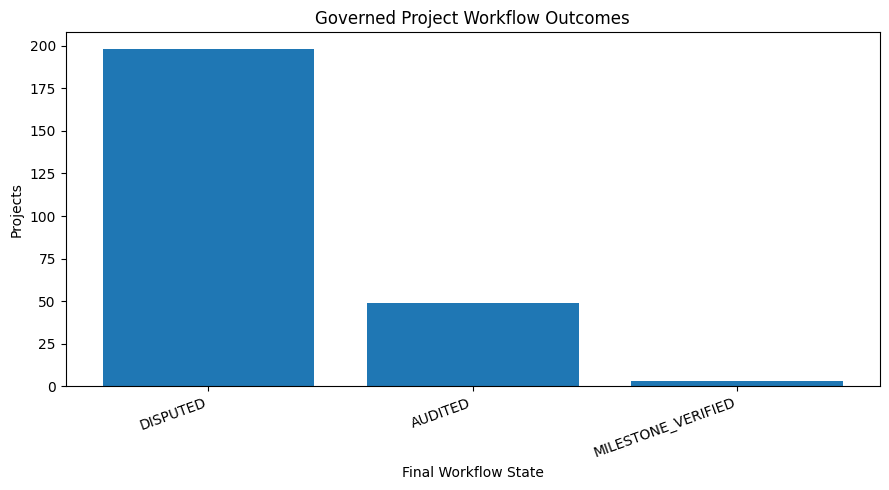

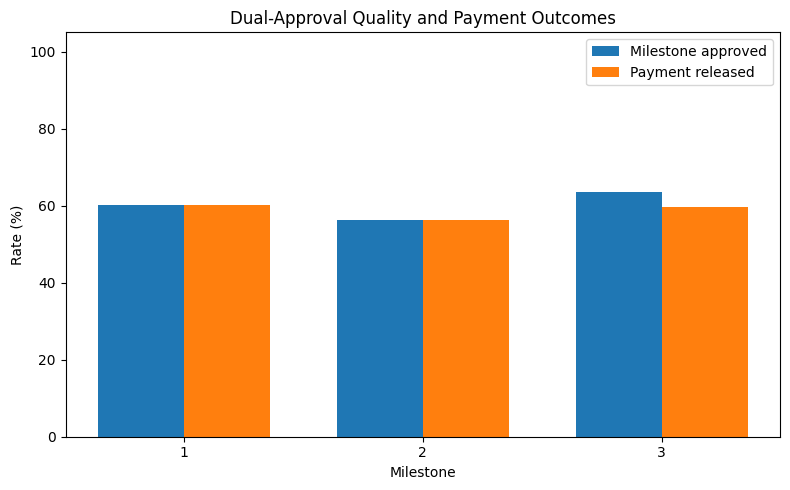

In [34]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 34 — Workflow, Tender, and Quality Graphs
# ═══════════════════════════════════════════════════════════════
workflow_state_counts = (
    project_workflow_summary["Final_State"]
    .value_counts()
    .rename_axis("Final_State")
    .reset_index(name="Projects")
)

plt.figure(figsize=(9, 5))
plt.bar(
    workflow_state_counts["Final_State"],
    workflow_state_counts["Projects"]
)
plt.xlabel("Final Workflow State")
plt.ylabel("Projects")
plt.title("Governed Project Workflow Outcomes")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(
    os.path.join(
        REVIEW_OUTPUT_DIR,
        "Fig_R8_Governed_Workflow_Outcomes.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


if not quality_verification_table.empty:
    milestone_approval_summary = (
        quality_verification_table
        .groupby("Milestone", as_index=False)
        .agg(
            Approval_Rate=(
                "Milestone_Approved",
                lambda values: values.mean() * 100
            ),
            Payment_Release_Rate=(
                "Payment_Released",
                lambda values: values.mean() * 100
            )
        )
    )

    plot_positions = np.arange(
        len(milestone_approval_summary)
    )

    plt.figure(figsize=(8, 5))
    plt.bar(
        plot_positions - 0.18,
        milestone_approval_summary["Approval_Rate"],
        width=0.36,
        label="Milestone approved"
    )
    plt.bar(
        plot_positions + 0.18,
        milestone_approval_summary["Payment_Release_Rate"],
        width=0.36,
        label="Payment released"
    )
    plt.xticks(
        plot_positions,
        milestone_approval_summary["Milestone"]
    )
    plt.xlabel("Milestone")
    plt.ylabel("Rate (%)")
    plt.ylim(0, 105)
    plt.title("Dual-Approval Quality and Payment Outcomes")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            REVIEW_OUTPUT_DIR,
            "Fig_R9_Milestone_Quality_Approval_Rates.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

,Public_Project_ID,Final_State,Allocated_Budget,Total_Paid,Payment_Percent,Tender_Finalized,Public_Audit_Status
0,0f02a5a0bd7d14dbcf0f,DISPUTED,500.80,0.000,0.0,True,PENDING/EXCEPTION
1,bb4c2e0bc155eb14fe65,DISPUTED,189.34,0.000,0.0,True,PENDING/EXCEPTION
2,a04d9ad4895aa95aec5a,DISPUTED,18430.01,7372.004,40.0,True,PENDING/EXCEPTION
3,d875cd146e7e4ccda6d2,DISPUTED,100.62,70.434,70.0,True,PENDING/EXCEPTION
4,a926303a60021c050ad1,AUDITED,80.35,80.350,100.0,True,AUDITED
5,d1cd33831f4d43e5aed2,DISPUTED,34.98,0.000,0.0,True,PENDING/EXCEPTION
6,731d09d7443885553b45,AUDITED,125.94,125.940,100.0,True,AUDITED
7,59fe7d850831b96d2fd8,DISPUTED,511.00,0.000,0.0,False,PENDING/EXCEPTION
8,e152d601f6c5900157a7,DISPUTED,53761.00,21504.400,40.0,True,PENDING/EXCEPTION
9,963f5e4be46f5238fee6,AUDITED,159.03,159.030,100.0,True,AUDITED


,Project_ID,Final_State,Allocated_Budget,Total_Paid,Payment_Percent,Tender_Finalized,Event_Count,Winning_Bidder,Winning_Score,Bid_Commitment_Root
0,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,DISPUTED,500.80,0.000,0.0,True,7,BIDDER-03,94.343917,fb8058720f71b79c1b42212a3e70a466590c785ebf346f...
1,CONT_AWD_47QSSC26F4R1B_4732_47QSHA21A000D_4732,DISPUTED,189.34,0.000,0.0,True,7,BIDDER-01,99.024894,c1c1b31af9354a45b367927199a2e9ac31f13384620b7a...
2,CONT_AWD_SPE30026FXLL8_9700_SPE30025D4004_9700,DISPUTED,18430.01,7372.004,40.0,True,10,BIDDER-02,97.070600,cec6f7ff924bd2186a3ab11f6e8f38720f53275ad770ab...
3,CONT_AWD_47QSSC26F3FRX_4732_47QSHA21A0009_4732,DISPUTED,100.62,70.434,70.0,True,13,BIDDER-02,93.105247,551555ac9e99fbde43b59b9efa636db77795d3ce556591...
4,CONT_AWD_47QSSC26F3QKY_4732_47QSWA22D0009_4732,AUDITED,80.35,80.350,100.0,True,16,BIDDER-01,78.668840,f0115052263f93621b3a5a70a005bf0e1baa17f4c95695...
5,CONT_AWD_47QSSC26F1FYG_4732_47QSEA20A000C_4732,DISPUTED,34.98,0.000,0.0,True,7,BIDDER-03,79.028197,3496f9b5595a04ea8adc2ca399d92197e1cf1b1abd25eb...
6,CONT_AWD_SPE2DM26F2CC8_9700_SPE2DM20D0213_9700,AUDITED,125.94,125.940,100.0,True,16,BIDDER-02,93.307128,aba862f6adf0a9e232523dd6e8f4ae9e1e0cdac2f06b33...
7,CONT_AWD_47QSWA26P0JRL_4732_-NONE-_-NONE-,DISPUTED,511.00,0.000,0.0,False,3,BIDDER-02,67.996328,1d66d639be17dbfd6eecde17014bb45673f21531a1ae7b...
8,CONT_AWD_47QMCA26F06D4_4732_47QMCA22D000N_4732,DISPUTED,53761.00,21504.400,40.0,True,10,BIDDER-01,91.476975,64e09ecb4dd1d76760233a7130d6ac2e1b64d73c2fc7f4...
9,CONT_AWD_SPE2DM26FSGGN_9700_SPE2DM20D6006_9700,AUDITED,159.03,159.030,100.0,True,16,BIDDER-02,86.736118,d7238ff93208e735cb34de4389a9c2568e5a946a8a2c58...


,Field,Storage_or_Disclosure_Method,Classification
0,Project ID,Pseudonymized public identifier,PUBLIC
1,Approved budget,Aggregate value,PUBLIC
2,Aggregate disbursement,Aggregate value,PUBLIC
3,Project status,Lifecycle state,PUBLIC
4,Audit outcome,Summary status,PUBLIC
5,Wallet address,Institutional identity mapping,RESTRICTED
6,Bid document,Encrypted off-chain; hash on-chain,RESTRICTED
7,Bidder identity,Procurement and auditor access,RESTRICTED
8,Inspection evidence,Encrypted off-chain; hash on-chain,RESTRICTED
9,Internal risk score,Auditor and oversight access,RESTRICTED


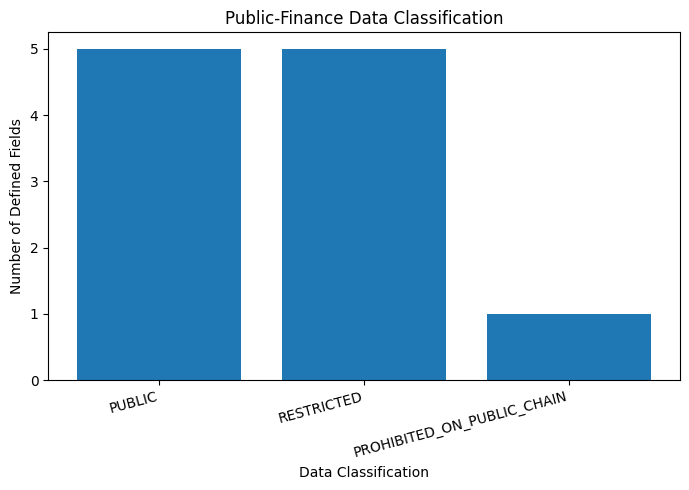

In [35]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 35 — Privacy-Preserving Public and Restricted Views
# Q10: Separate transparency from confidential information
# ═══════════════════════════════════════════════════════════════
PRIVACY_SALT = stable_hash(
    {
        "purpose": "reviewer-public-view",
        "seed": SEED
    }
)


def pseudonymize_identifier(value):
    return stable_hash(
        {
            "salt": PRIVACY_SALT,
            "value": str(value)
        }
    )[:20]


public_privacy_records = []

for _, record in project_workflow_summary.iterrows():
    public_privacy_records.append(
        {
            "Public_Project_ID": pseudonymize_identifier(
                record["Project_ID"]
            ),
            "Final_State": record["Final_State"],
            "Allocated_Budget": record["Allocated_Budget"],
            "Total_Paid": record["Total_Paid"],
            "Payment_Percent": record["Payment_Percent"],
            "Tender_Finalized": record["Tender_Finalized"],
            "Public_Audit_Status": (
                "AUDITED"
                if record["Final_State"] == "AUDITED"
                else "PENDING/EXCEPTION"
            )
        }
    )

public_privacy_portal_table = pd.DataFrame(
    public_privacy_records
)

restricted_auditor_table = (
    project_workflow_summary
    .merge(
        tender_audit_table[
            [
                "Project_ID",
                "Winning_Bidder",
                "Winning_Score",
                "Bid_Commitment_Root"
            ]
        ],
        on="Project_ID",
        how="left"
    )
)

privacy_field_classification_table = pd.DataFrame(
    [
        ("Project ID", "Pseudonymized public identifier", "PUBLIC"),
        ("Approved budget", "Aggregate value", "PUBLIC"),
        ("Aggregate disbursement", "Aggregate value", "PUBLIC"),
        ("Project status", "Lifecycle state", "PUBLIC"),
        ("Audit outcome", "Summary status", "PUBLIC"),
        ("Wallet address", "Institutional identity mapping", "RESTRICTED"),
        ("Bid document", "Encrypted off-chain; hash on-chain", "RESTRICTED"),
        ("Bidder identity", "Procurement and auditor access", "RESTRICTED"),
        ("Inspection evidence", "Encrypted off-chain; hash on-chain", "RESTRICTED"),
        ("Internal risk score", "Auditor and oversight access", "RESTRICTED"),
        ("Personal information", "Not stored on public ledger", "PROHIBITED_ON_PUBLIC_CHAIN")
    ],
    columns=[
        "Field",
        "Storage_or_Disclosure_Method",
        "Classification"
    ]
)

privacy_class_summary = (
    privacy_field_classification_table["Classification"]
    .value_counts()
    .rename_axis("Classification")
    .reset_index(name="Field_Count")
)

display(public_privacy_portal_table.head(10))
display(restricted_auditor_table.head(10))
display(privacy_field_classification_table)

plt.figure(figsize=(7, 5))
plt.bar(
    privacy_class_summary["Classification"],
    privacy_class_summary["Field_Count"]
)
plt.xlabel("Data Classification")
plt.ylabel("Number of Defined Fields")
plt.title("Public-Finance Data Classification")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(
    os.path.join(
        REVIEW_OUTPUT_DIR,
        "Fig_R10_Privacy_Data_Classification.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [36]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 36 — Security Invariants and Attack-Modelling Test Harness
# Q9, Q12, Q13, Q14
# ═══════════════════════════════════════════════════════════════
class SecureGovernedLedger:
    def __init__(self):
        self.actor_roles = {}
        self.active_actors = set()
        self.projects = {}
        self.used_nonces = set()
        self.approved_milestones = set()

    def register_actor(self, actor, role):
        self.actor_roles[str(actor)] = str(role)
        self.active_actors.add(str(actor))

    def revoke_actor(self, actor):
        self.active_actors.discard(str(actor))

    def _authorized(self, actor, required_role):
        return (
            str(actor) in self.active_actors and
            self.actor_roles.get(str(actor)) == required_role
        )

    def create_project(
        self,
        actor,
        project_id,
        budget,
        treasury,
        city,
        builder
    ):
        project_id = str(project_id)

        if not self._authorized(actor, "FINANCE_MINISTRY"):
            return False

        if project_id in self.projects:
            return False

        if float(budget) <= 0:
            return False

        if any(
            str(value).strip() in {"", "0x0", "None"}
            for value in [treasury, city, builder]
        ):
            return False

        self.projects[project_id] = {
            "budget": float(budget),
            "treasury": str(treasury),
            "city": str(city),
            "builder": str(builder),
            "sent_to_city": 0.0,
            "sent_to_builder": 0.0
        }

        return True

    def approve_milestone(self, project_id, milestone):
        key = (str(project_id), int(milestone))
        self.approved_milestones.add(key)

    def release_to_city(
        self,
        actor,
        project_id,
        amount,
        nonce
    ):
        project_id = str(project_id)
        nonce = str(nonce)

        if nonce in self.used_nonces:
            return False

        if project_id not in self.projects:
            return False

        project = self.projects[project_id]

        if not self._authorized(actor, "TREASURY"):
            return False

        if str(actor) != project["treasury"]:
            return False

        amount = float(amount)

        if amount <= 0:
            return False

        if project["sent_to_city"] + amount > project["budget"]:
            return False

        project["sent_to_city"] += amount
        self.used_nonces.add(nonce)

        return True

    def pay_builder(
        self,
        actor,
        project_id,
        milestone,
        amount,
        nonce
    ):
        project_id = str(project_id)
        nonce = str(nonce)

        if nonce in self.used_nonces:
            return False

        if project_id not in self.projects:
            return False

        project = self.projects[project_id]

        if not self._authorized(actor, "CITY_CORPORATION"):
            return False

        if str(actor) != project["city"]:
            return False

        if (
            project_id,
            int(milestone)
        ) not in self.approved_milestones:
            return False

        amount = float(amount)
        available = (
            project["sent_to_city"] -
            project["sent_to_builder"]
        )

        if amount <= 0 or amount > available:
            return False

        project["sent_to_builder"] += amount
        self.used_nonces.add(nonce)

        return True


secure_test_ledger = SecureGovernedLedger()
secure_test_ledger.register_actor("FM-01", "FINANCE_MINISTRY")
secure_test_ledger.register_actor("TR-01", "TREASURY")
secure_test_ledger.register_actor("TR-02", "TREASURY")
secure_test_ledger.register_actor("CC-01", "CITY_CORPORATION")
secure_test_ledger.register_actor("UNAUTH-01", "PUBLIC")

security_test_records = []


def record_security_test(name, expected_blocked, observed_success):
    observed_blocked = not bool(observed_success)

    security_test_records.append(
        {
            "Security_Test": name,
            "Expected": (
                "Blocked"
                if expected_blocked
                else "Accepted"
            ),
            "Observed": (
                "Accepted"
                if observed_success
                else "Blocked"
            ),
            "Pass": (
                observed_blocked
                if expected_blocked
                else bool(observed_success)
            )
        }
    )


valid_create = secure_test_ledger.create_project(
    "FM-01",
    "SEC-PRJ-01",
    1000,
    "TR-01",
    "CC-01",
    "BLD-01"
)
record_security_test(
    "Authorized project creation",
    expected_blocked=False,
    observed_success=valid_create
)

record_security_test(
    "Unauthorized project creation",
    expected_blocked=True,
    observed_success=secure_test_ledger.create_project(
        "UNAUTH-01",
        "SEC-PRJ-02",
        1000,
        "TR-01",
        "CC-01",
        "BLD-01"
    )
)

record_security_test(
    "Duplicate project identifier",
    expected_blocked=True,
    observed_success=secure_test_ledger.create_project(
        "FM-01",
        "SEC-PRJ-01",
        1000,
        "TR-01",
        "CC-01",
        "BLD-01"
    )
)

record_security_test(
    "Cross-project or wrong treasury",
    expected_blocked=True,
    observed_success=secure_test_ledger.release_to_city(
        "TR-02",
        "SEC-PRJ-01",
        100,
        "NONCE-WRONG-TREASURY"
    )
)

record_security_test(
    "Budget overspending",
    expected_blocked=True,
    observed_success=secure_test_ledger.release_to_city(
        "TR-01",
        "SEC-PRJ-01",
        1100,
        "NONCE-OVERSPEND"
    )
)

valid_release = secure_test_ledger.release_to_city(
    "TR-01",
    "SEC-PRJ-01",
    500,
    "NONCE-VALID-01"
)

record_security_test(
    "Authorized installment",
    expected_blocked=False,
    observed_success=valid_release
)

record_security_test(
    "Replay of an already used nonce",
    expected_blocked=True,
    observed_success=secure_test_ledger.release_to_city(
        "TR-01",
        "SEC-PRJ-01",
        100,
        "NONCE-VALID-01"
    )
)

record_security_test(
    "Builder payment before milestone approval",
    expected_blocked=True,
    observed_success=secure_test_ledger.pay_builder(
        "CC-01",
        "SEC-PRJ-01",
        1,
        100,
        "NONCE-PAY-BEFORE-APPROVAL"
    )
)

secure_test_ledger.approve_milestone(
    "SEC-PRJ-01",
    1
)

record_security_test(
    "Builder payment after milestone approval",
    expected_blocked=False,
    observed_success=secure_test_ledger.pay_builder(
        "CC-01",
        "SEC-PRJ-01",
        1,
        100,
        "NONCE-PAY-AFTER-APPROVAL"
    )
)

secure_test_ledger.revoke_actor("TR-01")

record_security_test(
    "Revoked treasury credential",
    expected_blocked=True,
    observed_success=secure_test_ledger.release_to_city(
        "TR-01",
        "SEC-PRJ-01",
        100,
        "NONCE-REVOKED"
    )
)

# Blockchain tampering test using the original lightweight classes.
tamper_test_chain = LightweightDPoSBlockchain(
    transactions_per_block=2,
    delegate_count=5,
    active_delegate_count=3
)

tamper_test_chain.add_transaction(
    LightweightTransaction(
        "createProject",
        "FM",
        "Registry",
        "TAMPER-01",
        100,
        1000
    )
)

tamper_test_chain.add_transaction(
    LightweightTransaction(
        "assignBuilder",
        "FM",
        "Builder",
        "TAMPER-01",
        0,
        500
    )
)

tamper_test_chain.finalize()
tamper_test_chain.chain[1].block_hash = "0" * 64
tamper_valid, _ = tamper_test_chain.validate_chain()

record_security_test(
    "Tampered block hash",
    expected_blocked=True,
    observed_success=tamper_valid
)

security_invariant_results = pd.DataFrame(
    security_test_records
)

attack_model_table = pd.DataFrame(
    [
        ("Unauthorized project creation", "Spoofing/Elevation", "Institutional credential + RBAC", "Unauthorized project creation"),
        ("Cross-project fund release", "Elevation/Tampering", "Project-specific treasury binding", "Cross-project or wrong treasury"),
        ("Budget overspending", "Tampering", "Cumulative budget ceiling", "Budget overspending"),
        ("Replay transaction", "Tampering", "Unique nonce registry", "Replay of an already used nonce"),
        ("Premature builder payment", "Elevation", "Milestone state and dual approval", "Builder payment before milestone approval"),
        ("Compromised credential", "Spoofing", "Revocation and key rotation", "Revoked treasury credential"),
        ("Ledger modification", "Tampering", "Hash linkage and chain validation", "Tampered block hash"),
        ("Tender manipulation", "Tampering/Repudiation", "Bid commitments, auditor approval, challenge period", "Workflow table"),
        ("Construction evidence falsification", "Spoofing/Tampering", "Engineer + auditor evidence hashes", "Quality table"),
        ("Validator collusion", "Tampering/Denial of service", "Threshold governance and collusion monitoring", "Collusion experiment")
    ],
    columns=[
        "Attack_Scenario",
        "STRIDE_Category",
        "Primary_Mitigation",
        "Evidence_Source"
    ]
)

formal_property_table = pd.DataFrame(
    [
        ("P1", "SentToCity(p) <= Budget(p)", "Budget overspending", "Executable Python invariant"),
        ("P2", "SentToBuilder(p) <= SentToCity(p)", "Builder payment after milestone approval", "Executable Python invariant"),
        ("P3", "Unauthorized actor cannot change state", "Unauthorized project creation", "Executable Python invariant"),
        ("P4", "Treasury acts only for its assigned project", "Cross-project or wrong treasury", "Executable Python invariant"),
        ("P5", "A nonce cannot be accepted twice", "Replay of an already used nonce", "Executable Python invariant"),
        ("P6", "Builder payment implies milestone approval", "Builder payment before milestone approval", "Executable Python invariant"),
        ("P7", "Revoked identity cannot execute", "Revoked treasury credential", "Executable Python invariant"),
        ("P8", "Stored block hash equals recomputed block hash", "Tampered block hash", "Executable Python invariant"),
        ("P9", "InstallmentCount(p) <= configured maximum", "Original smart-contract simulation", "Design property"),
        ("P10", "Solidity bytecode satisfies all properties", "External Solidity verifier required", "Not established by Colab")
    ],
    columns=[
        "Property_ID",
        "Property",
        "Evidence_or_Test",
        "Verification_Level"
    ]
)

test_outcome_lookup = (
    security_invariant_results
    .set_index("Security_Test")["Pass"]
    .to_dict()
)

formal_property_table["Observed_Result"] = formal_property_table[
    "Evidence_or_Test"
].map(test_outcome_lookup)

formal_property_table["Observed_Result"] = formal_property_table[
    "Observed_Result"
].fillna("External/Design-level")


solidity_audit_plan_table = pd.DataFrame(
    [
        (
            "Slither",
            "Static analysis",
            "slither contracts/ --print human-summary",
            "Requires Solidity source and external execution"
        ),
        (
            "Mythril",
            "Symbolic vulnerability analysis",
            "myth analyze contracts/ProjectRegistry.sol",
            "Requires Solidity source and external execution"
        ),
        (
            "Echidna",
            "Property-based fuzzing",
            "echidna-test contracts/TestHarness.sol --contract TestHarness",
            "Requires Solidity harness and external execution"
        ),
        (
            "Foundry",
            "Unit, fuzz, and invariant tests",
            "forge test --gas-report -vvv",
            "Requires Solidity source and test suite"
        ),
        (
            "Solidity SMTChecker",
            "Bounded formal-property checking",
            "solc --model-checker-engine all contracts/*.sol",
            "Requires Solidity source and specifications"
        ),
        (
            "Manual review",
            "Access control, upgrade, oracle, privacy, and governance review",
            "Independent auditor checklist",
            "Requires independent smart-contract auditor"
        )
    ],
    columns=[
        "Tool_or_Method",
        "Purpose",
        "Example_Command_or_Procedure",
        "Current_Status"
    ]
)

display(security_invariant_results)
display(attack_model_table)
display(formal_property_table)

,Security_Test,Expected,Observed,Pass
0,Authorized project creation,Accepted,Accepted,True
1,Unauthorized project creation,Blocked,Blocked,True
2,Duplicate project identifier,Blocked,Blocked,True
3,Cross-project or wrong treasury,Blocked,Blocked,True
4,Budget overspending,Blocked,Blocked,True
5,Authorized installment,Accepted,Accepted,True
6,Replay of an already used nonce,Blocked,Blocked,True
7,Builder payment before milestone approval,Blocked,Blocked,True
8,Builder payment after milestone approval,Accepted,Accepted,True
9,Revoked treasury credential,Blocked,Blocked,True


,Attack_Scenario,STRIDE_Category,Primary_Mitigation,Evidence_Source
0,Unauthorized project creation,Spoofing/Elevation,Institutional credential + RBAC,Unauthorized project creation
1,Cross-project fund release,Elevation/Tampering,Project-specific treasury binding,Cross-project or wrong treasury
2,Budget overspending,Tampering,Cumulative budget ceiling,Budget overspending
3,Replay transaction,Tampering,Unique nonce registry,Replay of an already used nonce
4,Premature builder payment,Elevation,Milestone state and dual approval,Builder payment before milestone approval
5,Compromised credential,Spoofing,Revocation and key rotation,Revoked treasury credential
6,Ledger modification,Tampering,Hash linkage and chain validation,Tampered block hash
7,Tender manipulation,Tampering/Repudiation,"Bid commitments, auditor approval, challenge p...",Workflow table
8,Construction evidence falsification,Spoofing/Tampering,Engineer + auditor evidence hashes,Quality table
9,Validator collusion,Tampering/Denial of service,Threshold governance and collusion monitoring,Collusion experiment


,Property_ID,Property,Evidence_or_Test,Verification_Level,Observed_Result
0,P1,SentToCity(p) <= Budget(p),Budget overspending,Executable Python invariant,True
1,P2,SentToBuilder(p) <= SentToCity(p),Builder payment after milestone approval,Executable Python invariant,True
2,P3,Unauthorized actor cannot change state,Unauthorized project creation,Executable Python invariant,True
3,P4,Treasury acts only for its assigned project,Cross-project or wrong treasury,Executable Python invariant,True
4,P5,A nonce cannot be accepted twice,Replay of an already used nonce,Executable Python invariant,True
5,P6,Builder payment implies milestone approval,Builder payment before milestone approval,Executable Python invariant,True
6,P7,Revoked identity cannot execute,Revoked treasury credential,Executable Python invariant,True
7,P8,Stored block hash equals recomputed block hash,Tampered block hash,Executable Python invariant,True
8,P9,InstallmentCount(p) <= configured maximum,Original smart-contract simulation,Design property,External/Design-level
9,P10,Solidity bytecode satisfies all properties,External Solidity verifier required,Not established by Colab,External/Design-level


In [37]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 37 — Thread-Safe Large-Scale Concurrency Test
# Q3: Concurrent clients, percentile latency, failure, memory
# ═══════════════════════════════════════════════════════════════
class ThreadSafeLightweightDPoSBlockchain(
    LightweightDPoSBlockchain
):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._transaction_lock = threading.RLock()

    def add_transaction(self, transaction):
        submission_start = time.perf_counter()

        with self._transaction_lock:
            self.pending_transactions.append(transaction)

            if (
                len(self.pending_transactions) >=
                self.transactions_per_block
            ):
                super().generate_block()

        submission_latency = (
            time.perf_counter() - submission_start
        )

        self.transaction_submission_latencies.append(
            submission_latency
        )

        return submission_latency


def create_load_test_transactions(
    number_of_transactions,
    agency_count=5
):
    transactions = []

    for transaction_number in range(number_of_transactions):
        source_row = blockchain_data.iloc[
            transaction_number % len(blockchain_data)
        ]

        agency_id = (
            f"AGENCY-{transaction_number % agency_count + 1:02d}"
        )

        transactions.append(
            LightweightTransaction(
                function_name="concurrentFundEvent",
                sender=agency_id,
                receiver="GOVERNMENT-LEDGER",
                project_id=source_row["Project_ID"],
                amount=float(source_row["Transaction_Amount"]),
                gas_used=75_000
            )
        )

    return transactions


def run_concurrency_scenario(
    concurrent_clients,
    transaction_count,
    agency_count=5
):
    scenario_chain = ThreadSafeLightweightDPoSBlockchain(
        transactions_per_block=20,
        delegate_count=7,
        active_delegate_count=5
    )

    transactions = create_load_test_transactions(
        transaction_count,
        agency_count=agency_count
    )

    failures = 0
    tracemalloc.start()
    scenario_start = time.perf_counter()

    try:
        with ThreadPoolExecutor(
            max_workers=concurrent_clients
        ) as executor:
            latencies = list(
                executor.map(
                    scenario_chain.add_transaction,
                    transactions
                )
            )
    except Exception:
        failures = transaction_count
        latencies = []

    scenario_chain.finalize()

    elapsed_time = time.perf_counter() - scenario_start
    current_memory, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    chain_valid_result, validation_time = (
        scenario_chain.validate_chain()
    )

    latency_array = np.asarray(
        latencies,
        dtype=float
    )

    return {
        "Concurrent_Clients": concurrent_clients,
        "Agency_Count": agency_count,
        "Submitted_Transactions": transaction_count,
        "Confirmed_Transactions": (
            scenario_chain.confirmed_transaction_count
        ),
        "Blocks": len(scenario_chain.chain) - 1,
        "Elapsed_Time_s": elapsed_time,
        "Throughput_TPS": (
            scenario_chain.confirmed_transaction_count /
            elapsed_time
            if elapsed_time > 0 else 0
        ),
        "Mean_Submission_Latency_ms": (
            latency_array.mean() * 1000
            if latency_array.size else np.nan
        ),
        "P50_Submission_Latency_ms": (
            np.percentile(latency_array, 50) * 1000
            if latency_array.size else np.nan
        ),
        "P95_Submission_Latency_ms": (
            np.percentile(latency_array, 95) * 1000
            if latency_array.size else np.nan
        ),
        "P99_Submission_Latency_ms": (
            np.percentile(latency_array, 99) * 1000
            if latency_array.size else np.nan
        ),
        "Failure_Count": failures,
        "Failure_Rate_Percent": (
            failures / transaction_count * 100
            if transaction_count > 0 else 0
        ),
        "Peak_Memory_MB": peak_memory / (1024 ** 2),
        "Chain_Validation_Time_s": validation_time,
        "Chain_Valid": chain_valid_result,
        "Measurement_Scope": (
            "Thread-safe in-memory Python DPoS simulation; "
            "not Ethereum network throughput"
        )
    }


concurrency_records = []

for client_count in CONCURRENCY_LEVELS:
    print(
        f"Running concurrency scenario: "
        f"{client_count} clients"
    )

    concurrency_records.append(
        run_concurrency_scenario(
            concurrent_clients=client_count,
            transaction_count=LOAD_TEST_TRANSACTION_COUNT,
            agency_count=5
        )
    )

concurrency_results = pd.DataFrame(
    concurrency_records
)

display(concurrency_results)

Running concurrency scenario: 1 clients
Running concurrency scenario: 5 clients
Running concurrency scenario: 10 clients
Running concurrency scenario: 25 clients
Running concurrency scenario: 50 clients
Running concurrency scenario: 100 clients


,Concurrent_Clients,Agency_Count,Submitted_Transactions,Confirmed_Transactions,Blocks,Elapsed_Time_s,Throughput_TPS,Mean_Submission_Latency_ms,P50_Submission_Latency_ms,P95_Submission_Latency_ms,P99_Submission_Latency_ms,Failure_Count,Failure_Rate_Percent,Peak_Memory_MB,Chain_Validation_Time_s,Chain_Valid,Measurement_Scope
0,1,5,2000,2000,100,0.190124,10519.451404,0.014463,0.002031,0.048984,0.290290,0,0.0,3.489672,0.001729,True,Thread-safe in-memory Python DPoS simulation; ...
1,5,5,2000,2000,100,0.577958,3460.457340,0.013809,0.001989,0.043230,0.288622,0,0.0,3.508318,0.001206,True,Thread-safe in-memory Python DPoS simulation; ...
2,10,5,2000,2000,100,0.240622,8311.802924,0.014985,0.002034,0.188667,0.316305,0,0.0,3.531346,0.001277,True,Thread-safe in-memory Python DPoS simulation; ...
3,25,5,2000,2000,100,0.227885,8776.359500,0.239411,0.002047,0.296440,5.472003,0,0.0,3.584775,0.001213,True,Thread-safe in-memory Python DPoS simulation; ...
4,50,5,2000,2000,100,0.270492,7393.942299,0.015315,0.002024,0.092121,0.311414,0,0.0,3.653760,0.001374,True,Thread-safe in-memory Python DPoS simulation; ...
5,100,5,2000,2000,100,0.283889,7044.997672,0.015187,0.002057,0.056747,0.312713,0,0.0,3.828856,0.001252,True,Thread-safe in-memory Python DPoS simulation; ...


In [38]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 38 — Multi-Agency Scalability Test
# Q2: Simulated agency-count scaling
# ═══════════════════════════════════════════════════════════════
agency_scalability_records = []

for agency_count in AGENCY_SCENARIOS:
    print(
        f"Running multi-agency scenario: "
        f"{agency_count} agencies"
    )

    scenario_result = run_concurrency_scenario(
        concurrent_clients=min(25, agency_count * 2),
        transaction_count=LOAD_TEST_TRANSACTION_COUNT,
        agency_count=agency_count
    )

    scenario_result["Deployment_Level"] = (
        "Simulated independent agency identities "
        "within one Colab runtime"
    )

    agency_scalability_records.append(
        scenario_result
    )

agency_scalability_results = pd.DataFrame(
    agency_scalability_records
)

display(agency_scalability_results)

Running multi-agency scenario: 3 agencies
Running multi-agency scenario: 5 agencies
Running multi-agency scenario: 10 agencies
Running multi-agency scenario: 20 agencies


,Concurrent_Clients,Agency_Count,Submitted_Transactions,Confirmed_Transactions,Blocks,Elapsed_Time_s,Throughput_TPS,Mean_Submission_Latency_ms,P50_Submission_Latency_ms,P95_Submission_Latency_ms,P99_Submission_Latency_ms,Failure_Count,Failure_Rate_Percent,Peak_Memory_MB,Chain_Validation_Time_s,Chain_Valid,Measurement_Scope,Deployment_Level
0,6,3,2000,2000,100,0.191244,10457.830649,0.013499,0.001980,0.090189,0.241995,0,0.0,3.506760,0.001180,True,Thread-safe in-memory Python DPoS simulation; ...,Simulated independent agency identities within...
1,10,5,2000,2000,100,0.252625,7916.876847,0.015333,0.002101,0.034162,0.306224,0,0.0,3.528710,0.001267,True,Thread-safe in-memory Python DPoS simulation; ...,Simulated independent agency identities within...
2,20,10,2000,2000,100,0.469901,4256.217972,0.014076,0.002226,0.039766,0.257885,0,0.0,3.571423,0.001209,True,Thread-safe in-memory Python DPoS simulation; ...,Simulated independent agency identities within...
3,25,20,2000,2000,100,0.199885,10005.742846,0.013467,0.001988,0.038540,0.234435,0,0.0,3.566837,0.001249,True,Thread-safe in-memory Python DPoS simulation; ...,Simulated independent agency identities within...


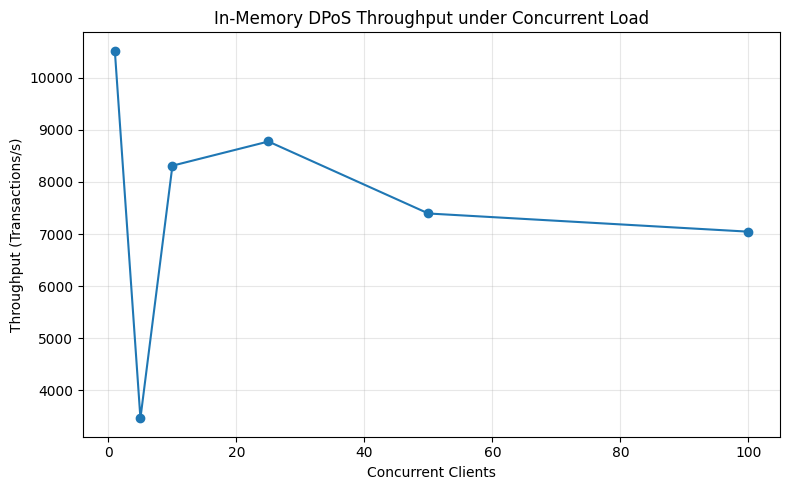

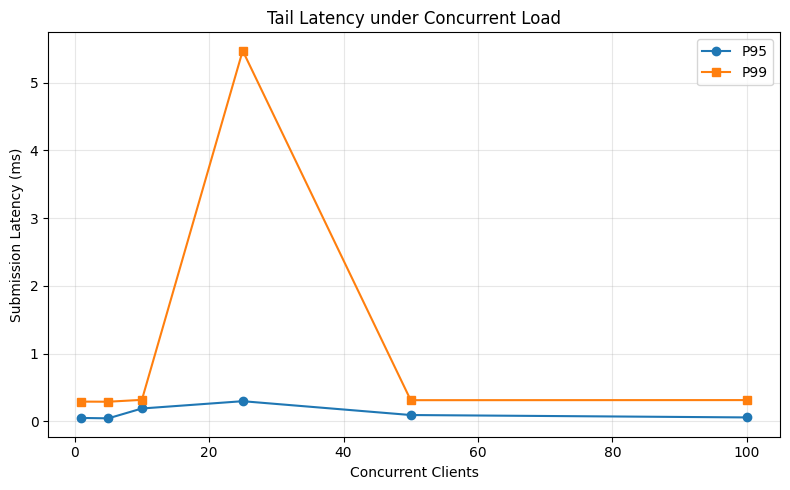

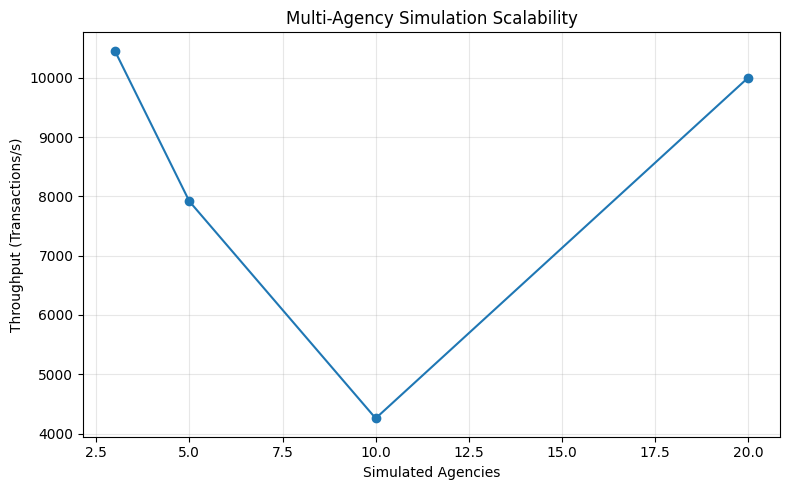

In [39]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 39 — Concurrency and Multi-Agency Graphs
# ═══════════════════════════════════════════════════════════════
plt.figure(figsize=(8, 5))
plt.plot(
    concurrency_results["Concurrent_Clients"],
    concurrency_results["Throughput_TPS"],
    marker="o"
)
plt.xlabel("Concurrent Clients")
plt.ylabel("Throughput (Transactions/s)")
plt.title("In-Memory DPoS Throughput under Concurrent Load")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(
        REVIEW_OUTPUT_DIR,
        "Fig_R11_Concurrency_Throughput.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(
    concurrency_results["Concurrent_Clients"],
    concurrency_results["P95_Submission_Latency_ms"],
    marker="o",
    label="P95"
)
plt.plot(
    concurrency_results["Concurrent_Clients"],
    concurrency_results["P99_Submission_Latency_ms"],
    marker="s",
    label="P99"
)
plt.xlabel("Concurrent Clients")
plt.ylabel("Submission Latency (ms)")
plt.title("Tail Latency under Concurrent Load")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(
        REVIEW_OUTPUT_DIR,
        "Fig_R12_Concurrency_Tail_Latency.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(
    agency_scalability_results["Agency_Count"],
    agency_scalability_results["Throughput_TPS"],
    marker="o"
)
plt.xlabel("Simulated Agencies")
plt.ylabel("Throughput (Transactions/s)")
plt.title("Multi-Agency Simulation Scalability")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(
        REVIEW_OUTPUT_DIR,
        "Fig_R13_Multi_Agency_Scalability.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

,Configured_Malicious_Ratio,Total_Delegates,Active_Delegates,Malicious_Delegates,Active_Malicious_Delegates,Active_Malicious_Percent,Invalid_Attempts,Invalid_Acceptances,Invalid_Acceptance_Rate_Percent,Honest_Confirmation_Rate_Percent,Denied_Service_Rate_Percent,Committee_Size,Approval_Threshold,Residual_Risk
0,0.00,21,15,0,0,0.000000,0,0,0.000000,100.00,0.00,5,4,Low in this scenario
1,0.10,21,15,2,1,6.666667,139,0,0.000000,93.05,6.95,5,4,Availability degradation
2,0.20,21,15,4,2,13.333333,240,0,0.000000,88.00,12.00,5,4,Availability degradation
3,0.33,21,15,7,7,46.666667,931,108,11.600430,53.45,41.15,5,4,Critical
4,0.50,21,15,10,8,53.333333,1052,164,15.589354,47.40,44.40,5,4,Critical
5,0.67,21,15,14,9,60.000000,1209,352,29.114971,39.55,42.85,5,4,Critical


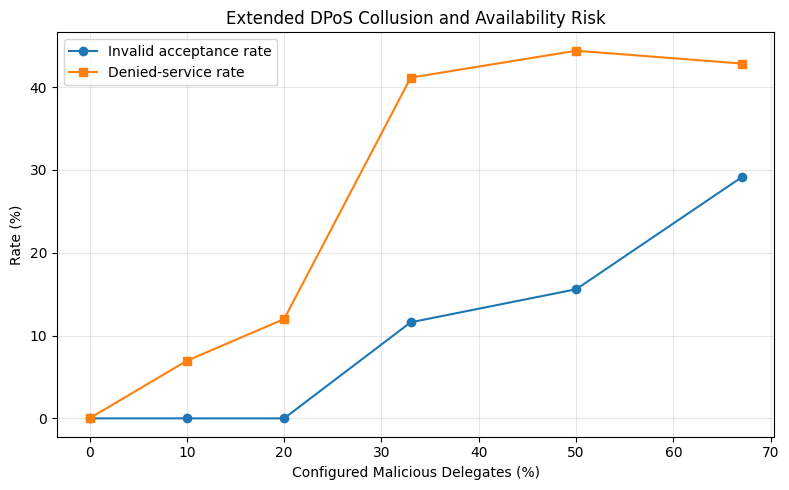

In [40]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 40 — Malicious Delegate and Collusion Simulation
# Q9: Collusion among authorized actors and validators
# ═══════════════════════════════════════════════════════════════
def simulate_delegate_collusion(
    malicious_ratio,
    delegate_count=21,
    active_delegate_count=15,
    committee_size=5,
    rounds=2000
):
    local_rng = np.random.default_rng(
        SEED + int(malicious_ratio * 1000)
    )

    delegate_ids = np.arange(delegate_count)

    malicious_count = int(
        round(delegate_count * malicious_ratio)
    )

    malicious_delegates = set(
        local_rng.choice(
            delegate_ids,
            size=malicious_count,
            replace=False
        ).tolist()
    ) if malicious_count > 0 else set()

    # Active delegates are selected by simulated governance score.
    scores = local_rng.uniform(0, 1, size=delegate_count)
    active_delegates = delegate_ids[
        np.argsort(scores)[::-1][:active_delegate_count]
    ]

    invalid_attempts = 0
    invalid_acceptances = 0
    confirmed_honest_rounds = 0
    denied_service_rounds = 0

    approval_threshold = math.ceil(
        committee_size * 2 / 3
    )

    for _ in range(rounds):
        committee = local_rng.choice(
            active_delegates,
            size=min(committee_size, len(active_delegates)),
            replace=False
        )

        malicious_committee_members = sum(
            int(member in malicious_delegates)
            for member in committee
        )

        producer = int(
            local_rng.choice(active_delegates)
        )

        if producer in malicious_delegates:
            invalid_attempts += 1

            if (
                malicious_committee_members >=
                approval_threshold
            ):
                invalid_acceptances += 1
            else:
                denied_service_rounds += 1
        else:
            confirmed_honest_rounds += 1

    active_malicious_count = sum(
        int(delegate in malicious_delegates)
        for delegate in active_delegates
    )

    return {
        "Configured_Malicious_Ratio": malicious_ratio,
        "Total_Delegates": delegate_count,
        "Active_Delegates": active_delegate_count,
        "Malicious_Delegates": malicious_count,
        "Active_Malicious_Delegates": active_malicious_count,
        "Active_Malicious_Percent": (
            active_malicious_count /
            active_delegate_count * 100
        ),
        "Invalid_Attempts": invalid_attempts,
        "Invalid_Acceptances": invalid_acceptances,
        "Invalid_Acceptance_Rate_Percent": (
            invalid_acceptances /
            invalid_attempts * 100
            if invalid_attempts > 0 else 0
        ),
        "Honest_Confirmation_Rate_Percent": (
            confirmed_honest_rounds /
            rounds * 100
        ),
        "Denied_Service_Rate_Percent": (
            denied_service_rounds /
            rounds * 100
        ),
        "Committee_Size": committee_size,
        "Approval_Threshold": approval_threshold,
        "Residual_Risk": (
            "Critical"
            if invalid_acceptances > 0
            else (
                "Availability degradation"
                if denied_service_rounds > 0
                else "Low in this scenario"
            )
        )
    }


collusion_results = pd.DataFrame(
    [
        simulate_delegate_collusion(ratio)
        for ratio in COLLUSION_RATIOS
    ]
)

display(collusion_results)

plt.figure(figsize=(8, 5))
plt.plot(
    collusion_results["Configured_Malicious_Ratio"] * 100,
    collusion_results["Invalid_Acceptance_Rate_Percent"],
    marker="o",
    label="Invalid acceptance rate"
)
plt.plot(
    collusion_results["Configured_Malicious_Ratio"] * 100,
    collusion_results["Denied_Service_Rate_Percent"],
    marker="s",
    label="Denied-service rate"
)
plt.xlabel("Configured Malicious Delegates (%)")
plt.ylabel("Rate (%)")
plt.title("Extended DPoS Collusion and Availability Risk")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(
        REVIEW_OUTPUT_DIR,
        "Fig_R14_DPoS_Collusion_Risk.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [41]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 41 — Compliance and Responsibility-Tracing Matrix
# Q11: Legal/compliance analysis without claiming certification
# ═══════════════════════════════════════════════════════════════
compliance_matrix_table = pd.DataFrame(
    [
        (
            "Public procurement",
            "Tender publication, immutable result, challenge period",
            "Tender audit table and commitment hashes",
            "Implemented in simulation",
            "Jurisdiction-specific procurement review required"
        ),
        (
            "Budget authorization",
            "Budget ceiling and separation of duties",
            "Security invariants and approval matrix",
            "Implemented in simulation",
            "Government chart-of-accounts integration required"
        ),
        (
            "Records retention",
            "Timestamped, versioned, tamper-evident records",
            "Responsibility trace and block hashes",
            "Partially addressed",
            "Retention schedule and archival authority required"
        ),
        (
            "Identity and electronic signatures",
            "Credentialed institutional actors",
            "Identity registry and key events",
            "Simulated only",
            "Government PKI/e-ID and signature-law validation required"
        ),
        (
            "Data protection",
            "Minimal public data and restricted evidence",
            "Privacy classification and separate portal views",
            "Partially addressed",
            "Privacy impact assessment required"
        ),
        (
            "Financial audit",
            "Complete actor/action/evidence trace",
            "Responsibility trace table",
            "Implemented in simulation",
            "Auditor stakeholder validation required"
        ),
        (
            "Construction assurance",
            "Independent milestone evidence and approval",
            "Quality verification table",
            "Simulated only",
            "Physical inspection, laboratories, and trusted oracles required"
        ),
        (
            "Dispute resolution",
            "Tender challenge and milestone dispute states",
            "Workflow state machine",
            "Implemented in simulation",
            "Administrative appeal procedure required"
        ),
        (
            "Key compromise response",
            "Rotation, revocation, and recovery event logging",
            "Key-management event table",
            "Implemented in simulation",
            "HSM and institutional incident-response validation required"
        ),
        (
            "Legal responsibility",
            "Trace actor, role, evidence, policy, and timestamp",
            "Responsibility trace table",
            "Partially addressed",
            "Court/evidentiary admissibility review required"
        )
    ],
    columns=[
        "Compliance_Domain",
        "Control_Objective",
        "Implementation_Evidence",
        "Current_Status",
        "Residual_Requirement"
    ]
)

responsibility_trace_schema_table = pd.DataFrame(
    [
        ("Action_ID", "Unique event identifier"),
        ("Project_ID", "Associated award/project"),
        ("Actor_Organization", "Institution that initiated the action"),
        ("Actor_Role", "Authorized responsibility"),
        ("Credential_ID", "Identity credential reference"),
        ("Action_Type", "Tender, approval, transfer, inspection, or audit"),
        ("Timestamp", "Time of action"),
        ("Policy_Version", "Applicable workflow/approval policy"),
        ("Evidence_Hash", "Integrity reference for off-chain evidence"),
        ("Previous_Action_ID", "Causal trace to prior action"),
        ("Required_Approvals", "Governance threshold"),
        ("Actual_Approvals", "Approvals supplied"),
        ("Transaction_ID", "Ledger transaction reference")
    ],
    columns=[
        "Responsibility_Field",
        "Purpose"
    ]
)


stakeholder_validation_protocol_table = pd.DataFrame(
    [
        (
            "Finance official",
            "Create and revise project budget",
            "Task completion, errors, approval fit, perceived control"
        ),
        (
            "Treasury official",
            "Release authorized installments",
            "Completion time, policy fit, exception handling"
        ),
        (
            "Procurement officer",
            "Open, evaluate, challenge, and finalize tender",
            "Workflow completeness and confidentiality"
        ),
        (
            "Government engineer",
            "Submit inspection and milestone decision",
            "Evidence usability and quality-control fit"
        ),
        (
            "Independent auditor",
            "Trace actors, documents, approvals, and payments",
            "Audit completeness and anomaly-detection usefulness"
        ),
        (
            "Contractor/builder",
            "Submit bid and milestone evidence",
            "Usability, clarity, and administrative burden"
        ),
        (
            "Citizen/journalist",
            "Find project status and fund flow",
            "Search success, comprehension, accessibility"
        )
    ],
    columns=[
        "Stakeholder_Role",
        "Validation_Task",
        "Recommended_Measures"
    ]
)

display(compliance_matrix_table)
display(responsibility_trace_schema_table)
display(responsibility_trace_table.head(15))

,Compliance_Domain,Control_Objective,Implementation_Evidence,Current_Status,Residual_Requirement
0,Public procurement,"Tender publication, immutable result, challeng...",Tender audit table and commitment hashes,Implemented in simulation,Jurisdiction-specific procurement review required
1,Budget authorization,Budget ceiling and separation of duties,Security invariants and approval matrix,Implemented in simulation,Government chart-of-accounts integration required
2,Records retention,"Timestamped, versioned, tamper-evident records",Responsibility trace and block hashes,Partially addressed,Retention schedule and archival authority requ...
3,Identity and electronic signatures,Credentialed institutional actors,Identity registry and key events,Simulated only,Government PKI/e-ID and signature-law validati...
4,Data protection,Minimal public data and restricted evidence,Privacy classification and separate portal views,Partially addressed,Privacy impact assessment required
5,Financial audit,Complete actor/action/evidence trace,Responsibility trace table,Implemented in simulation,Auditor stakeholder validation required
6,Construction assurance,Independent milestone evidence and approval,Quality verification table,Simulated only,"Physical inspection, laboratories, and trusted..."
7,Dispute resolution,Tender challenge and milestone dispute states,Workflow state machine,Implemented in simulation,Administrative appeal procedure required
8,Key compromise response,"Rotation, revocation, and recovery event logging",Key-management event table,Implemented in simulation,HSM and institutional incident-response valida...
9,Legal responsibility,"Trace actor, role, evidence, policy, and times...",Responsibility trace table,Partially addressed,Court/evidentiary admissibility review required


,Responsibility_Field,Purpose
0,Action_ID,Unique event identifier
1,Project_ID,Associated award/project
2,Actor_Organization,Institution that initiated the action
3,Actor_Role,Authorized responsibility
4,Credential_ID,Identity credential reference
5,Action_Type,"Tender, approval, transfer, inspection, or audit"
6,Timestamp,Time of action
7,Policy_Version,Applicable workflow/approval policy
8,Evidence_Hash,Integrity reference for off-chain evidence
9,Previous_Action_ID,Causal trace to prior action


,Project_ID,Previous_State,New_State,Actor_Role,Evidence_Hash,Timestamp
0,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,DRAFT,BUDGET_APPROVED,FINANCE_MINISTRY + OVERSIGHT,195136fdb52671a783aa7bbcd9c24e0718c000609ef640...,1.784431e+09
1,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,BUDGET_APPROVED,TENDER_OPEN,PROCUREMENT,8e1a229d74c199c7d494d6eca8a3f36bf179c4cb6d0259...,1.784431e+09
2,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,TENDER_OPEN,TENDER_CLOSED,PROCUREMENT,fb8058720f71b79c1b42212a3e70a466590c785ebf346f...,1.784431e+09
3,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,TENDER_CLOSED,CONTRACT_AWARDED,PROCUREMENT + AUDITOR,a4215b57304780db97dad3fc9f2d35256edca3c0c1fe30...,1.784431e+09
4,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,CONTRACT_AWARDED,WORK_STARTED,BUILDER,None,1.784431e+09
5,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,WORK_STARTED,MILESTONE_SUBMITTED,BUILDER,f0118dc75ea4c46eac0db3938a835b4b1d1f45ca749f78...,1.784431e+09
6,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,MILESTONE_SUBMITTED,DISPUTED,ENGINEER + AUDITOR,06f14ee45839e8ca972605ca5b0bb37113789065ddd42b...,1.784431e+09
7,CONT_AWD_47QSSC26F4R1B_4732_47QSHA21A000D_4732,DRAFT,BUDGET_APPROVED,FINANCE_MINISTRY + OVERSIGHT,074a0b522b85d0be5b7587420f7deb6cd92706b08a2c88...,1.784431e+09
8,CONT_AWD_47QSSC26F4R1B_4732_47QSHA21A000D_4732,BUDGET_APPROVED,TENDER_OPEN,PROCUREMENT,bd790e95771ea44e52267b22a4b661150d74ef226aa26d...,1.784431e+09
9,CONT_AWD_47QSSC26F4R1B_4732_47QSHA21A000D_4732,TENDER_OPEN,TENDER_CLOSED,PROCUREMENT,c1c1b31af9354a45b367927199a2e9ac31f13384620b7a...,1.784431e+09


In [42]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 42 — Same-Workload Architecture Benchmark
# Q15: Centralized, original DPoS, and governed DPoS comparison
# ═══════════════════════════════════════════════════════════════
class CentralizedLedgerBaseline:
    def __init__(self):
        self.records = []
        self._lock = threading.Lock()

    def add(self, transaction):
        start = time.perf_counter()

        with self._lock:
            self.records.append(
                transaction.to_dict()
            )

        return time.perf_counter() - start


class GovernedDPoSLedger:
    def __init__(self):
        self.blockchain = (
            ThreadSafeLightweightDPoSBlockchain(
                transactions_per_block=20,
                delegate_count=7,
                active_delegate_count=5
            )
        )
        self.active_agencies = {
            f"AGENCY-{index:02d}"
            for index in range(1, 21)
        }
        self.used_transaction_ids = set()
        self._lock = threading.RLock()

    def add(self, transaction):
        start = time.perf_counter()

        with self._lock:
            if transaction.sender not in self.active_agencies:
                return None

            if transaction.transaction_id in self.used_transaction_ids:
                return None

            if transaction.amount < 0:
                return None

            self.used_transaction_ids.add(
                transaction.transaction_id
            )

            self.blockchain.add_transaction(
                transaction
            )

        return time.perf_counter() - start

    def finalize(self):
        self.blockchain.finalize()


ARCHITECTURE_BENCHMARK_TRANSACTIONS = min(
    3000,
    LOAD_TEST_TRANSACTION_COUNT
)

architecture_transactions = create_load_test_transactions(
    ARCHITECTURE_BENCHMARK_TRANSACTIONS,
    agency_count=20
)


def benchmark_processor(
    architecture_name,
    add_function,
    finalize_function=None,
    workers=25
):
    start = time.perf_counter()

    with ThreadPoolExecutor(
        max_workers=workers
    ) as executor:
        latency_results = list(
            executor.map(
                add_function,
                architecture_transactions
            )
        )

    if finalize_function is not None:
        finalize_function()

    elapsed = time.perf_counter() - start

    valid_latencies = np.asarray(
        [
            latency
            for latency in latency_results
            if latency is not None
        ],
        dtype=float
    )

    accepted = len(valid_latencies)

    return {
        "Architecture": architecture_name,
        "Submitted_Transactions": len(
            architecture_transactions
        ),
        "Accepted_Transactions": accepted,
        "Rejected_Transactions": (
            len(architecture_transactions) -
            accepted
        ),
        "Elapsed_Time_s": elapsed,
        "Throughput_TPS": (
            accepted / elapsed
            if elapsed > 0 else 0
        ),
        "Mean_Latency_ms": (
            valid_latencies.mean() * 1000
            if valid_latencies.size else np.nan
        ),
        "P95_Latency_ms": (
            np.percentile(valid_latencies, 95) * 1000
            if valid_latencies.size else np.nan
        )
    }


centralized_baseline = CentralizedLedgerBaseline()

original_benchmark_chain = (
    ThreadSafeLightweightDPoSBlockchain(
        transactions_per_block=20,
        delegate_count=7,
        active_delegate_count=5
    )
)

governed_benchmark_ledger = GovernedDPoSLedger()

architecture_performance_table = pd.DataFrame(
    [
        benchmark_processor(
            "Centralized in-memory ledger",
            centralized_baseline.add
        ),
        benchmark_processor(
            "Original lightweight DPoS",
            original_benchmark_chain.add_transaction,
            original_benchmark_chain.finalize
        ),
        benchmark_processor(
            "Governance-enhanced lightweight DPoS",
            governed_benchmark_ledger.add,
            governed_benchmark_ledger.finalize
        )
    ]
)

architecture_feature_comparison = pd.DataFrame(
    [
        (
            "Centralized in-memory ledger",
            "No",
            "Application-level",
            "No",
            "No",
            "No",
            "No",
            "Baseline only"
        ),
        (
            "Original lightweight DPoS",
            "Yes",
            "Basic simulated roles",
            "Public aggregate",
            "No",
            "No",
            "No",
            "Original pipeline"
        ),
        (
            "Governance-enhanced lightweight DPoS",
            "Yes",
            "Institutional credential + project binding",
            "Public/restricted separation",
            "Committee audit record",
            "Engineer + auditor approval",
            "Multisignature policy",
            "Supplementary simulation"
        )
    ],
    columns=[
        "Architecture",
        "Tamper_Evident_Ledger",
        "Identity_and_Access",
        "Privacy_Model",
        "Tender_Governance",
        "Quality_Verification",
        "Collusion_Control",
        "Evidence_Level"
    ]
)

# Expanded table based on systems already discussed in the manuscript.
# NR = not reported in the compared publication/table.
existing_system_comparison_table = pd.DataFrame(
    [
        ("Mohite et al.", "Yes", "Yes", "No", "No", "NR", "NR", "NR", "NR", "No"),
        ("Alotaibi et al. (continuous audit)", "Yes", "Yes", "No", "No", "NR", "NR", "NR", "NR", "No"),
        ("Goswami et al.", "Yes", "Yes", "No", "No", "Tender-focused", "NR", "NR", "Citizen participation", "No"),
        ("Rashid et al.", "Yes", "Yes", "Yes", "Yes", "NR", "NR", "NR", "NR", "Yes"),
        ("Ranjan et al.", "Yes", "Yes", "No", "No", "NR", "NR", "NR", "Citizen involvement", "No"),
        ("Alotaibi et al. (government records)", "Yes", "Yes", "Yes", "Yes", "NR", "NR", "NR", "Citizen involvement", "Yes"),
        (
            "Original proposed framework",
            "Yes",
            "Yes",
            "Yes",
            "Yes",
            "Off-chain result only",
            "No",
            "Basic RBAC",
            "Public portal",
            "Yes"
        ),
        (
            "Reviewer-strengthened simulation",
            "Yes",
            "Yes",
            "Yes",
            "Yes",
            "Commitment + committee audit",
            "Milestone dual approval",
            "Identity, key, multisignature, collusion tests",
            "Privacy-separated portal",
            "Yes"
        )
    ],
    columns=[
        "System",
        "Traceability",
        "Fund_Transparency",
        "Smart_Contracts",
        "Implementation",
        "Tendering",
        "Construction_Quality",
        "Security_and_Governance",
        "Citizen_or_Public_Access",
        "Result_Analysis"
    ]
)

display(architecture_performance_table)
display(architecture_feature_comparison)
display(existing_system_comparison_table)

,Architecture,Submitted_Transactions,Accepted_Transactions,Rejected_Transactions,Elapsed_Time_s,Throughput_TPS,Mean_Latency_ms,P95_Latency_ms
0,Centralized in-memory ledger,2000,2000,0,0.050256,39795.908276,0.001451,0.001986
1,Original lightweight DPoS,2000,2000,0,0.049257,40603.727897,0.002881,0.032429
2,Governance-enhanced lightweight DPoS,2000,2000,0,0.047190,42382.205441,0.004037,0.033784


,Architecture,Tamper_Evident_Ledger,Identity_and_Access,Privacy_Model,Tender_Governance,Quality_Verification,Collusion_Control,Evidence_Level
0,Centralized in-memory ledger,No,Application-level,No,No,No,No,Baseline only
1,Original lightweight DPoS,Yes,Basic simulated roles,Public aggregate,No,No,No,Original pipeline
2,Governance-enhanced lightweight DPoS,Yes,Institutional credential + project binding,Public/restricted separation,Committee audit record,Engineer + auditor approval,Multisignature policy,Supplementary simulation


,System,Traceability,Fund_Transparency,Smart_Contracts,Implementation,Tendering,Construction_Quality,Security_and_Governance,Citizen_or_Public_Access,Result_Analysis
0,Mohite et al.,Yes,Yes,No,No,NR,NR,NR,NR,No
1,Alotaibi et al. (continuous audit),Yes,Yes,No,No,NR,NR,NR,NR,No
2,Goswami et al.,Yes,Yes,No,No,Tender-focused,NR,NR,Citizen participation,No
3,Rashid et al.,Yes,Yes,Yes,Yes,NR,NR,NR,NR,Yes
4,Ranjan et al.,Yes,Yes,No,No,NR,NR,NR,Citizen involvement,No
5,Alotaibi et al. (government records),Yes,Yes,Yes,Yes,NR,NR,NR,Citizen involvement,Yes
6,Original proposed framework,Yes,Yes,Yes,Yes,Off-chain result only,No,Basic RBAC,Public portal,Yes
7,Reviewer-strengthened simulation,Yes,Yes,Yes,Yes,Commitment + committee audit,Milestone dual approval,"Identity, key, multisignature, collusion tests",Privacy-separated portal,Yes


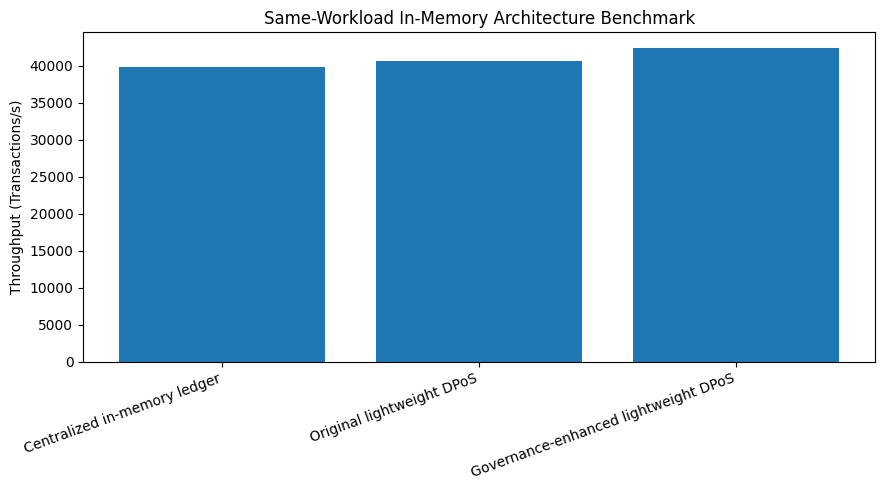

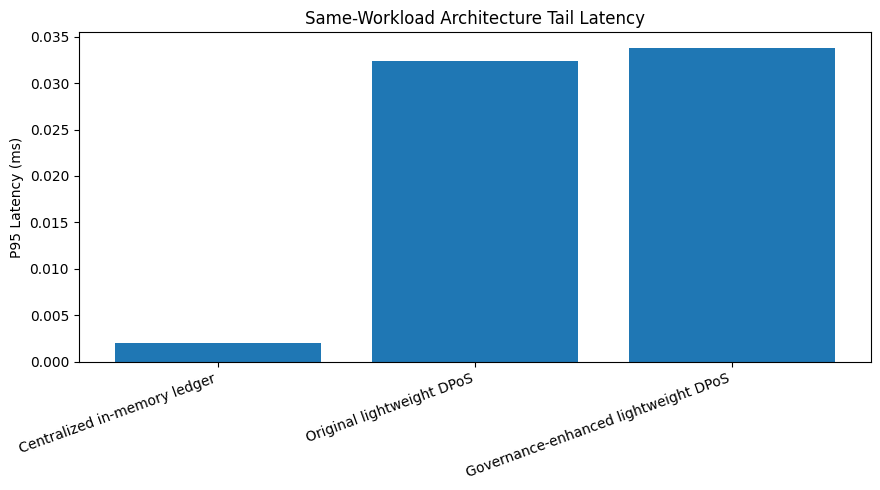

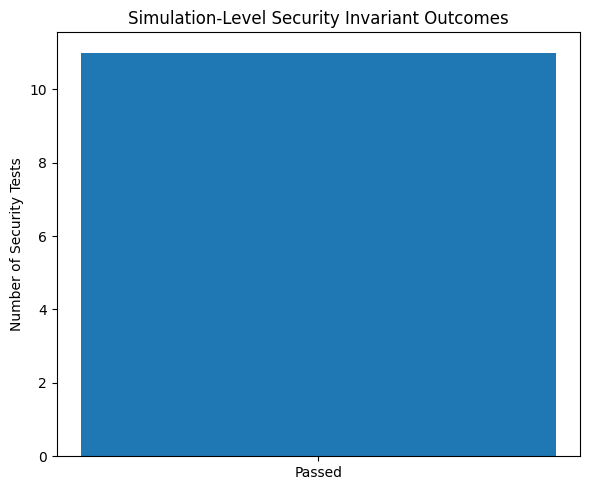

In [43]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 43 — Comparative and Security Visualizations
# ═══════════════════════════════════════════════════════════════
plt.figure(figsize=(9, 5))
plt.bar(
    architecture_performance_table["Architecture"],
    architecture_performance_table["Throughput_TPS"]
)
plt.ylabel("Throughput (Transactions/s)")
plt.title("Same-Workload In-Memory Architecture Benchmark")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(
    os.path.join(
        REVIEW_OUTPUT_DIR,
        "Fig_R15_Architecture_Throughput_Comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


plt.figure(figsize=(9, 5))
plt.bar(
    architecture_performance_table["Architecture"],
    architecture_performance_table["P95_Latency_ms"]
)
plt.ylabel("P95 Latency (ms)")
plt.title("Same-Workload Architecture Tail Latency")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(
    os.path.join(
        REVIEW_OUTPUT_DIR,
        "Fig_R16_Architecture_P95_Latency.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


security_summary = (
    security_invariant_results["Pass"]
    .value_counts()
    .rename_axis("Test_Result")
    .reset_index(name="Count")
)

security_summary["Test_Result"] = security_summary[
    "Test_Result"
].map(
    {
        True: "Passed",
        False: "Failed"
    }
)

plt.figure(figsize=(6, 5))
plt.bar(
    security_summary["Test_Result"],
    security_summary["Count"]
)
plt.ylabel("Number of Security Tests")
plt.title("Simulation-Level Security Invariant Outcomes")
plt.tight_layout()
plt.savefig(
    os.path.join(
        REVIEW_OUTPUT_DIR,
        "Fig_R17_Security_Invariant_Outcomes.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [44]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 44 — Reviewer Question Coverage Table
# ═══════════════════════════════════════════════════════════════
reviewer_question_coverage_table = pd.DataFrame(
    [
        ("Q1", "Real government data", "Signed USAspending reconstruction, data profile, chronological replay, leakage-aware evaluation", "Strong data-driven simulation; not operational deployment"),
        ("Q2", "Multi-agency deployment", "Institutional registry and agency scalability experiment", "Simulated in one runtime; multi-node deployment remains external"),
        ("Q3", "Large-scale concurrency", "1-100 concurrent clients, tail latency, memory, failure rate", "In-memory DPoS load test"),
        ("Q4", "Practical workflow", "Lifecycle state machine and invalid-transition checks", "Simulation; stakeholder study remains external"),
        ("Q5", "Offline tendering", "Tender hashes, commitments, scoring, challenge status", "Hybrid tender simulation"),
        ("Q6", "Construction quality", "Milestone evidence, engineer and auditor dual approval", "Physical verification requires trusted inspectors/oracles"),
        ("Q7", "Identity authenticity", "Institutional credential registry", "Simulated credentials; government PKI required"),
        ("Q8", "Key management", "Issue, rotate, revoke, recovery-oriented events", "HSM and operational key ceremony required"),
        ("Q9", "Collusion", "Multisignature policies and malicious-delegate simulation", "Residual majority-collusion risk remains"),
        ("Q10", "Privacy", "Pseudonymized public view and restricted auditor view", "Privacy impact assessment remains external"),
        ("Q11", "Legal compliance and responsibility", "Compliance matrix and responsibility trace", "No legal certification is claimed"),
        ("Q12", "Smart-contract security analysis", "Executable Python security invariants and attack outcomes", "Actual Solidity audit still required"),
        ("Q13", "Attack modelling", "STRIDE-oriented attack model", "Simulation-level evidence"),
        ("Q14", "Formal verification", "Explicit properties P1-P10 and executable checks", "Solidity formal verification is not established"),
        ("Q15", "Comparative evaluation", "Same-workload baseline and expanded comparison matrix", "In-memory benchmark plus literature table")
    ],
    columns=[
        "Question",
        "Reviewer_Concern",
        "Added_Colab_Evidence",
        "Evidence_Boundary"
    ]
)

display(reviewer_question_coverage_table)

,Question,Reviewer_Concern,Added_Colab_Evidence,Evidence_Boundary
0,Q1,Real government data,"Signed USAspending reconstruction, data profil...",Strong data-driven simulation; not operational...
1,Q2,Multi-agency deployment,Institutional registry and agency scalability ...,Simulated in one runtime; multi-node deploymen...
2,Q3,Large-scale concurrency,"1-100 concurrent clients, tail latency, memory...",In-memory DPoS load test
3,Q4,Practical workflow,Lifecycle state machine and invalid-transition...,Simulation; stakeholder study remains external
4,Q5,Offline tendering,"Tender hashes, commitments, scoring, challenge...",Hybrid tender simulation
5,Q6,Construction quality,"Milestone evidence, engineer and auditor dual ...",Physical verification requires trusted inspect...
6,Q7,Identity authenticity,Institutional credential registry,Simulated credentials; government PKI required
7,Q8,Key management,"Issue, rotate, revoke, recovery-oriented events",HSM and operational key ceremony required
8,Q9,Collusion,Multisignature policies and malicious-delegate...,Residual majority-collusion risk remains
9,Q10,Privacy,Pseudonymized public view and restricted audit...,Privacy impact assessment remains external


In [45]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 45 — Save Reviewer Tables, Figures, and Consolidated ZIP
# ═══════════════════════════════════════════════════════════════
reviewer_tables = {
    "R01_Dataset_Profile.csv": dataset_profile_table,
    "R02_Mapped_Field_Missingness.csv": missingness_table,
    "R03_Agency_Transaction_Summary.csv": agency_summary_table,
    "R04_Annual_Transaction_Summary.csv": annual_transaction_table,
    "R05_Proxy_Risk_Distribution.csv": risk_distribution_table,
    "R06_Signed_Transaction_Replay_Log.csv": review_transaction_log,
    "R07_Project_Replay_Summary.csv": project_replay_summary,
    "R08_Replay_Status_Summary.csv": replay_status_table,
    "R09_Leakage_Aware_ML_Results.csv": leakage_aware_ml_results,
    "R10_ML_Robustness_Comparison.csv": ml_robustness_comparison,
    "R11_Multi_Agency_Identity_Registry.csv": multi_agency_registry_table,
    "R12_Key_Management_Events.csv": key_management_event_table,
    "R13_Role_Permission_Matrix.csv": role_permission_matrix_table,
    "R14_Tender_Audit_Records.csv": tender_audit_table,
    "R15_Quality_Verification_Records.csv": quality_verification_table,
    "R16_Project_Workflow_Summary.csv": project_workflow_summary,
    "R17_Workflow_Validation_Tests.csv": workflow_validation_table,
    "R18_Responsibility_Trace.csv": responsibility_trace_table,
    "R19_Public_Privacy_Portal.csv": public_privacy_portal_table,
    "R20_Restricted_Auditor_View.csv": restricted_auditor_table,
    "R21_Privacy_Field_Classification.csv": privacy_field_classification_table,
    "R22_Security_Invariant_Results.csv": security_invariant_results,
    "R23_Attack_Model.csv": attack_model_table,
    "R24_Formal_Property_Table.csv": formal_property_table,
    "R24B_Solidity_Audit_Plan.csv": solidity_audit_plan_table,
    "R25_Concurrency_Results.csv": concurrency_results,
    "R26_Multi_Agency_Scalability.csv": agency_scalability_results,
    "R27_Collusion_Results.csv": collusion_results,
    "R28_Compliance_Matrix.csv": compliance_matrix_table,
    "R29_Responsibility_Trace_Schema.csv": responsibility_trace_schema_table,
    "R29B_Stakeholder_Validation_Protocol.csv": stakeholder_validation_protocol_table,
    "R30_Architecture_Performance.csv": architecture_performance_table,
    "R31_Architecture_Feature_Comparison.csv": architecture_feature_comparison,
    "R32_Existing_System_Comparison.csv": existing_system_comparison_table,
    "R33_Reviewer_Question_Coverage.csv": reviewer_question_coverage_table
}

for filename, table in reviewer_tables.items():
    table.to_csv(
        os.path.join(REVIEW_OUTPUT_DIR, filename),
        index=False
    )

# Copy original outputs into the reviewer package when they exist.
for original_file in original_result_files:
    if os.path.exists(original_file):
        shutil.copy2(
            original_file,
            os.path.join(
                REVIEW_OUTPUT_DIR,
                original_file
            )
        )

review_notes = """
Reviewer-strengthening evidence package

Important interpretation boundaries:
1. USAspending records are official open data, but the experiments are not an operational government deployment.
2. Concurrency, DPoS, multi-agency, identity, tender, quality, privacy, and governance results are Python simulations.
3. The proxy-risk label represents statistical irregularity, not confirmed fraud.
4. Solidity static analysis, fuzzing, symbolic execution, audit, and formal verification must be performed on the actual contracts.
5. Legal compliance, identity authenticity, HSM key custody, construction quality, and practical workflow fit require external authorities and stakeholders.
""".strip()

with open(
    os.path.join(REVIEW_OUTPUT_DIR, "README_INTERPRETATION.txt"),
    "w",
    encoding="utf-8"
) as note_file:
    note_file.write(review_notes)

zip_base_name = "Reviewer_Strengthened_USAspending_DPoS_Results"
zip_path = shutil.make_archive(
    zip_base_name,
    "zip",
    REVIEW_OUTPUT_DIR
)

print("Reviewer tables saved:", len(reviewer_tables))
print("Reviewer package:", zip_path)
print("\nFiles in package:")
for filename in sorted(os.listdir(REVIEW_OUTPUT_DIR)):
    print(" -", filename)

Reviewer tables saved: 35
Reviewer package: /content/Reviewer_Strengthened_USAspending_DPoS_Results.zip

Files in package:
 - Extended_DPoS_Delegate_Results.csv
 - Fig_R10_Privacy_Data_Classification.png
 - Fig_R11_Concurrency_Throughput.png
 - Fig_R12_Concurrency_Tail_Latency.png
 - Fig_R13_Multi_Agency_Scalability.png
 - Fig_R14_DPoS_Collusion_Risk.png
 - Fig_R15_Architecture_Throughput_Comparison.png
 - Fig_R16_Architecture_P95_Latency.png
 - Fig_R17_Security_Invariant_Outcomes.png
 - Fig_R1_Annual_USAspending_Transaction_Replay.png
 - Fig_R2_Top_Agencies_by_Transaction_Amount.png
 - Fig_R3_Proxy_Risk_Distribution.png
 - Fig_R4_Chronological_Replay_Project_Status.png
 - Fig_R5_Original_vs_Leakage_Aware_ML.png
 - Fig_R6_Proxy_Risk_ROC_Comparison.png
 - Fig_R7_Leakage_Aware_Confusion_Matrix.png
 - Fig_R8_Governed_Workflow_Outcomes.png
 - Fig_R9_Milestone_Quality_Approval_Rates.png
 - Lightweight_DPoS_Blockchain_Metrics.csv
 - ML_Results_GAN_USAspending_NoCV.csv
 - Processed_USAspendin

In [46]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 46 — Download Consolidated Reviewer Package
# ═══════════════════════════════════════════════════════════════
from google.colab import files

DOWNLOAD_REVIEW_PACKAGE = True

if DOWNLOAD_REVIEW_PACKAGE:
    files.download(
        "Reviewer_Strengthened_USAspending_DPoS_Results.zip"
    )
else:
    print(
        "Set DOWNLOAD_REVIEW_PACKAGE = True "
        "to download the ZIP file."
    )

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>